In [50]:
%load_ext autoreload
%autoreload 2


In [51]:
import pandas as pd
import numpy as np
import vectorbt as vbt

In [4]:
# 准备数据
market = pd.read_parquet("../data_ohlcv.parquet")
f_mev = pd.read_parquet("../factors_mev_new.parquet")
f_ohlcv = pd.read_parquet("../factors_ohlcv.parquet")
f_ohlcv = f_ohlcv.fillna(0)
factors = pd.concat([f_mev, f_ohlcv], axis=1, join='outer')
# 清洗数据
factors = factors.replace([np.inf, -np.inf], np.nan)
factors = factors.fillna(0)
target_returns = market['close'].pct_change().shift(-1) 
rolling_ic = factors.apply(lambda col: col.rolling(window=144).corr(target_returns))

In [5]:
factors.describe()

,f_sandwich_intensity_z,f_mev_vol_share_z,f_attack_eff_z,roc_6,roc_12,roc_48,madev_6,madev_12,madev_48,cci_6,...,pvcorr_48,rank_6,rank_12,rank_48,corr_6,corr_12,corr_48,delta_6,delta_12,delta_48
count,745326.000000,745326.000000,745326.000000,745326.000000,745326.000000,745326.000000,745326.000000,745326.000000,745326.000000,745326.000000,...,745326.000000,745326.000000,745326.000000,745326.000000,745326.000000,745326.000000,745326.000000,7.453260e+05,7.453260e+05,7.453260e+05
mean,0.745775,0.313522,0.532729,0.000036,0.000072,0.000284,0.000011,0.000025,0.000110,0.639124,...,-0.014759,0.565437,0.523900,0.498055,-0.011683,-0.013609,-0.018255,5.584903e+01,1.605260e+02,5.264332e+02
std,0.910481,0.830309,0.932493,0.004855,0.006754,0.013176,0.002471,0.003680,0.007527,74.074091,...,0.309686,0.294818,0.300035,0.302713,0.541185,0.457806,0.363831,9.926560e+06,1.076819e+07,1.210134e+07
min,0.000000,0.000000,0.000000,-0.202199,-0.223795,-0.340147,-0.112584,-0.166149,-0.219526,-136.082764,...,-0.985801,0.000000,0.000000,0.000000,-1.000000,-1.000000,-0.981341,-4.660152e+08,-4.878323e+08,-5.269998e+08
25%,0.000000,0.000000,0.000000,-0.001651,-0.002247,-0.004392,-0.000835,-0.001204,-0.002377,-67.336910,...,-0.235976,0.333333,0.250000,0.229167,-0.477617,-0.388464,-0.302472,-1.599898e+06,-1.712027e+06,-1.981722e+06
50%,0.328988,0.004327,0.025051,0.000026,0.000059,0.000199,0.000012,0.000035,0.000129,1.680301,...,-0.015401,0.500000,0.500000,0.500000,-0.017214,-0.017691,-0.023170,-4.462585e+04,-3.894938e+04,-1.559799e+04
75%,1.279244,0.233182,0.775141,0.001734,0.002423,0.004949,0.000877,0.001295,0.002683,68.259038,...,0.205273,0.833333,0.750000,0.770833,0.452164,0.357917,0.263198,1.365891e+06,1.509606e+06,1.871953e+06
max,8.978534,12.035910,12.107338,0.336439,0.328117,0.318977,0.217432,0.216264,0.160930,142.614944,...,0.993733,1.000000,1.000000,1.000000,1.000000,1.000000,0.991191,5.399915e+08,5.532558e+08,5.420839e+08


In [53]:
rolling_ic.describe()

,f_sandwich_intensity_z,f_mev_vol_share_z,f_attack_eff_z,roc_6,roc_12,roc_48,madev_6,madev_12,madev_48,cci_6,...,pvcorr_48,rank_6,rank_12,rank_48,corr_6,corr_12,corr_48,delta_6,delta_12,delta_48
count,436923.000000,436548.000000,436972.000000,729573.000000,729573.000000,729573.000000,729573.000000,729573.000000,729573.000000,729573.000000,...,729573.000000,729573.000000,729573.000000,729573.000000,729573.000000,729573.000000,729573.000000,729573.000000,729573.000000,729573.000000
mean,0.002210,-0.001120,0.000770,-0.062893,-0.065652,-0.081734,-0.063883,-0.073444,-0.091657,-0.036306,...,-0.047723,0.001375,0.002295,0.002917,-0.022215,-0.029778,-0.045186,0.005199,0.007033,0.004972
std,0.082554,0.076683,0.080840,0.091378,0.083750,0.073413,0.098313,0.093003,0.083573,0.080014,...,0.077397,0.083074,0.083255,0.081982,0.085561,0.085041,0.083648,0.106357,0.103123,0.096340
min,-0.565112,-0.565112,-0.487462,-0.645292,-0.558479,-0.470671,-0.782046,-0.776994,-0.670380,-0.378115,...,-0.515348,-0.362701,-0.323682,-0.394357,-0.394572,-0.365193,-0.432092,-0.726458,-0.812780,-0.790238
25%,-0.051090,-0.049267,-0.051055,-0.123576,-0.122015,-0.130098,-0.128507,-0.135672,-0.147046,-0.089885,...,-0.098937,-0.055559,-0.054756,-0.052771,-0.079609,-0.088393,-0.100469,-0.065147,-0.061401,-0.057042
50%,0.002505,-0.001055,0.000304,-0.067007,-0.068132,-0.081521,-0.066841,-0.076543,-0.093060,-0.035995,...,-0.049522,0.001524,0.003218,0.002838,-0.021873,-0.031113,-0.048095,0.003286,0.007427,0.004490
75%,0.055435,0.047163,0.052761,-0.005221,-0.012210,-0.034895,-0.002354,-0.015079,-0.037408,0.018947,...,0.001396,0.058921,0.059887,0.058915,0.035661,0.025792,0.007605,0.074745,0.074287,0.066795
max,0.565644,0.513812,0.623852,0.652151,0.678466,0.631698,0.744212,0.709437,0.709274,0.302564,...,0.528135,0.341462,0.327778,0.342018,0.357115,0.447944,0.448072,0.645646,0.680206,0.701475


# 1. 关于连续有效天数

In [54]:
from test_tools import effective_days
persistence = effective_days(factors, target_returns)
persistence.describe()

,f_sandwich_intensity_z,f_mev_vol_share_z,f_attack_eff_z,roc_6,roc_12,roc_48,madev_6,madev_12,madev_48,cci_6,...,pvcorr_48,rank_6,rank_12,rank_48,corr_6,corr_12,corr_48,delta_6,delta_12,delta_48
count,745326.000000,745326.000000,745326.000000,745326.000000,745326.000000,745326.000000,745326.000000,745326.000000,745326.000000,745326.000000,...,745326.000000,745326.000000,745326.000000,745326.000000,745326.000000,745326.000000,745326.000000,745326.000000,745326.000000,745326.000000
mean,10.045085,7.661112,9.110557,43.379945,37.777166,38.884986,50.933587,56.329911,59.790096,22.693446,...,20.737598,16.327737,15.822011,14.797140,20.863108,22.039796,23.397355,31.047579,28.140386,22.679468
std,33.732514,29.230080,32.293371,81.376041,71.099651,71.586312,93.552857,99.049531,101.115586,57.527232,...,49.178664,42.135102,40.278432,38.190212,51.243030,50.463362,50.623517,58.528633,54.699861,50.208328
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,57.000000,46.000000,49.000000,69.000000,84.000000,90.000000,1.000000,...,5.000000,0.000000,0.000000,0.000000,1.000000,6.000000,11.000000,32.000000,23.000000,10.000000
max,327.000000,307.000000,385.000000,646.000000,514.000000,534.000000,764.000000,694.000000,897.000000,466.000000,...,422.000000,380.000000,379.000000,355.000000,390.000000,350.000000,367.000000,409.000000,305.000000,382.000000


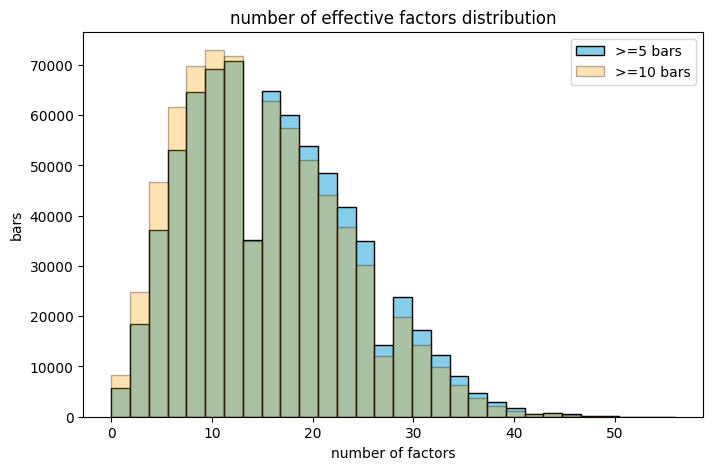

In [55]:
import matplotlib.pyplot as plt

days_5 = pd.DataFrame(index=persistence.index)
days_10 = pd.DataFrame(index=persistence.index)
for col in persistence.columns:
    days_5[col] =  (persistence[col] >= 5)
    days_10[col] = (persistence[col] >= 10)
days_5["all"] = days_5.sum(axis=1)
days_10["all"] = days_10.sum(axis=1)

data_5 = days_5["all"].values  # 这里使用 "all" 列的数据进行绘图
data_10 = days_10["all"].values  # 这里使用 "all" 列的数据进行绘图


plt.figure(figsize=(8, 5))
# bins指定柱子的数量
plt.hist(data_5, bins=30, color='skyblue', edgecolor='black', alpha=1, label='>=5 bars') # type: ignore
plt.hist(data_10, bins=30, color='orange', edgecolor='black', alpha=0.3, label='>=10 bars') # type: ignore


plt.title("number of effective factors distribution")
plt.xlabel("number of factors")
plt.ylabel("bars")
plt.legend()
plt.show()

# 2. 根据连续有效天数做相似度和谱聚类

In [56]:
# Jaccard 相似度
from test_tools import get_jaccard_similarity
persistence = effective_days(factors, target_returns)
similarity_matrix = get_jaccard_similarity(persistence)

print(similarity_matrix)

                        f_sandwich_intensity_z  f_mev_vol_share_z  \
f_sandwich_intensity_z                1.000000           0.120902   
f_mev_vol_share_z                     0.120902           1.000000   
f_attack_eff_z                        0.118552           0.117151   
roc_6                                 0.103938           0.087057   
roc_12                                0.098721           0.085326   
roc_48                                0.102943           0.082262   
madev_6                               0.096601           0.082037   
madev_12                              0.098462           0.085162   
madev_48                              0.100324           0.086185   
cci_6                                 0.090019           0.077359   
cci_12                                0.090171           0.077759   
cci_48                                0.096857           0.082952   
dist_h_6                              0.093385           0.082442   
dist_h_12                         

In [57]:
similarity_matrix.to_csv("similarity_matrix.csv")

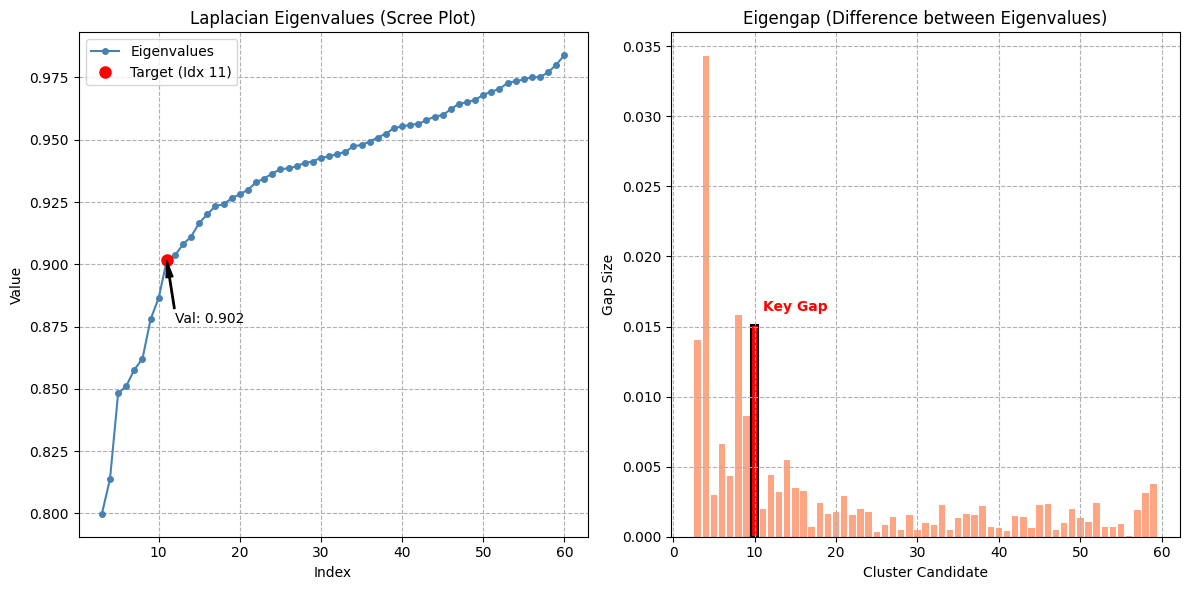

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def analyze_factor_eigengap(sim_matrix_df):
    """
    计算并可视化拉普拉斯特征值
    输入: sim_matrix_df (60x60 的相似度矩阵)
    """
    # 1. 提取矩阵数值
    W = sim_matrix_df.values
    
    # 2. 计算度矩阵 D (每个因子与其他所有因子的相似度之和)
    d = np.sum(W, axis=1)
    
    # 检查是否有全零行（从未有效的因子），防止除以 0
    d[d == 0] = 1e-10 
    
    # 3. 计算归一化拉普拉斯矩阵 L_sym
    # L_sym = I - D^(-1/2) * W * D^(-1/2)
    d_inv_sqrt = np.power(d, -0.5)
    D_inv_sqrt = np.diag(d_inv_sqrt)
    
    # 矩阵运算实现归一化
    L_sym = np.eye(len(W)) - D_inv_sqrt @ W @ D_inv_sqrt
    
    # 4. 计算特征值 (eigvalsh 保证返回从小到大排序的实数特征值)
    eigvals = np.linalg.eigvalsh(L_sym)

    ## 5. 可视化
    plt.figure(figsize=(12, 6))
    
    target_idx = 9  # 你想要标记的数组索引
    
    # --- 左图：碎石图 ---
    plt.subplot(1, 2, 1)
    x_vals = np.arange(1, len(eigvals) + 1)
    plt.plot(x_vals[2:], eigvals[2:], 'o-', markersize=4, label='Eigenvalues', color='steelblue')
    
    plt.plot(target_idx + 2, eigvals[target_idx+1], 'ro', markersize=8, label=f'Target (Idx {target_idx+2})')
    plt.annotate(f'Val: {eigvals[target_idx+1]:.3f}', 
                 xy=(target_idx + 2, eigvals[target_idx+1]), 
                 xytext=(target_idx + 3, eigvals[target_idx] - 0.01),
                 arrowprops=dict(facecolor='black', shrink=0.01, width=1, headwidth=5))
    
    plt.title('Laplacian Eigenvalues (Scree Plot)')
    plt.xlabel('Index')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True, ls='--')
    
    # --- 右图：特征间隙 (Eigengap) ---
    eigengap = np.diff(eigvals)
    plt.subplot(1, 2, 2)
    # x轴对应的是间隙，比如第11个间隙是 eigvals[11] - eigvals[10]
    gap_x = np.arange(2, len(eigengap) + 1)
    bars = plt.bar(gap_x[1:], eigengap[2:], color='coral', alpha=0.7)
    
    # 重点标记 index=11 的柱子
    # 注意：在 bar 图中，第11个 gap 的 x 坐标通常对应 target_idx + 1
    plt.bar(target_idx + 1, eigengap[target_idx], color='red', edgecolor='black', linewidth=1.5)
    plt.annotate('Key Gap', 
                 xy=(target_idx + 1, eigengap[target_idx]), 
                 xytext=(target_idx + 2, eigengap[target_idx] + 0.001),
                 weight='bold', color='red')

    plt.title('Eigengap (Difference between Eigenvalues)')
    plt.xlabel('Cluster Candidate')
    plt.ylabel('Gap Size')
    plt.grid(True, ls='--')
    
    plt.tight_layout()
    plt.show()
    
    return eigvals

# 使用方法：
eigvals = analyze_factor_eigengap(similarity_matrix)

In [159]:
# 聚类
from test_tools import spectral_clustering
n_clusters = 12  # 你可以根据需要调整聚类数量
labels = spectral_clustering(similarity_matrix, n_clusters)
labels=labels.to_frame()
labels.columns = ["group"]

# 得到 {'group1': ['index1', 'index2'], ...}
result_dict = labels.groupby('group').apply(lambda x: x.index.tolist()).to_dict()

# 修改一下
dex_factors = result_dict[4].copy()
result_dict[4] = result_dict[0]
del result_dict[0]
for i in range(len(dex_factors)):
    result_dict[i+12] = [dex_factors[i]]

# 2. 打印输出
#for group, factor_names in result_dict.items():
   # print(f"{group}: {factor_names}")

result_list = list(result_dict.items())
print(result_list)

[(1, ['roc_48', 'mfi_48', 'avr_48', 'pvcorr_48', 'corr_48']), (2, ['rank_6', 'rank_12', 'rank_48']), (3, ['cmf_6', 'cmf_12', 'cmf_48', 'mfi_12', 'avr_6', 'avr_12']), (4, ['dist_l_6', 'dist_l_12']), (5, ['atr_6', 'atr_12', 'gkvol_6', 'gkvol_12', 'rvol_6', 'rvol_12']), (6, ['volsu_6', 'volsu_12', 'volsu_48', 'delta_6', 'delta_12', 'delta_48']), (7, ['roc_12', 'madev_48', 'cci_48', 'dist_h_48', 'dist_l_48', 'drp_48']), (8, ['atr_48', 'gkvol_48', 'rvol_48']), (9, ['skew_6', 'skew_12', 'skew_48', 'kurt_6', 'kurt_12', 'kurt_48']), (10, ['roc_6', 'madev_6', 'madev_12', 'cci_6', 'cci_12', 'dist_h_6', 'dist_h_12', 'mfi_6', 'drp_6', 'drp_12']), (11, ['pvcorr_6', 'pvcorr_12', 'corr_6', 'corr_12']), (12, ['f_sandwich_intensity_z']), (13, ['f_mev_vol_share_z']), (14, ['f_attack_eff_z'])]


/var/folders/mk/x22k3b7d3w94jh72mxd1_tzr0000gn/T/ipykernel_92897/1564767967.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result_dict = labels.groupby('group').apply(lambda x: x.index.tolist()).to_dict()


In [60]:
factors_cleaned = factors.replace([np.inf, -np.inf], np.nan).fillna(0) 


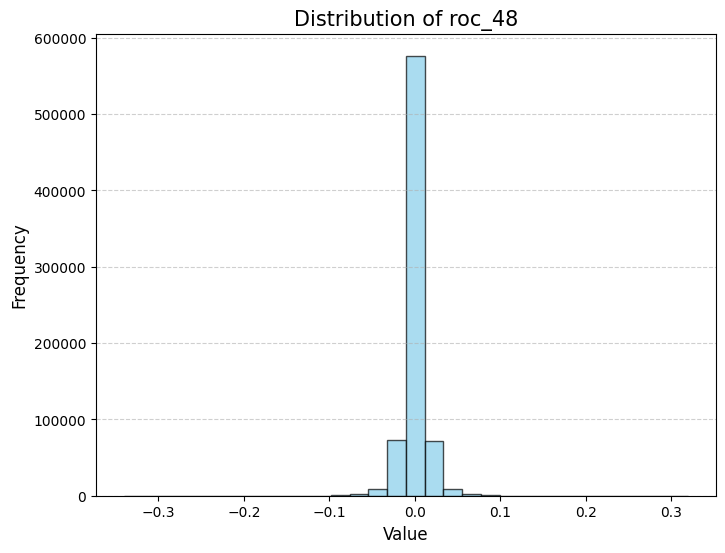

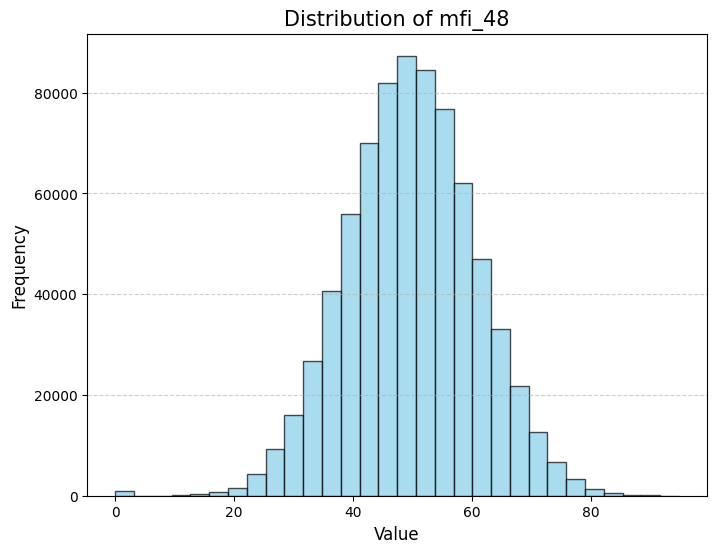

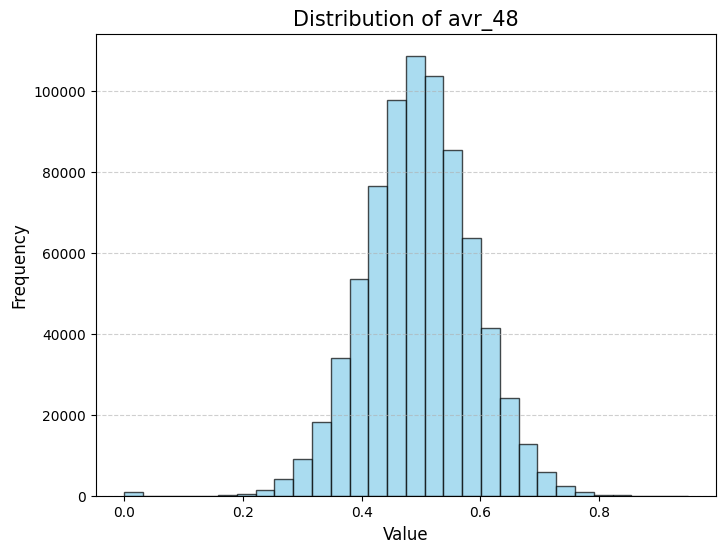

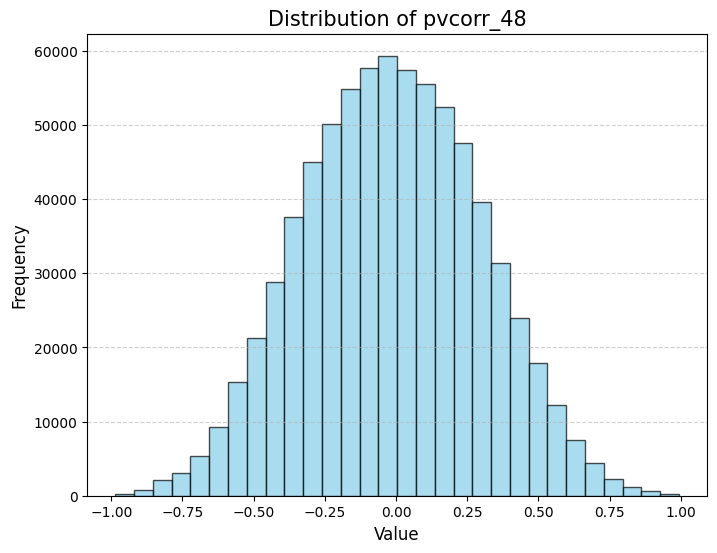

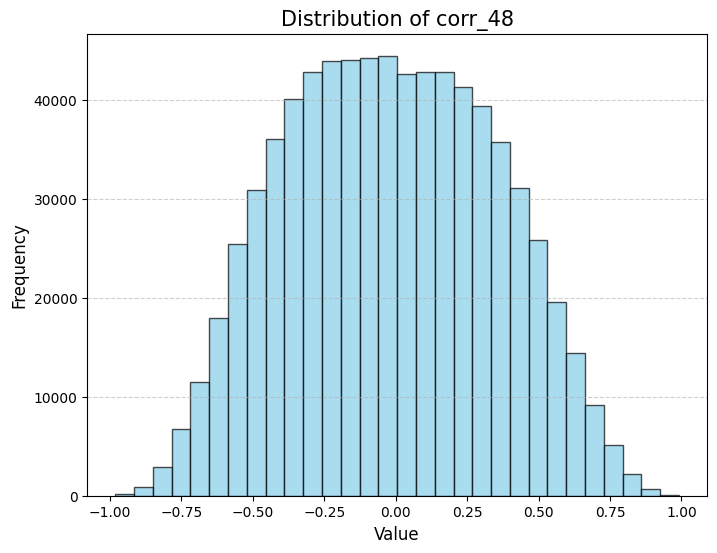

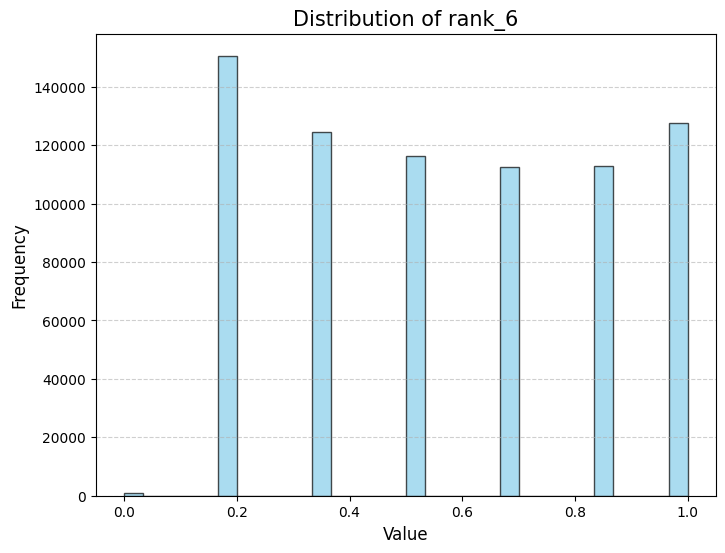

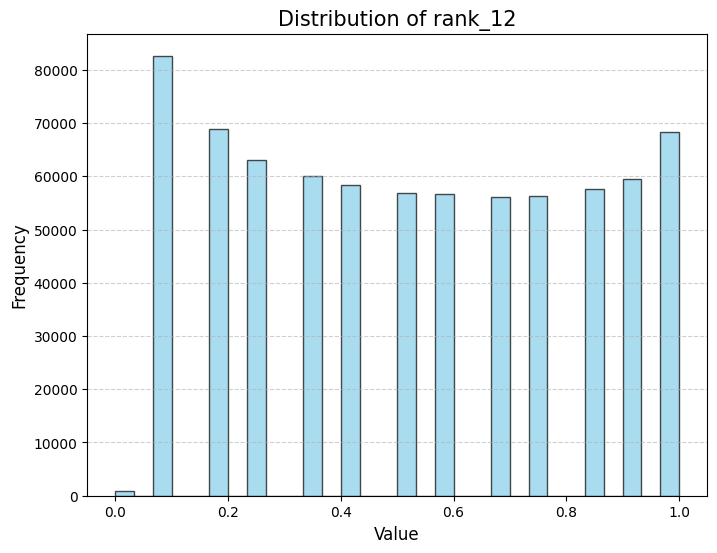

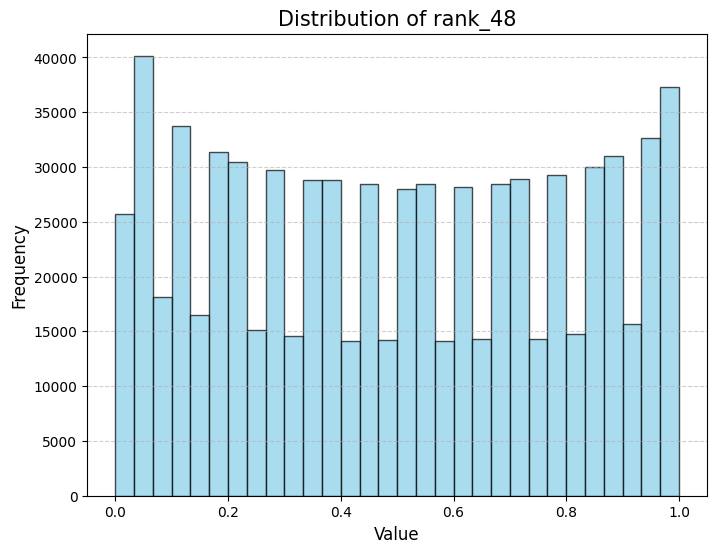

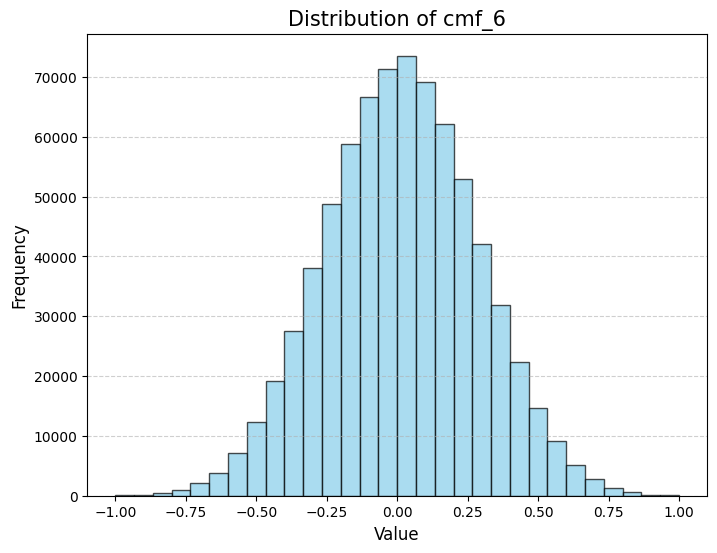

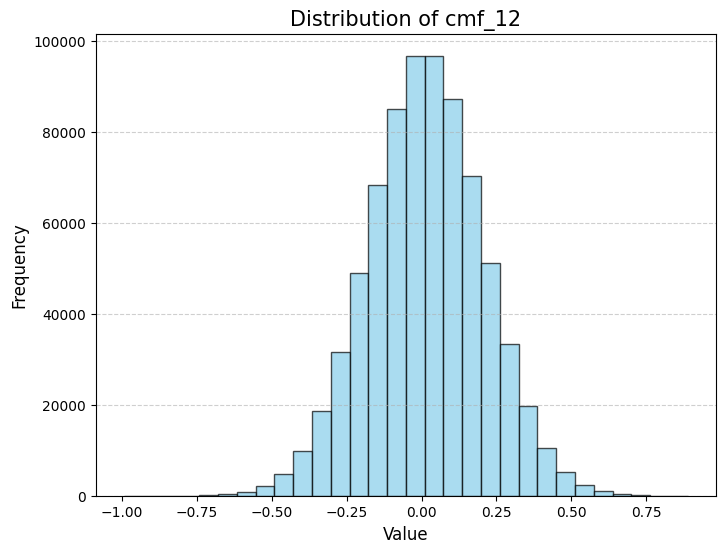

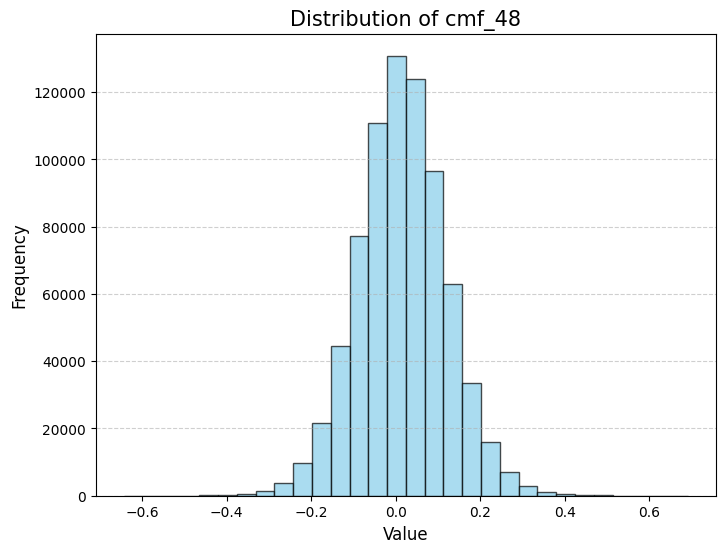

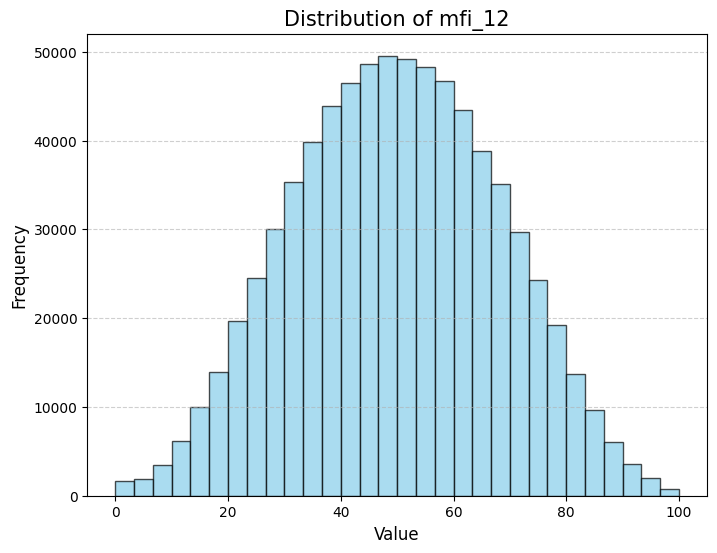

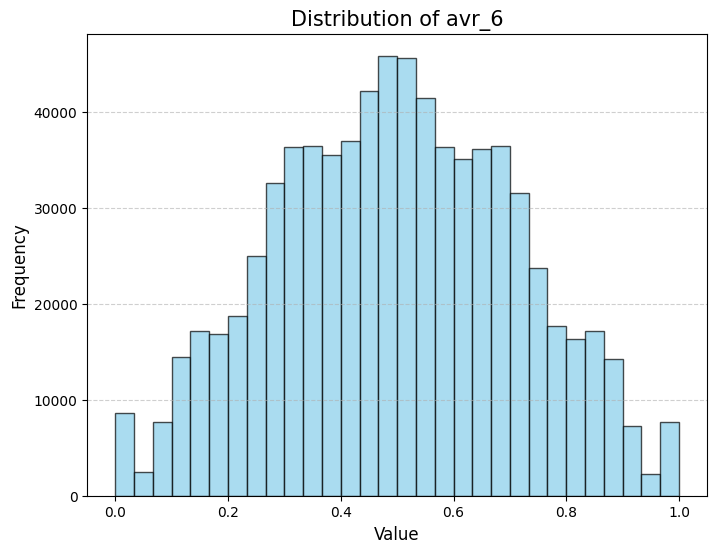

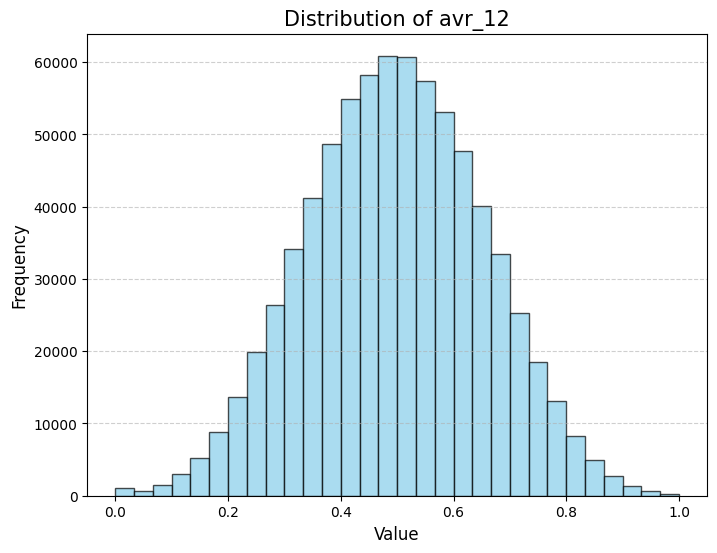

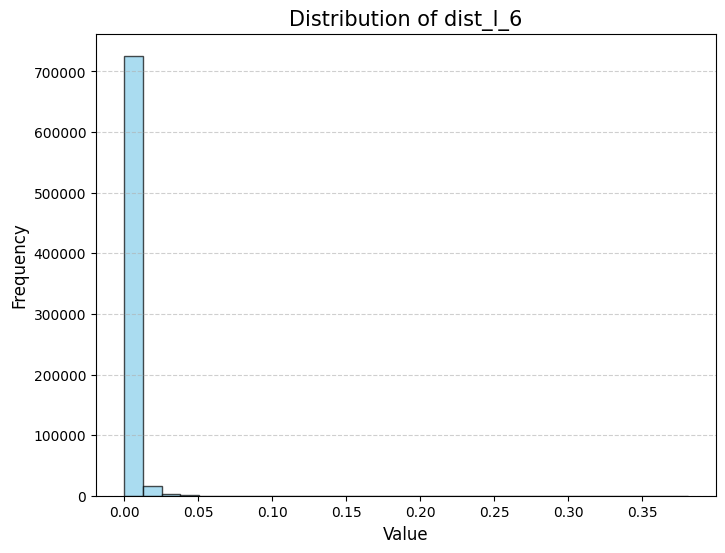

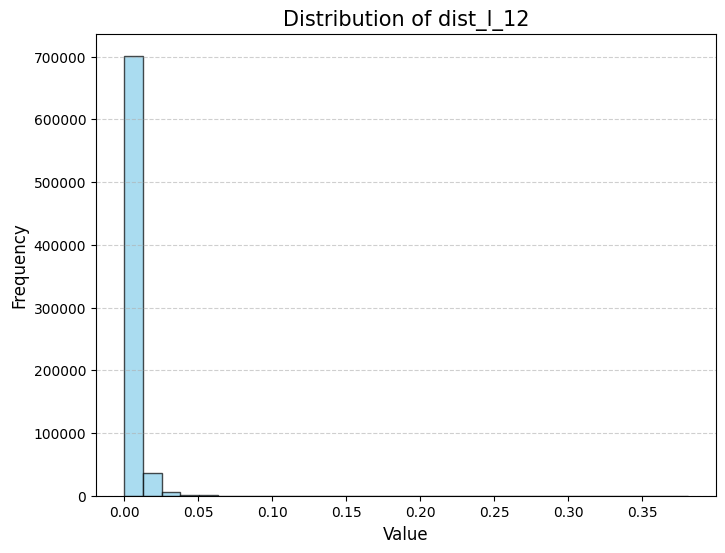

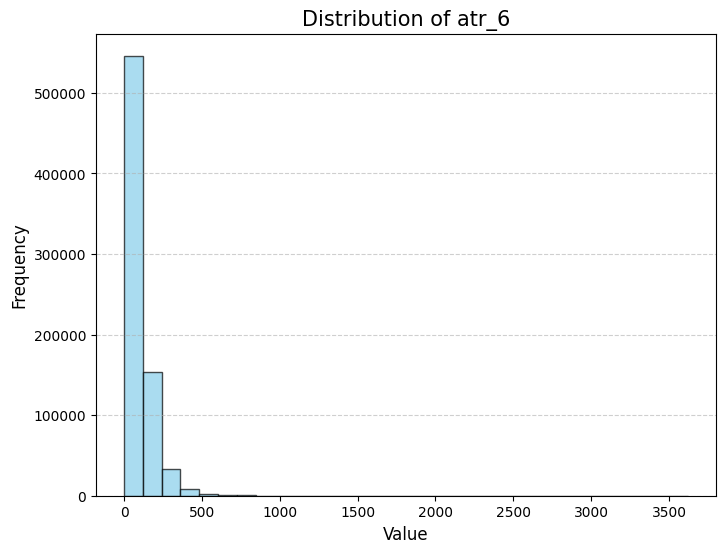

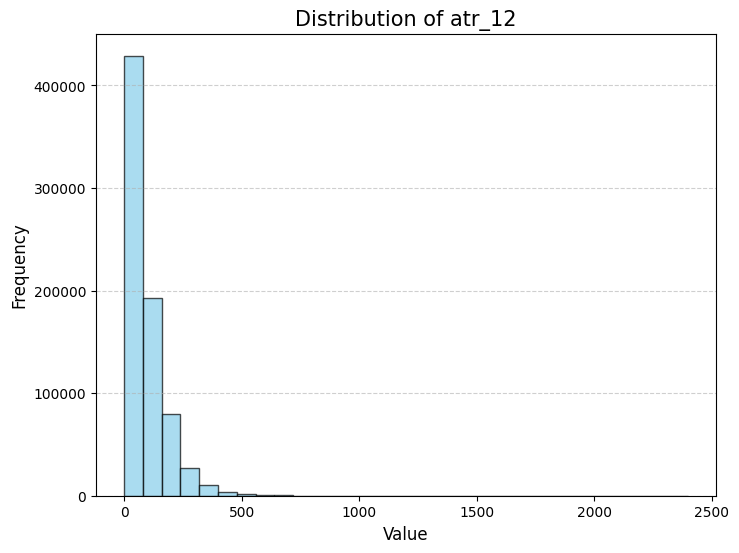

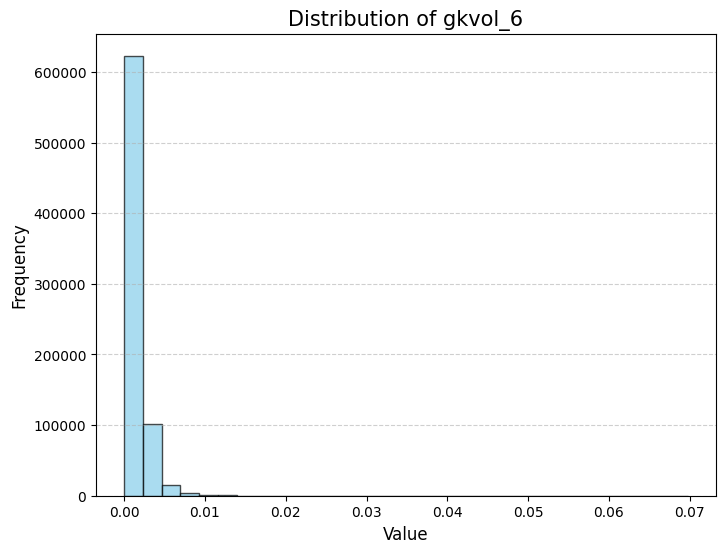

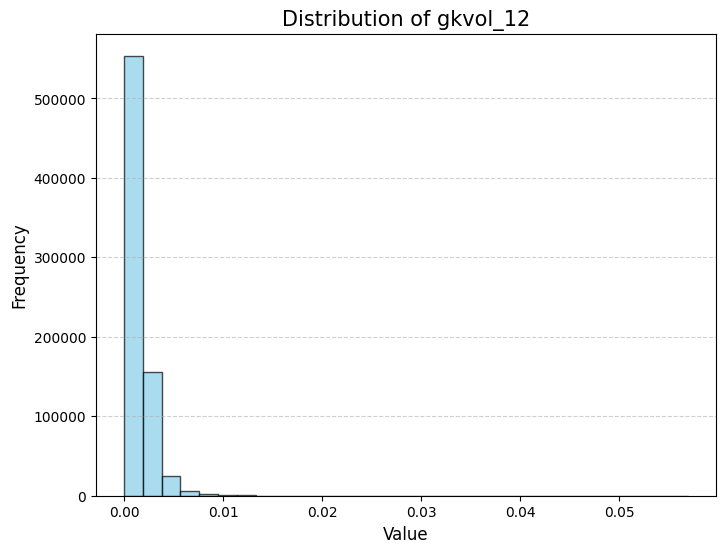

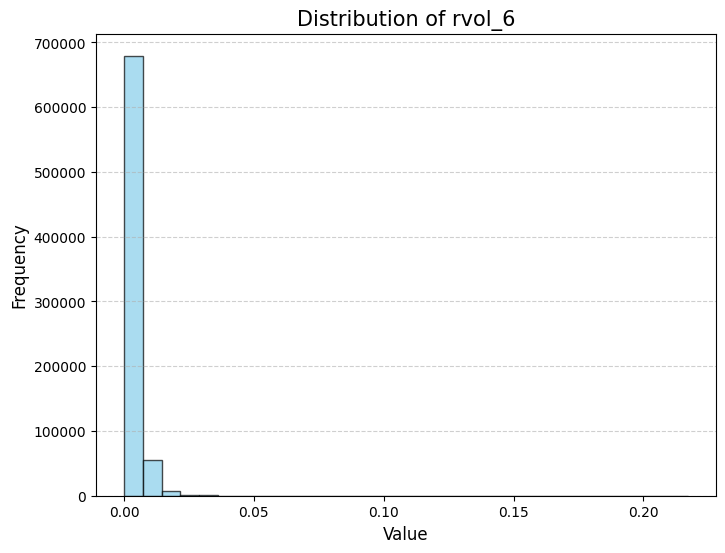

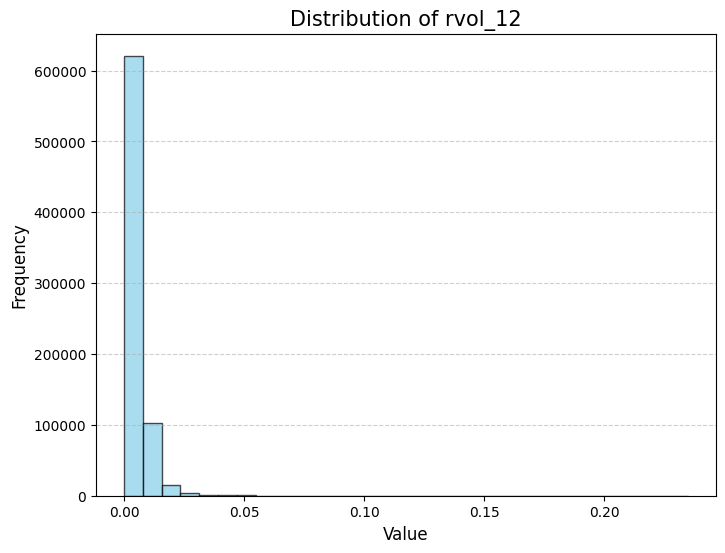

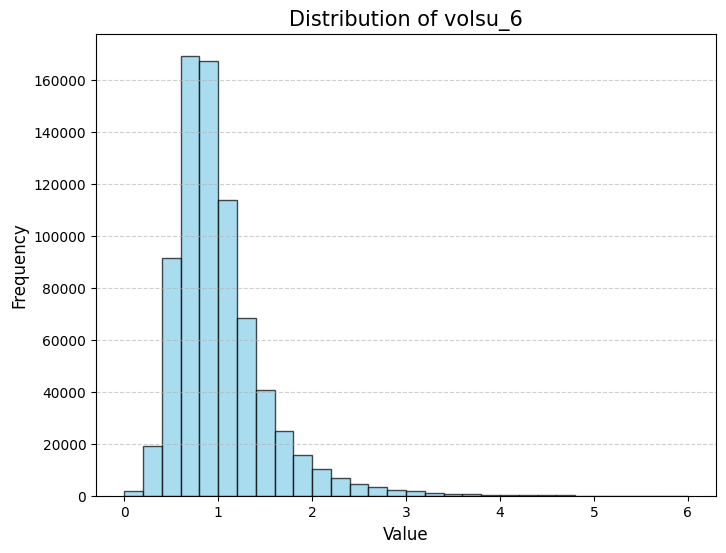

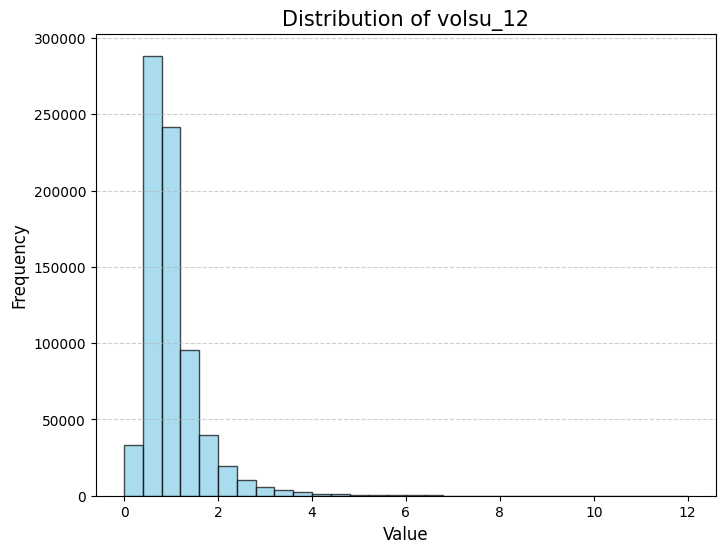

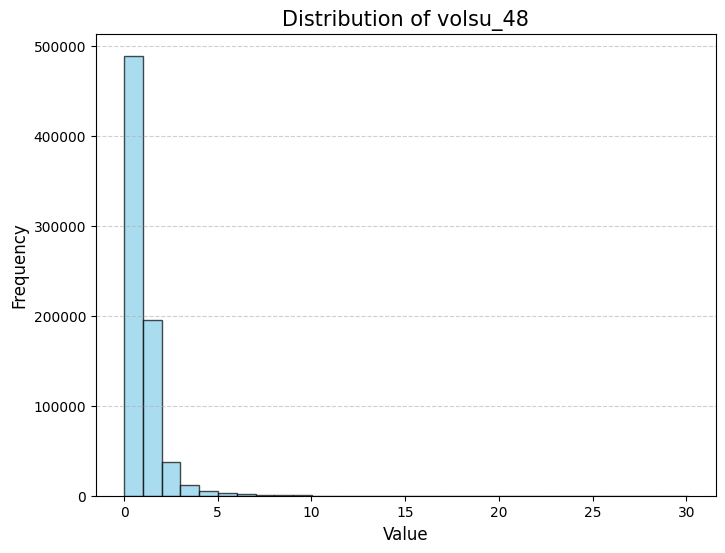

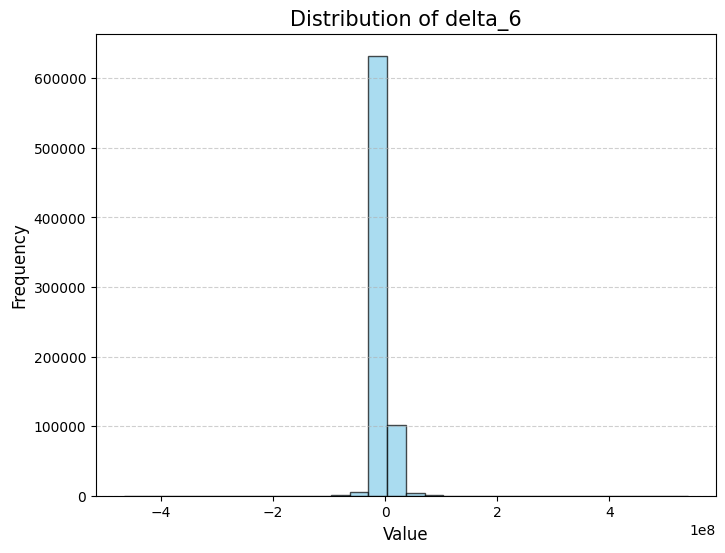

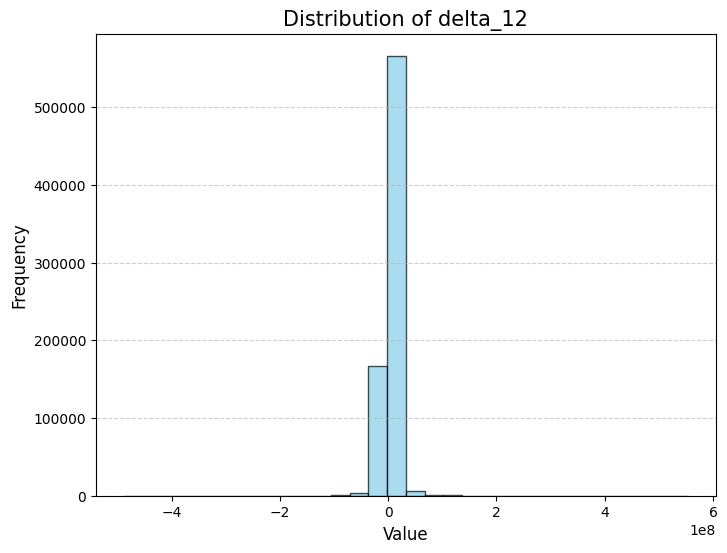

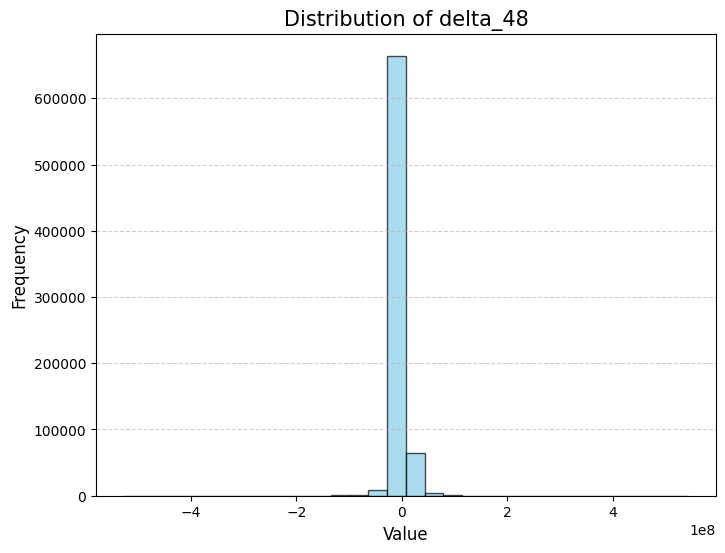

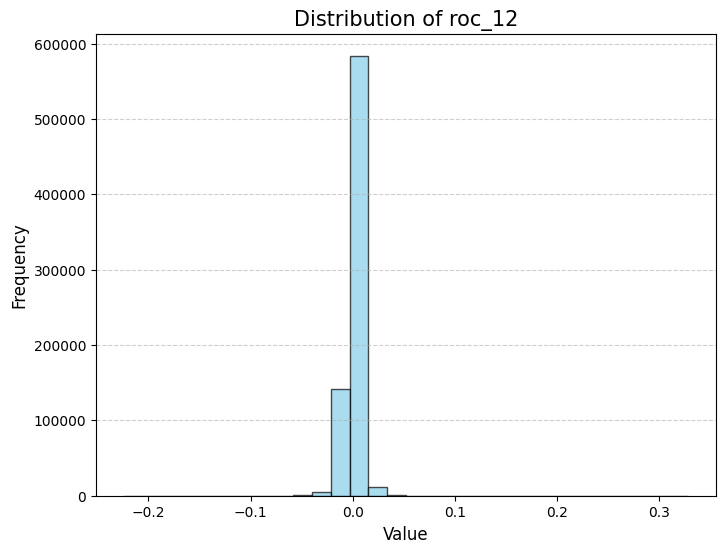

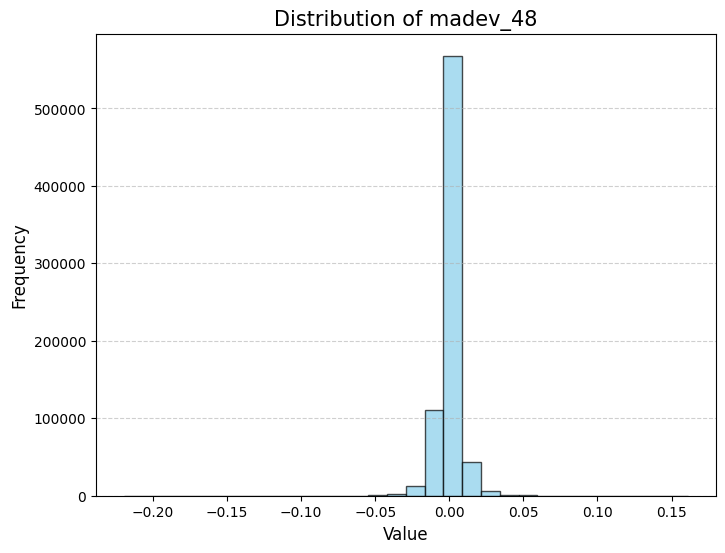

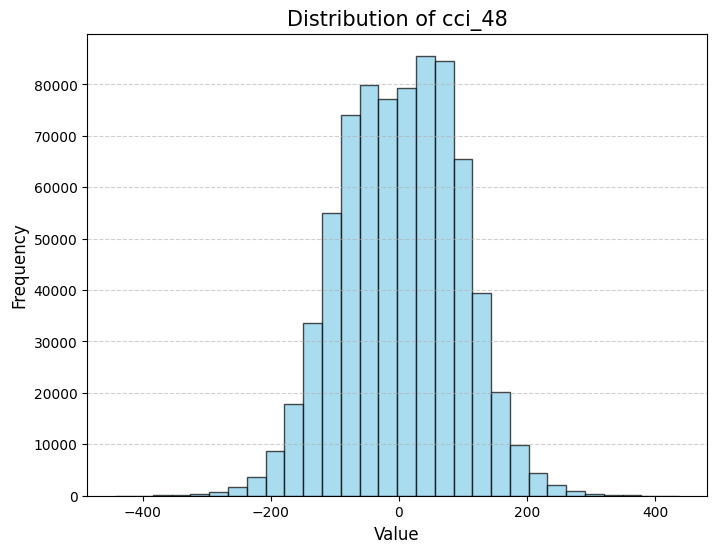

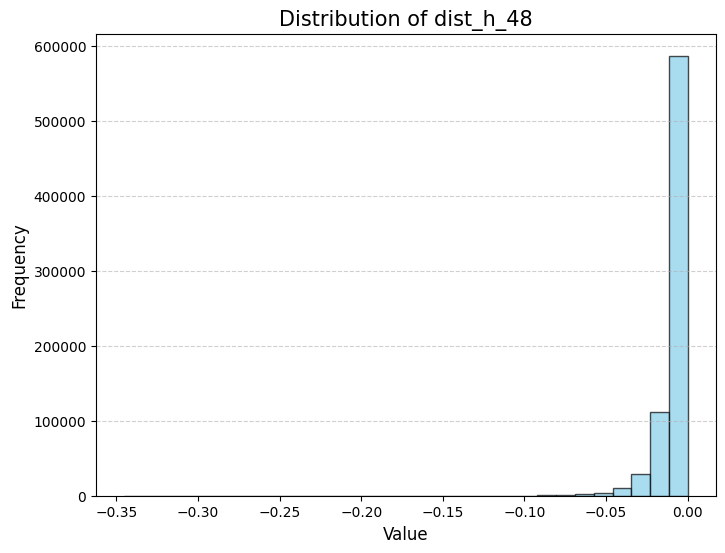

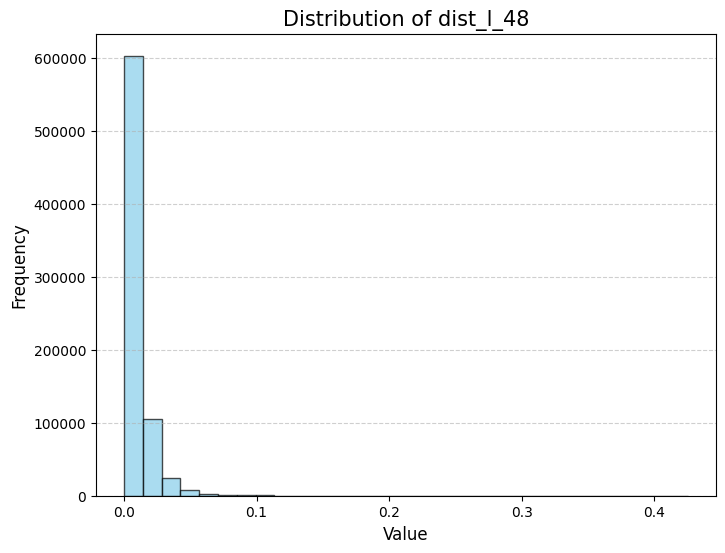

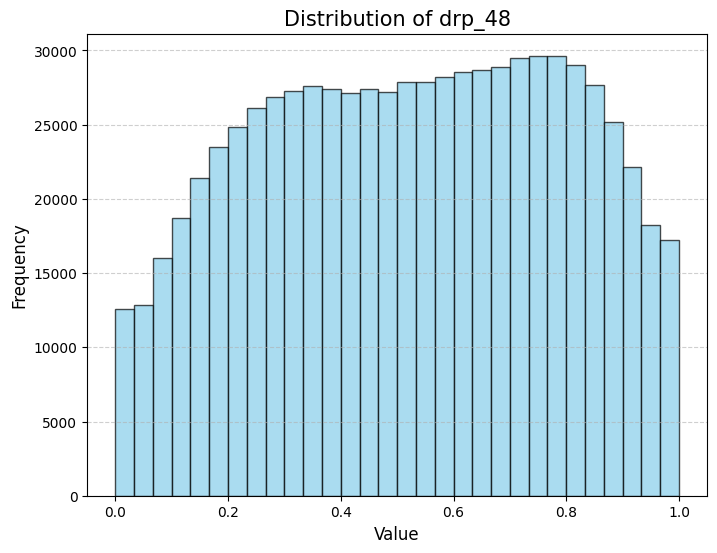

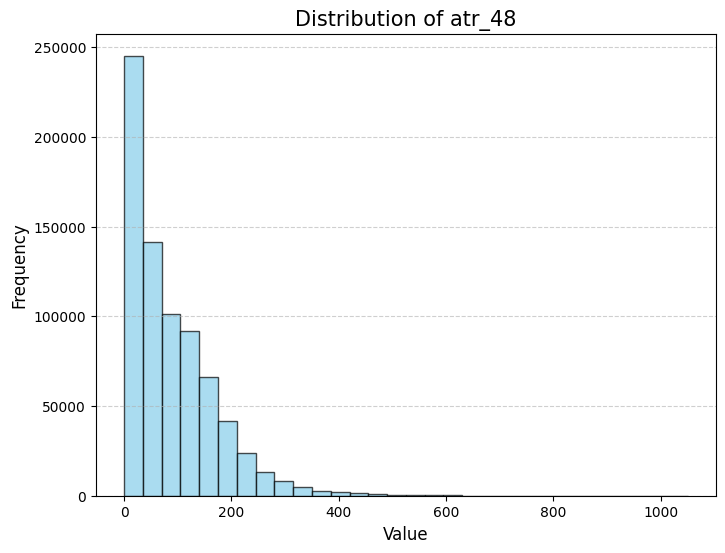

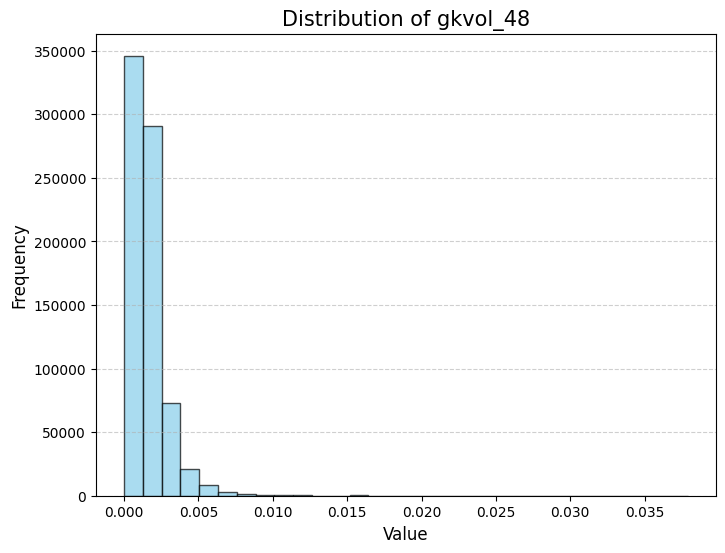

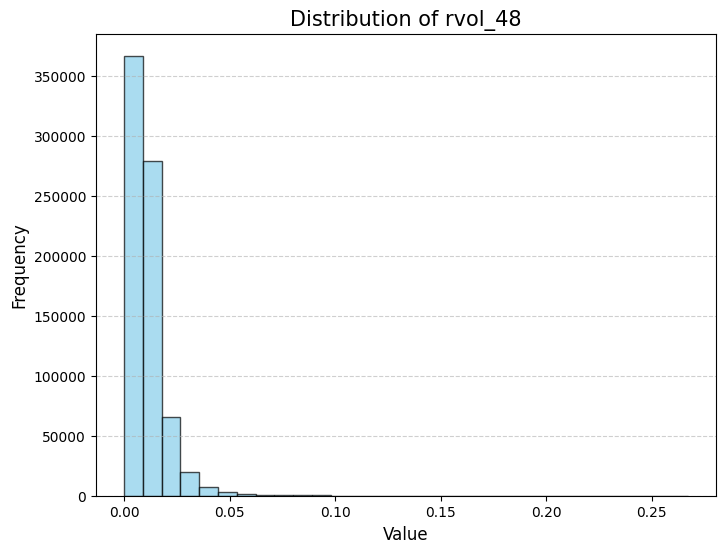

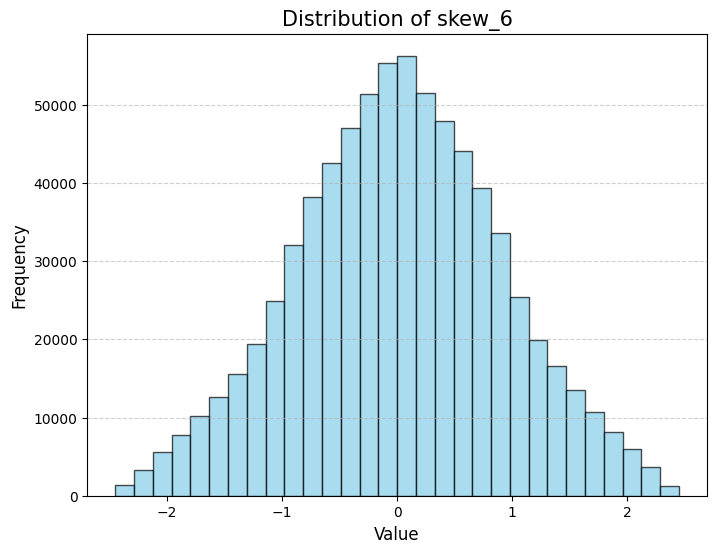

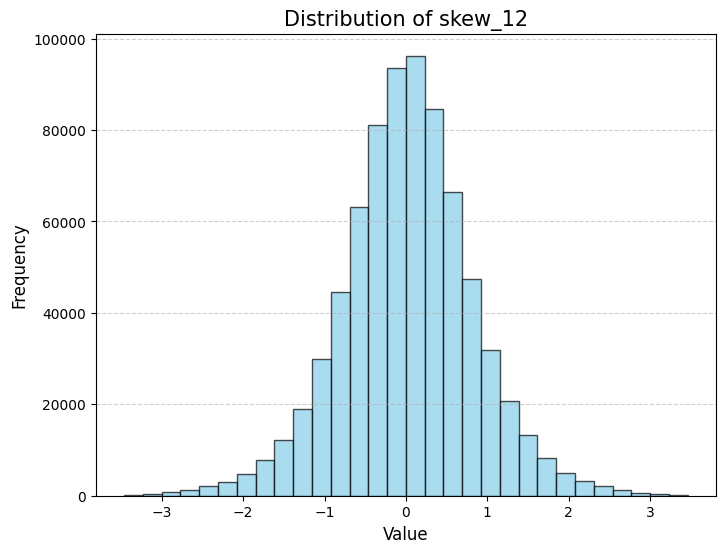

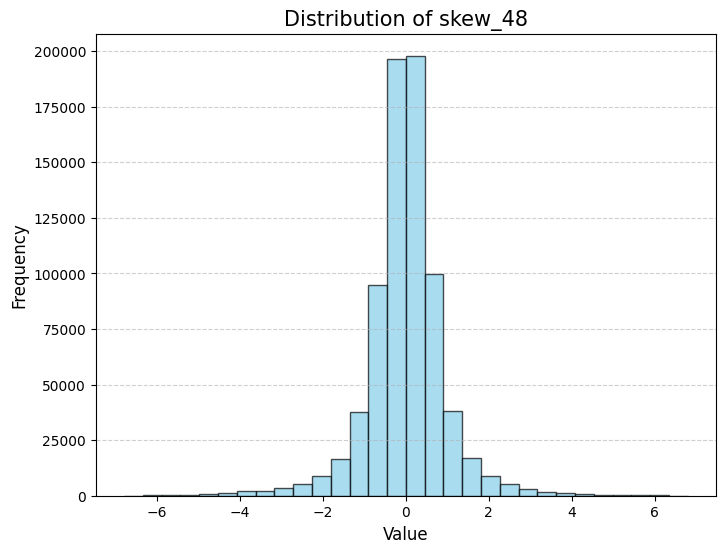

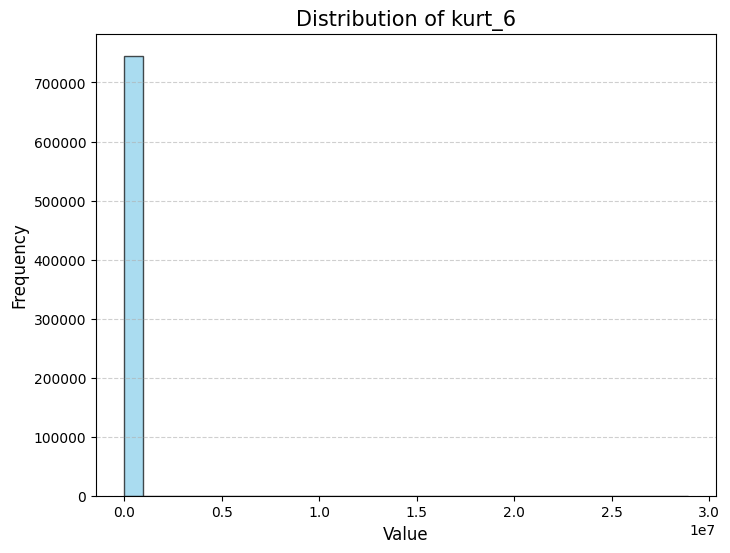

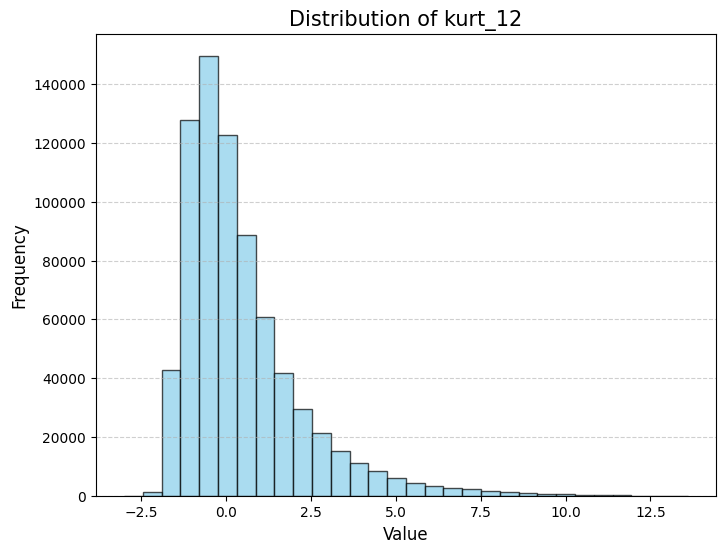

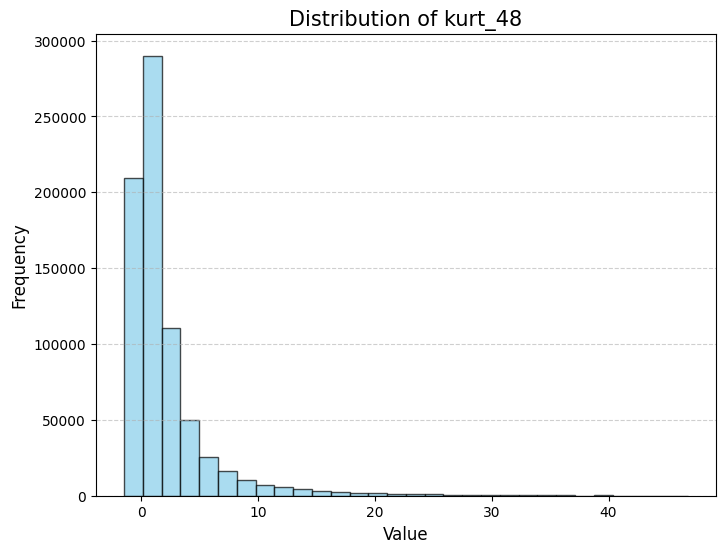

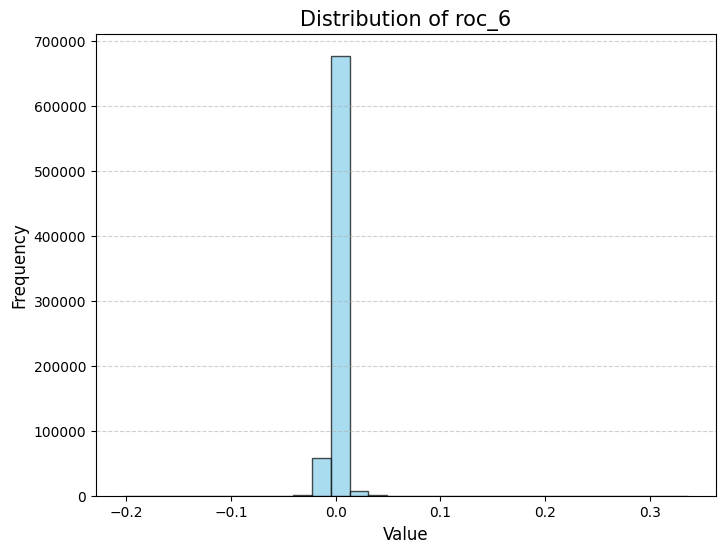

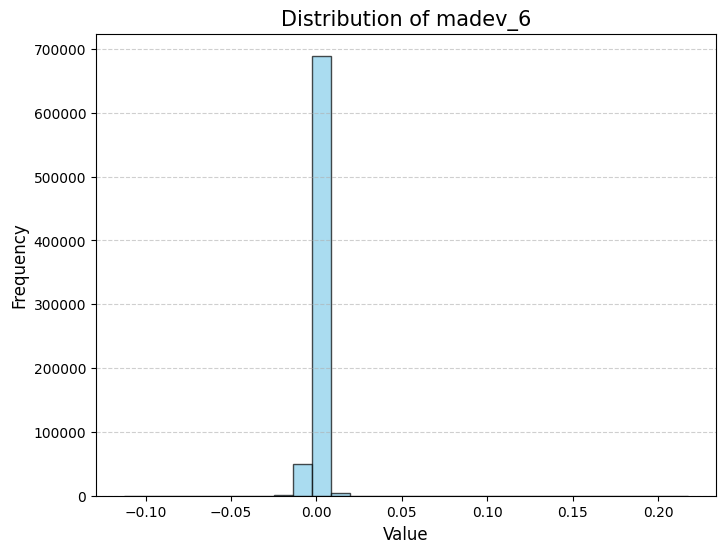

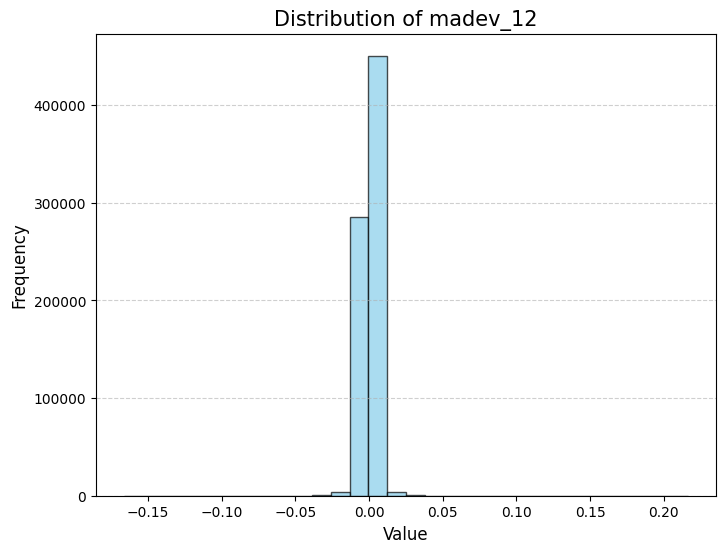

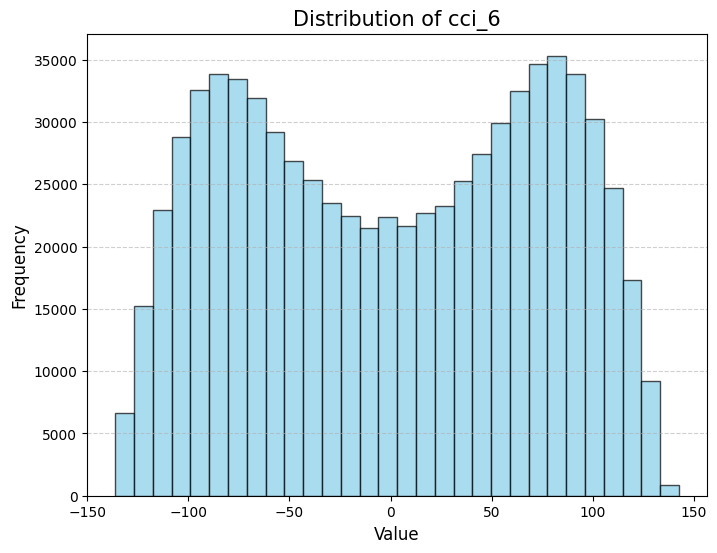

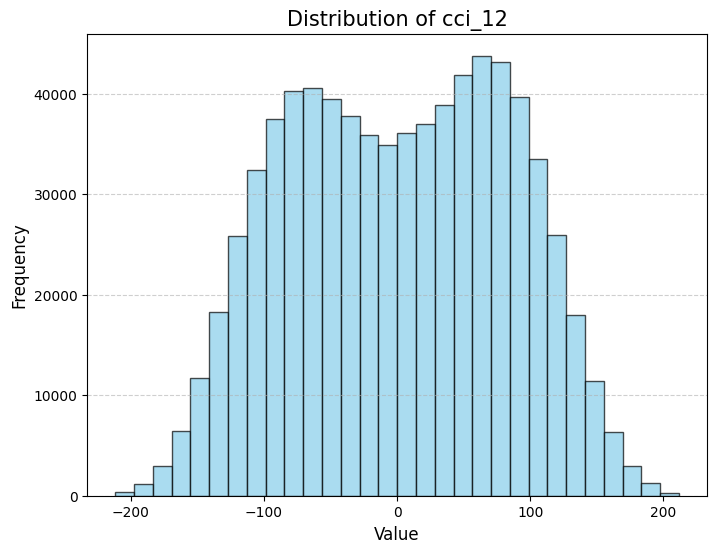

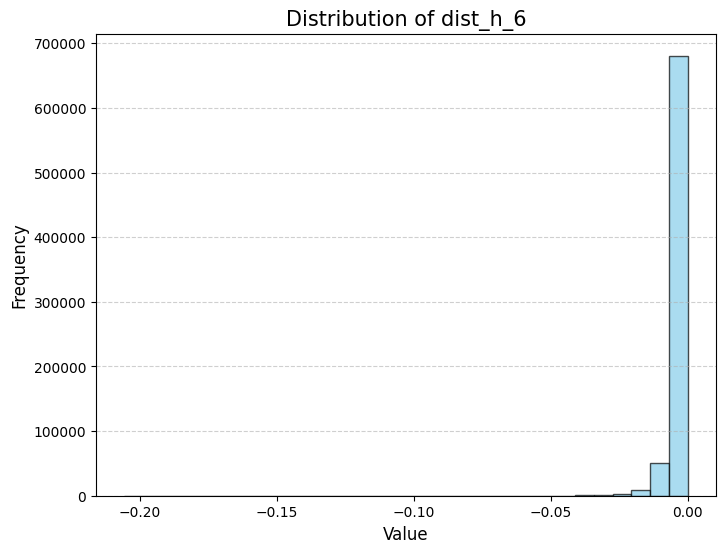

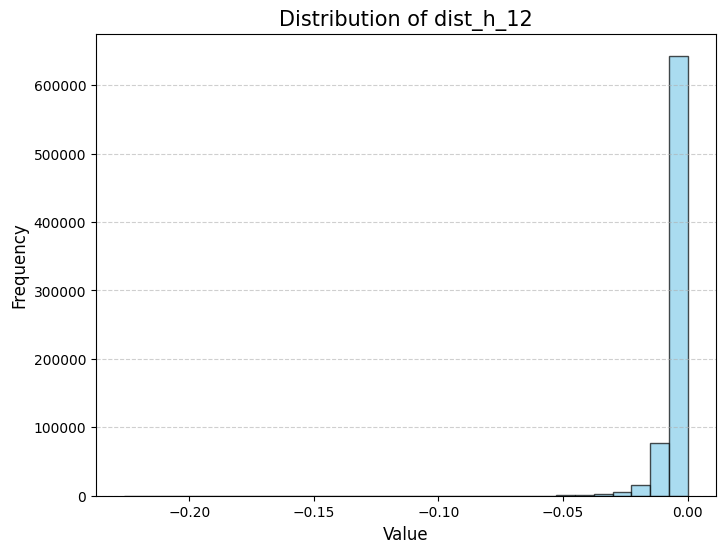

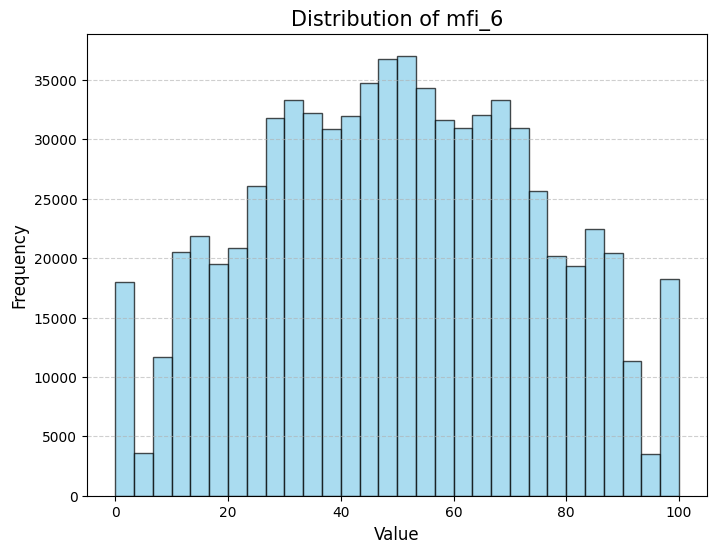

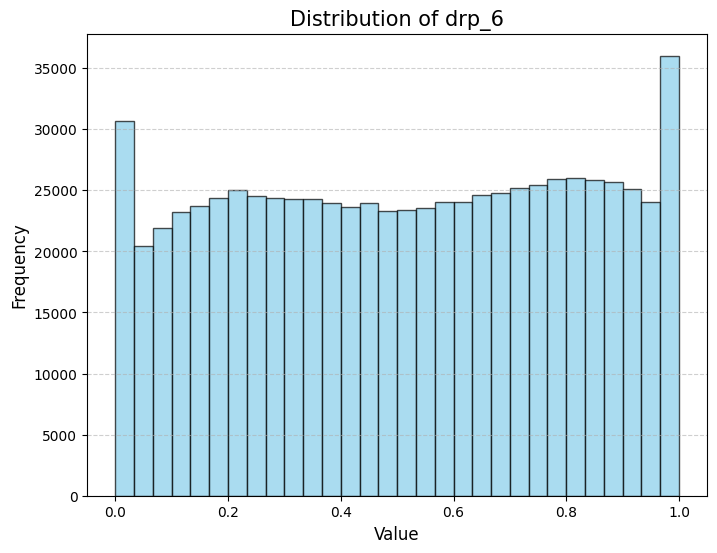

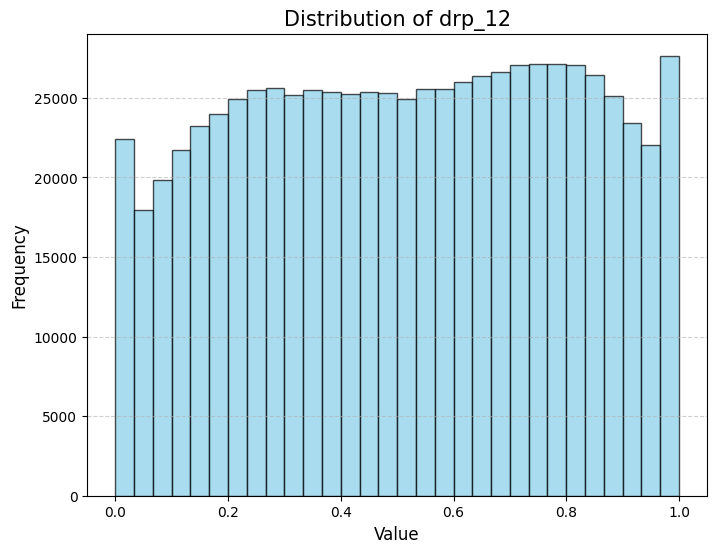

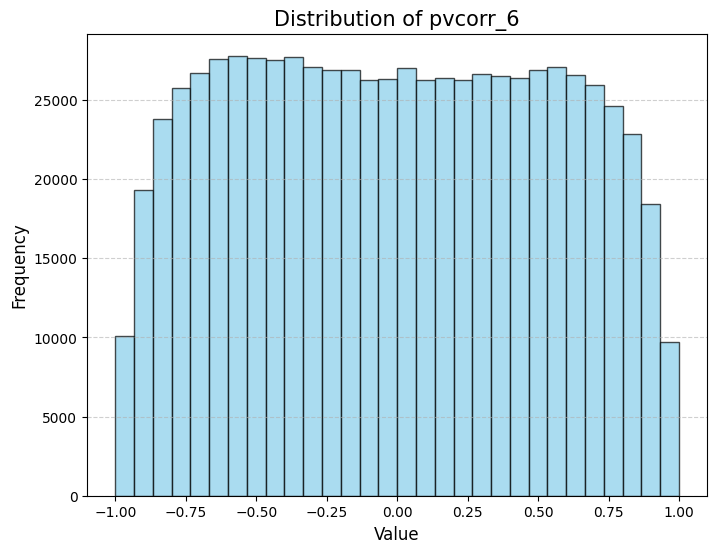

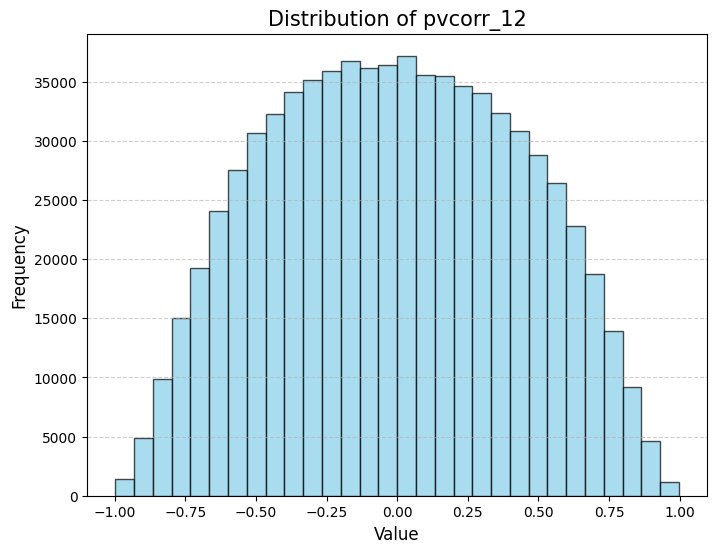

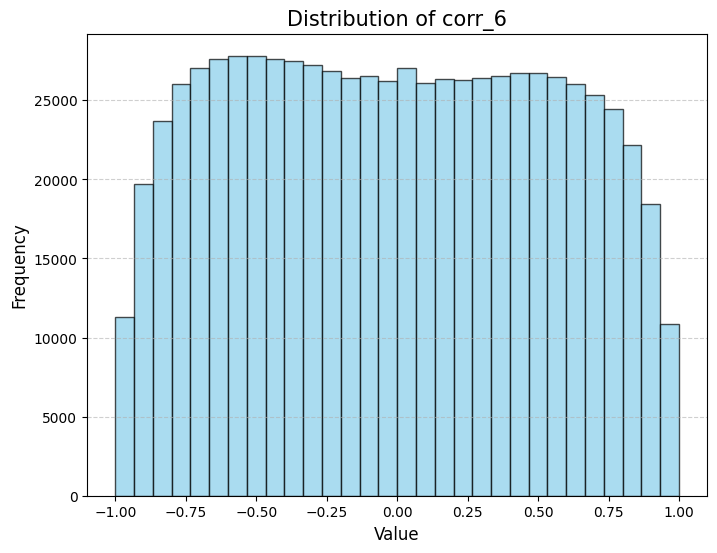

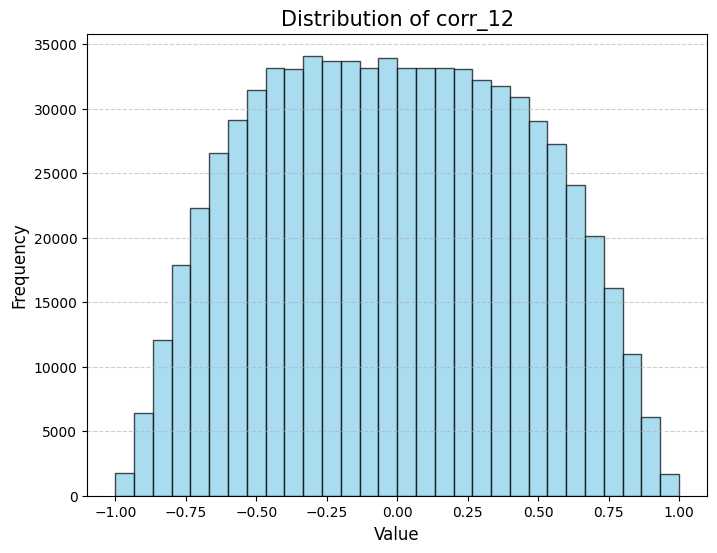

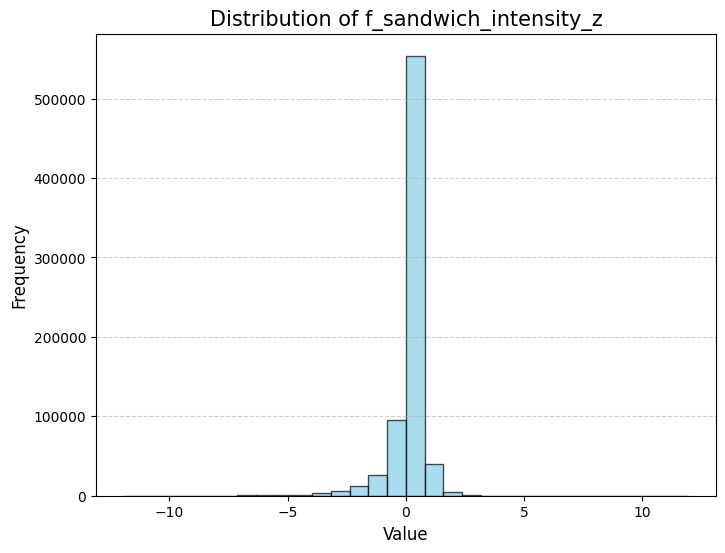

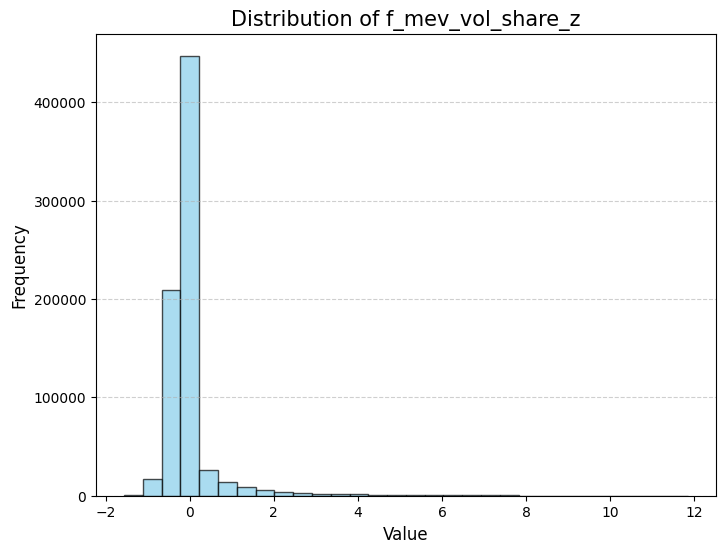

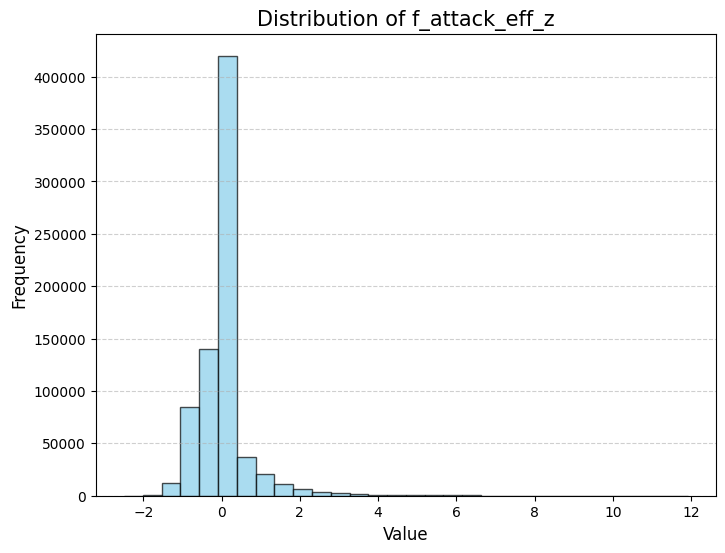

In [61]:
import matplotlib.pyplot as plt
import numpy as np

for i in range(len(result_list)):
    for j in range(len(result_list[i][1])):
        factor_name = result_list[i][1][j]  # 获取第i个簇的第j个因子名称
        data = factors_cleaned[factor_name]
        # 2. 创建画布
        plt.figure(figsize=(8, 6))
        # 3. 绘制直方图
        # bins: 决定条形的数量（组距）
        # color: 条形的颜色
        # edgecolor: 条形边缘的颜色
        # alpha: 透明度 (0-1)
        # density: 如果为 True，则显示频率密度而不是频数
        plt.hist(data, bins=30, color='skyblue', edgecolor='black', alpha=0.7)

        # 4. 添加装饰
        plt.title(f'Distribution of {factor_name}', fontsize=15)
        plt.xlabel('Value', fontsize=12)
        plt.ylabel('Frequency', fontsize=12)
        plt.grid(axis='y', linestyle='--', alpha=0.6) # 添加水平虚线网格
        plt.savefig(f'plt/{factor_name}.png', dpi=300, bbox_inches='tight')
        # 5. 显示图形
        plt.show()

In [62]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def group_pca(factors, cluster_results):
    pca_results = {}
    
    # 确保 labels 的索引和 factors 的列能对上
    for cluster_label in cluster_results["group"].unique():
        factor_names = cluster_results[cluster_results["group"] == cluster_label].index
        
        # 1. 提取数据
        data = factors[factor_names].copy()
        
        # 2. 强力清洗：处理无穷大和缺失值
        data = data.replace([np.inf, -np.inf], np.nan)
        # 用均值填充比用 0 稍微稳健点，或者继续用 0 也可以
        data = data.fillna(0) 
        
        # 3. 分情况处理
        if len(factor_names) == 1:
            # 单因子簇：没必要 PCA，直接取原值
            # 这里的 .values 会返回 (700000,) 的一维数组
            pca_results[cluster_label] = data.iloc[:, 0].values
        else:
            # 多因子簇：进行标准化 + PCA
            try:
                # 簇内标准化 (Z-Score)
                scaled_data = StandardScaler().fit_transform(data)
                
                # 提取第一主成分
                pca = PCA(n_components=1)
                pc1 = pca.fit_transform(scaled_data)
                
                # 存储结果 (flatten 保证是一维)
                pca_results[cluster_label] = pc1.flatten()
                
                # 打印一点调试信息，看看每个簇 PC1 的解释力度
                # print(f"Cluster {cluster_label} PC1 Variance Ratio: {pca.explained_variance_ratio_[0]:.2f}")
                
            except Exception as e:
                print(f"Cluster {cluster_label} PCA 失败: {e}")
                # 兜底方案：如果 PCA 失败，取均值
                pca_results[cluster_label] = data.mean(axis=1).values
                
    # 转回 DataFrame 方便后续回测，Index 保持一致
    return pd.DataFrame(pca_results, index=factors.index)

# 调用
pca_factors_df = group_pca(factors, labels)
print(pca_factors_df)

                           4         10        7         1         0   \
2019-01-01 00:00:00 -0.006022 -1.362753 -0.878390 -4.764671 -1.106718   
2019-01-01 00:05:00 -0.006022 -1.362753 -0.878390 -4.764671 -1.106718   
2019-01-01 00:10:00 -0.006022 -1.362753 -0.878390 -4.764671 -1.106718   
2019-01-01 00:15:00 -0.006022 -1.362753 -0.878390 -4.764671 -1.106718   
2019-01-01 00:20:00 -0.006022 -1.362753 -0.878390 -4.764671 -1.106718   
...                       ...       ...       ...       ...       ...   
2026-01-31 23:35:00 -2.189107  2.360967  3.049758  1.791168  2.048165   
2026-01-31 23:40:00 -0.180754  1.439665  2.764732  1.476402  1.780353   
2026-01-31 23:45:00  0.117790 -0.742363  2.376224  1.093876  0.523849   
2026-01-31 23:50:00 -0.080528 -1.131168  2.346697  1.097342  0.197375   
2026-01-31 23:55:00 -0.608819 -1.403902  2.179497  1.195504  0.154594   

                           3         6         5         8         9   \
2019-01-01 00:00:00 -3.660115 -2.167603 -2.498339 

# 3. 对收益率绝对值IC(看大小)

In [174]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_factor_ic_bar(factors: pd.Series, result: pd.Series, bins=20, factor_name="Factor"):
    # 1. 数据对齐与准备
    data = pd.DataFrame({'factor': factors, 'result': result})
    
    # 使用 rank(method='first') 强制分组，确保每个数据都有位置
    data["rank"] = data["factor"].rank(method='first')
    
    # 2. 统一分组（使用 qcut 确保每组人数相等）
    # labels=False 返回 0, 1, 2... 这样的整数索引，作为横坐标
    data["group"] = pd.qcut(data["rank"], q=bins, labels=False)
    
    # 3. 计算统计量
    # 核心：计算每组的收益均值
    group_stats = data.groupby('group')['result'].mean()
    # 核心：计算每组的因子数值边界（用来做横轴标签）
    group_factor_range = data.groupby('group')['factor'].mean() 
    # 计算每组样本量（虽然 qcut 理论上是平均的，但画出来可以确认分布）
    group_counts = group_factor_range
    # 计算每组胜率
    group_win_rate = data.groupby('group')['result'].apply(lambda x: (x > 0).mean())

    # 4. 绘图
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # 横坐标使用 group 的整数索引：0, 1, 2, ..., bins-1
    x_axis = np.arange(bins)

    # 绘制左轴：因子分布（柱状图）
    ax1.bar(x_axis, group_counts, color='skyblue', alpha=1, 
            edgecolor='white', label = "Factor Value per Group")
    ax1.set_xlabel(f'{factor_name} Groups (From Low to High)')
    ax1.set_ylabel('Factor Value')

    # 5. 绘制右轴：收益率（折线图）
    ax2 = ax1.twinx()
    # 确保 x_axis 和 group_stats.values 长度一致
    ax2.plot(x_axis, group_stats, color='red', marker='o', alpha=0.4,
               linewidth=2, label='Mean Return per Group')
    
    # 6. 优化 X 轴标签：显示该组因子的平均值
    # 每隔几个显示一个标签，防止太挤
    step = max(1, bins // 10)
    ax1.set_xticks(x_axis[::step])
    ax1.set_xticklabels([f"{val:.2f}" for val in group_factor_range.values[::step]])


    # 图例合并
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

    plt.title(f'{factor_name} Decile Analysis: Distribution vs. Returns')
    plt.tight_layout()
    plt.show()


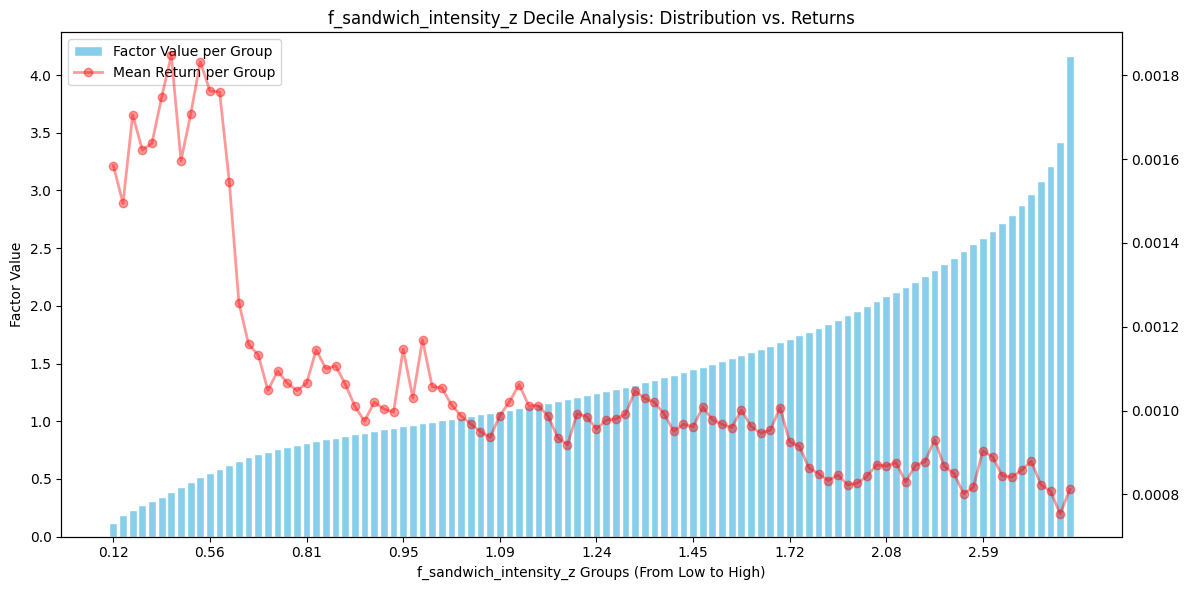

f_sandwich_intensity_z Spearman Rank IC: -0.1663 (Filtered) / -0.1461 (Unfiltered)


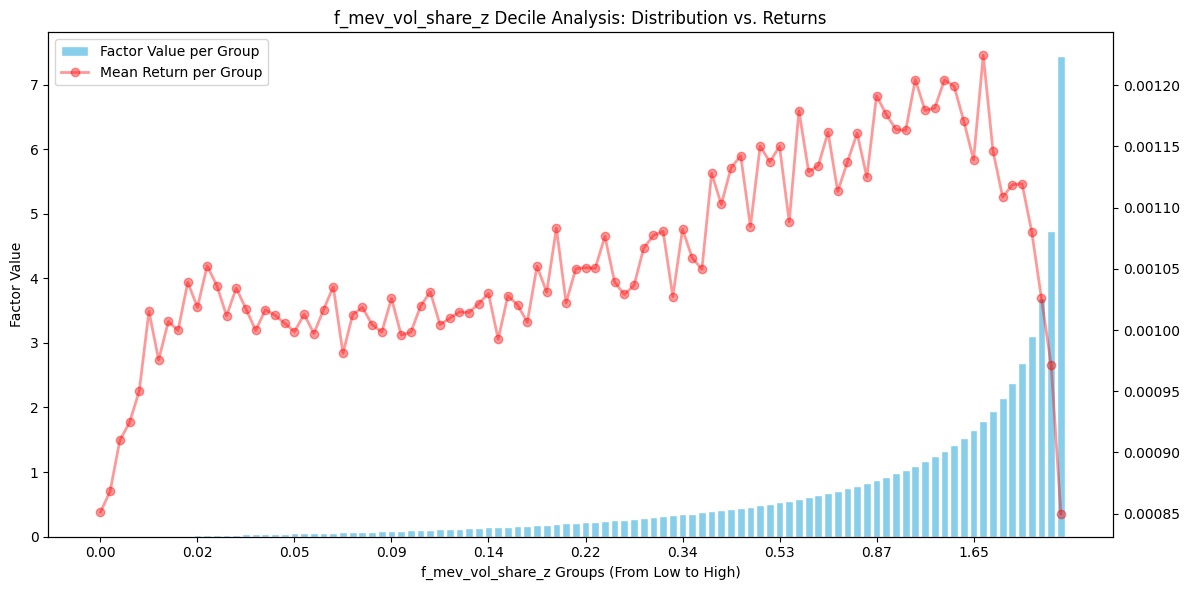

f_mev_vol_share_z Spearman Rank IC: 0.0480 (Filtered) / -0.0802 (Unfiltered)


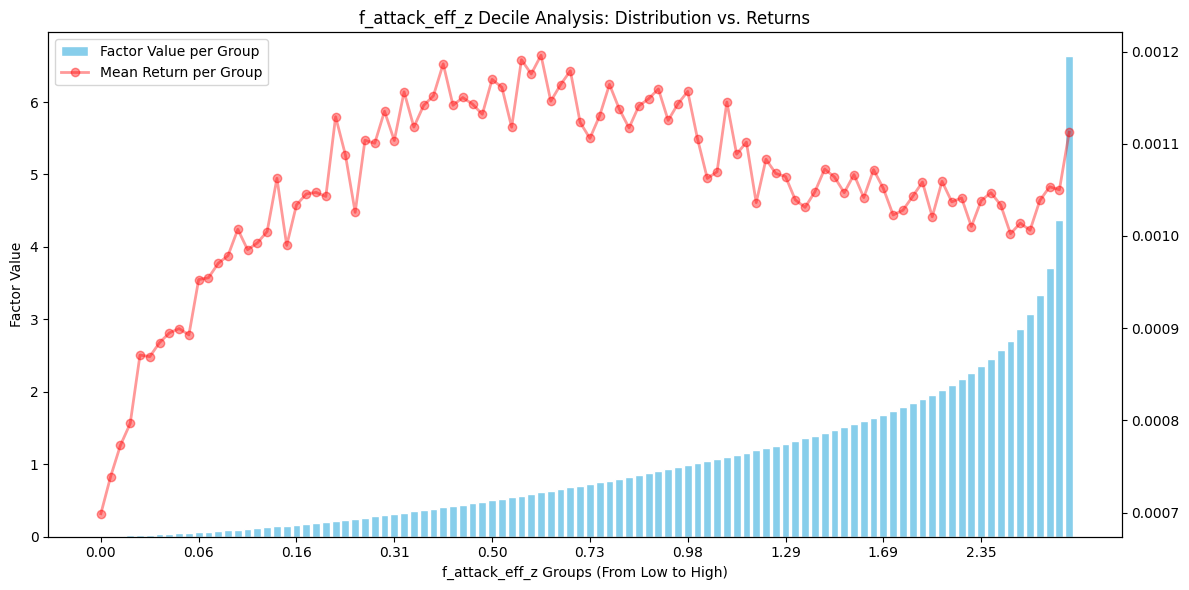

f_attack_eff_z Spearman Rank IC: 0.0153 (Filtered) / -0.0923 (Unfiltered)


In [175]:
import matplotlib.pyplot as plt
import numpy as np

target_returns = market['close'].pct_change().shift(-1).abs()

for i in range(len(result_list)-3,len(result_list)):
    for j in range(len(result_list[i][1])):
        factor_name = result_list[i][1][j] 
        plot_factor_ic_bar(factors[factor_name][factors[factor_name]!=0], target_returns,bins=100,factor_name=factor_name)

        rkic_1 = factors[factor_name][factors[factor_name]!=0].corr(target_returns, method='spearman')
        rkic_0 = factors[factor_name].corr(target_returns, method='spearman')
        print(f"{factor_name} Spearman Rank IC: {rkic_1:.4f} (Filtered) / {rkic_0:.4f} (Unfiltered)")

# 4. 对收益率 IC （看方向）

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_factor_ic_bar(factors: pd.Series, result: pd.Series, bins=20, factor_name="Factor"):
    # 1. 数据对齐与准备
    data = pd.DataFrame({'factor': factors, 'result': result})
    
    # 使用 rank(method='first') 强制分组，确保每个数据都有位置
    data["rank"] = data["factor"].rank(method='first')
    
    # 2. 统一分组（使用 qcut 确保每组人数相等）
    # labels=False 返回 0, 1, 2... 这样的整数索引，作为横坐标
    data["group"] = pd.qcut(data["rank"], q=bins, labels=False)
    
    # 3. 计算统计量
    # 核心：计算每组的收益均值
    group_stats = data.groupby('group')['result'].mean()
    # 核心：计算每组的因子数值边界（用来做横轴标签）
    group_factor_range = data.groupby('group')['factor'].mean() 
    # 计算每组样本量（虽然 qcut 理论上是平均的，但画出来可以确认分布）
    group_counts = group_factor_range
    # 计算每组胜率
    group_win_rate = data.groupby('group')['result'].apply(lambda x: (x > 0).mean())

    # 4. 绘图
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # 横坐标使用 group 的整数索引：0, 1, 2, ..., bins-1
    x_axis = np.arange(bins)

    # 绘制左轴：因子分布（柱状图）
    ax1.bar(x_axis, group_counts, color='skyblue', alpha=1, 
            edgecolor='white', label = "Factor Value per Group")
    ax1.set_xlabel(f'{factor_name} Groups (From Low to High)')
    ax1.set_ylabel('Factor Value')

    # 5. 绘制右轴：收益率（折线图）
    #ax2 = ax1.twinx()
    # 确保 x_axis 和 group_stats.values 长度一致
    #ax2.plot(x_axis, group_stats, color='red', marker='o', alpha=0.4,
    #           linewidth=2, label='Mean Return per Group')
    
    # 绘制全样本平均收益基准线
    #ax2.axhline(0, color='black', lw=1, ls='--')
    #ax2.set_ylabel('Mean Return')

    # 6. 优化 X 轴标签：显示该组因子的平均值
    # 每隔几个显示一个标签，防止太挤
    step = max(1, bins // 10)
    ax1.set_xticks(x_axis[::step])
    ax1.set_xticklabels([f"{val:.2f}" for val in group_factor_range.values[::step]])


    ax3 = ax1.twinx()
    ax3.plot(x_axis, group_win_rate*100, color='green', marker='x', alpha=1, linewidth=2, label='Win Rate(%) per Group')
    ax3.set_ylabel('Win Rate')
    ax3.axhline(50, color='black', lw=1, ls='--')

    # 图例合并
    lines1, labels1 = ax1.get_legend_handles_labels()
    # lines2, labels2 = ax2.get_legend_handles_labels()
    lines3, labels3 = ax3.get_legend_handles_labels()
    #ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3, loc='upper left')

    plt.title(f'{factor_name} Decile Analysis: Distribution vs. Returns')
    plt.tight_layout()
    plt.show()


Cluster 1 with factors: ['roc_48', 'mfi_48', 'avr_48', 'pvcorr_48', 'corr_48']


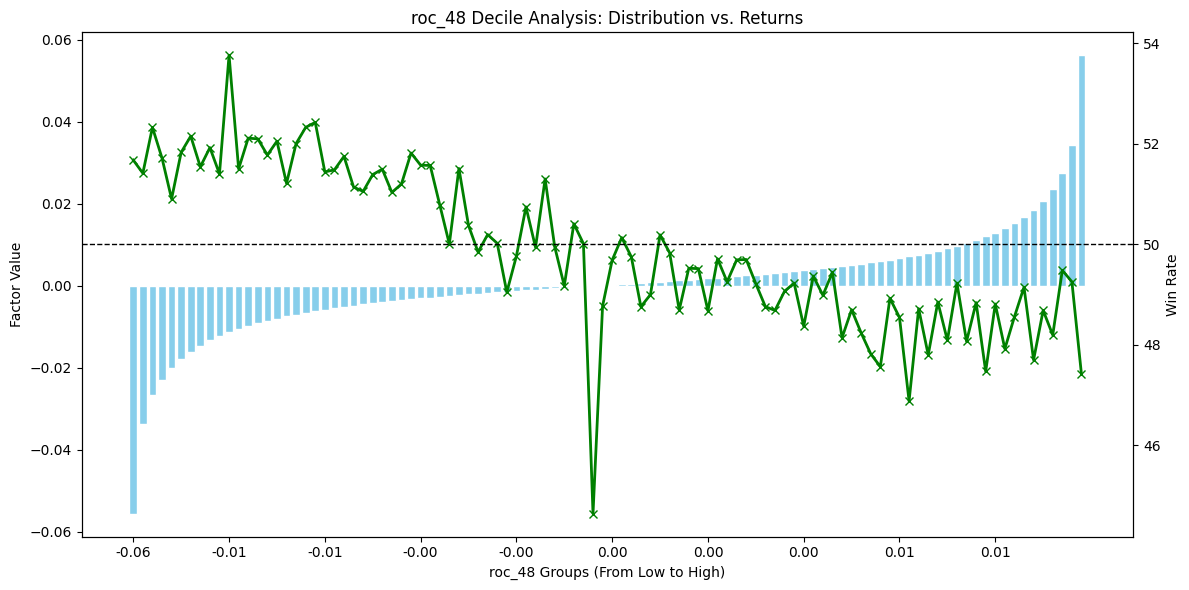

roc_48 Spearman Rank IC: -0.0248 (Filtered) / -0.0248 (Unfiltered)


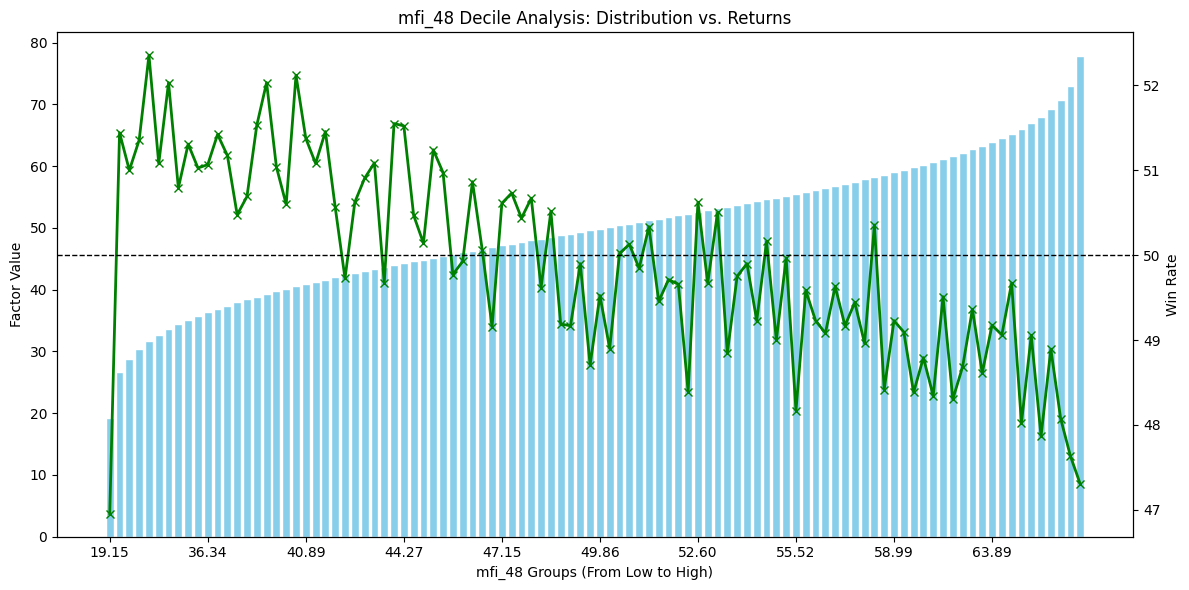

mfi_48 Spearman Rank IC: -0.0182 (Filtered) / -0.0182 (Unfiltered)


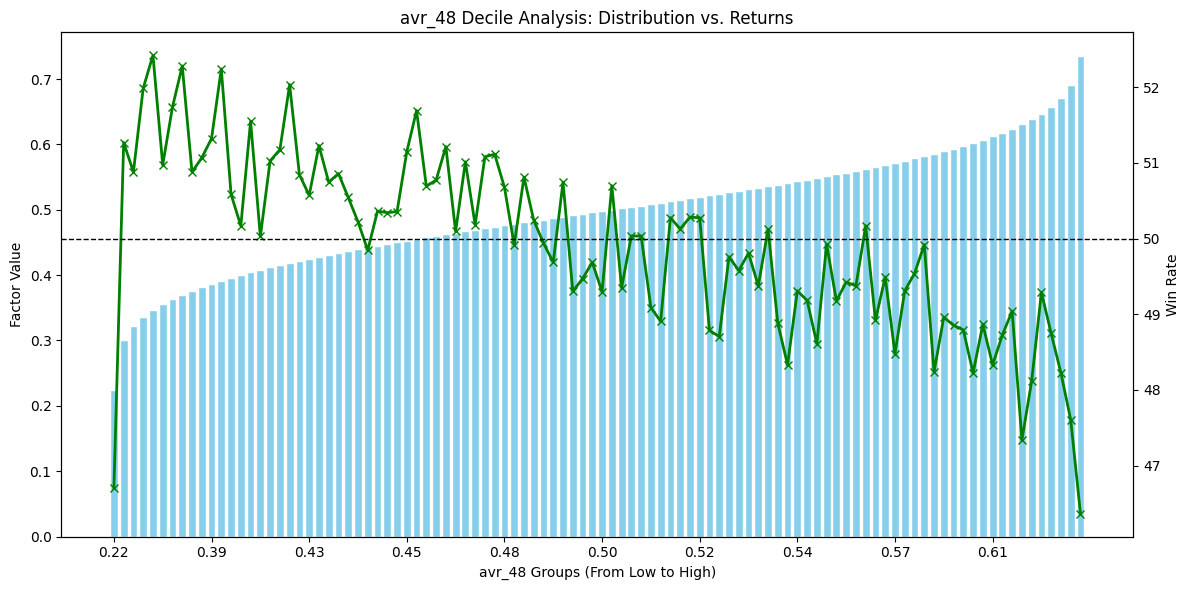

avr_48 Spearman Rank IC: -0.0191 (Filtered) / -0.0191 (Unfiltered)


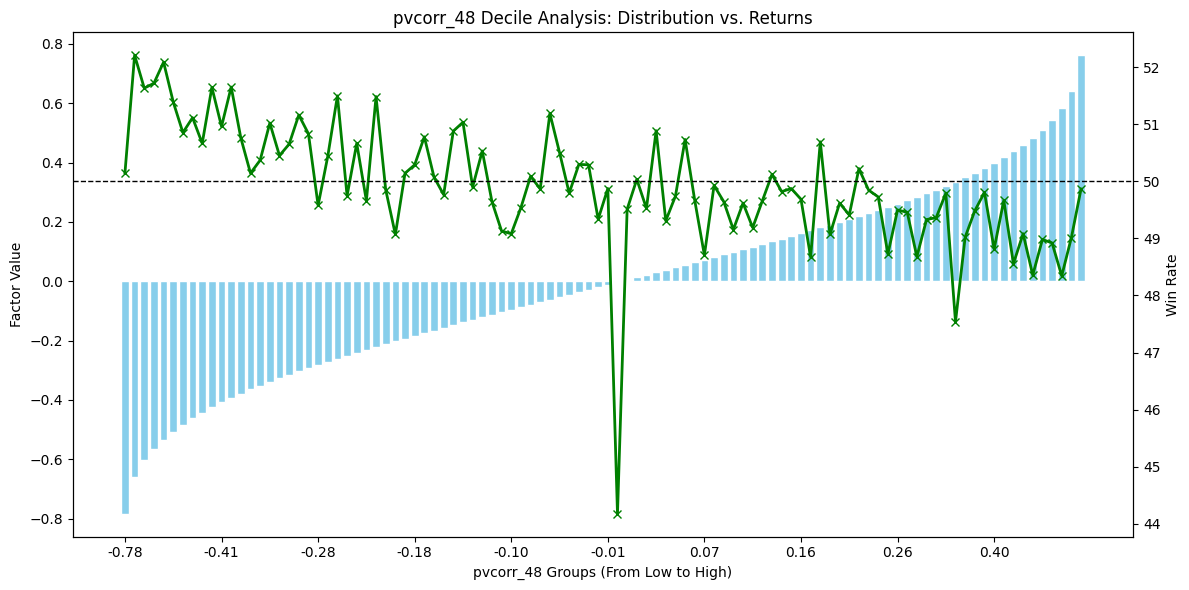

pvcorr_48 Spearman Rank IC: -0.0130 (Filtered) / -0.0130 (Unfiltered)


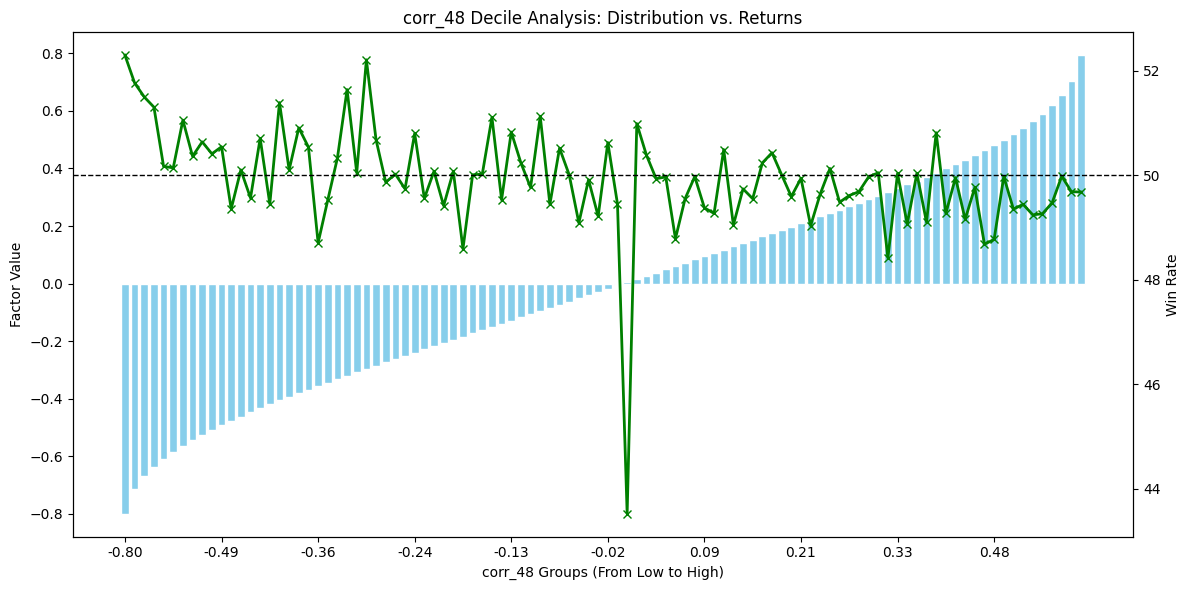

corr_48 Spearman Rank IC: -0.0075 (Filtered) / -0.0075 (Unfiltered)
Cluster 2 with factors: ['rank_6', 'rank_12', 'rank_48']


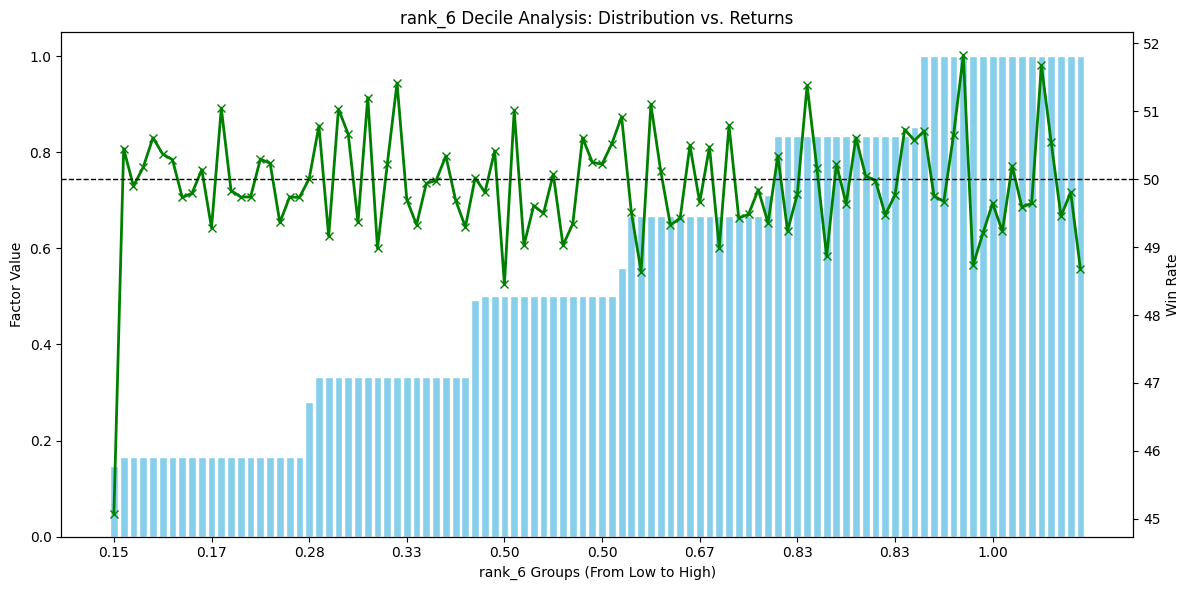

rank_6 Spearman Rank IC: -0.0005 (Filtered) / -0.0005 (Unfiltered)


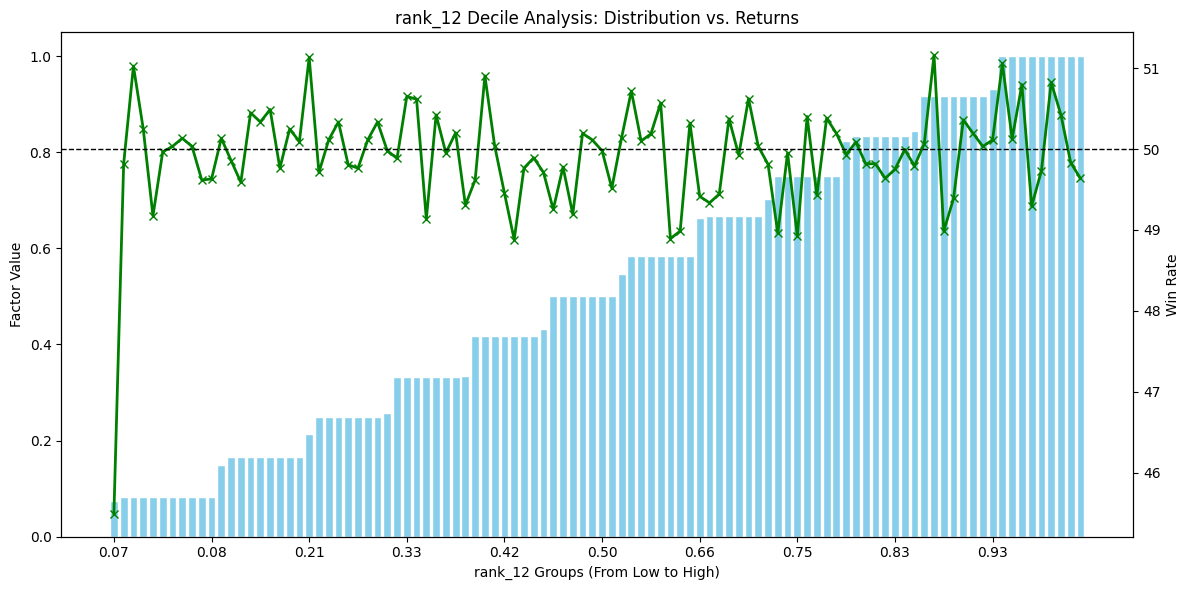

rank_12 Spearman Rank IC: -0.0001 (Filtered) / -0.0001 (Unfiltered)


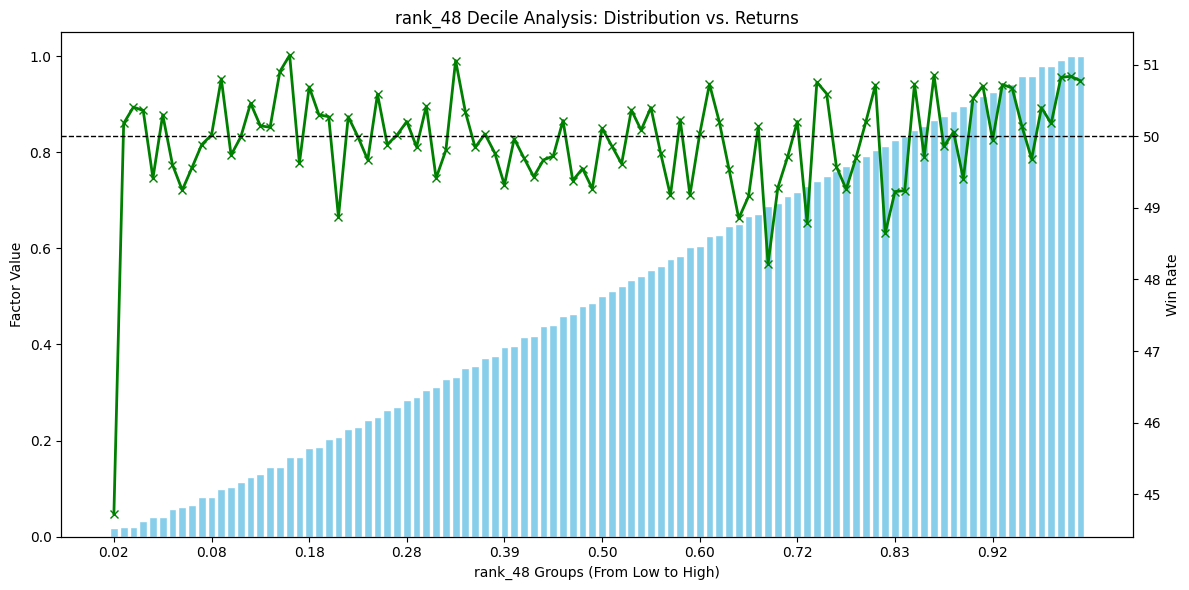

rank_48 Spearman Rank IC: 0.0006 (Filtered) / 0.0006 (Unfiltered)
Cluster 3 with factors: ['cmf_6', 'cmf_12', 'cmf_48', 'mfi_12', 'avr_6', 'avr_12']


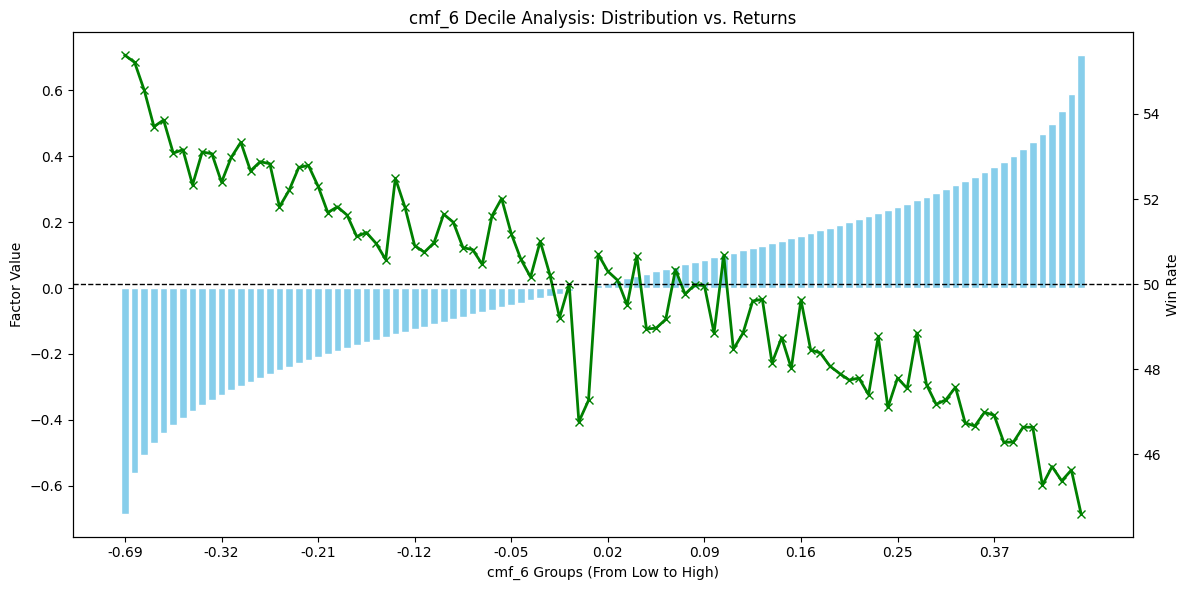

cmf_6 Spearman Rank IC: -0.0444 (Filtered) / -0.0444 (Unfiltered)


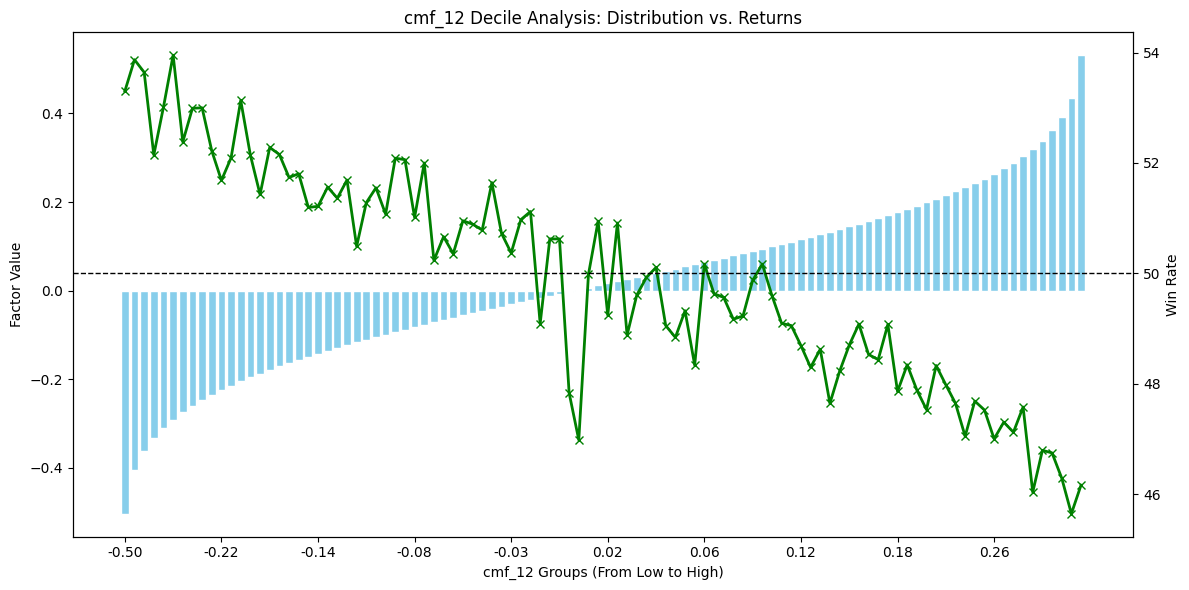

cmf_12 Spearman Rank IC: -0.0349 (Filtered) / -0.0349 (Unfiltered)


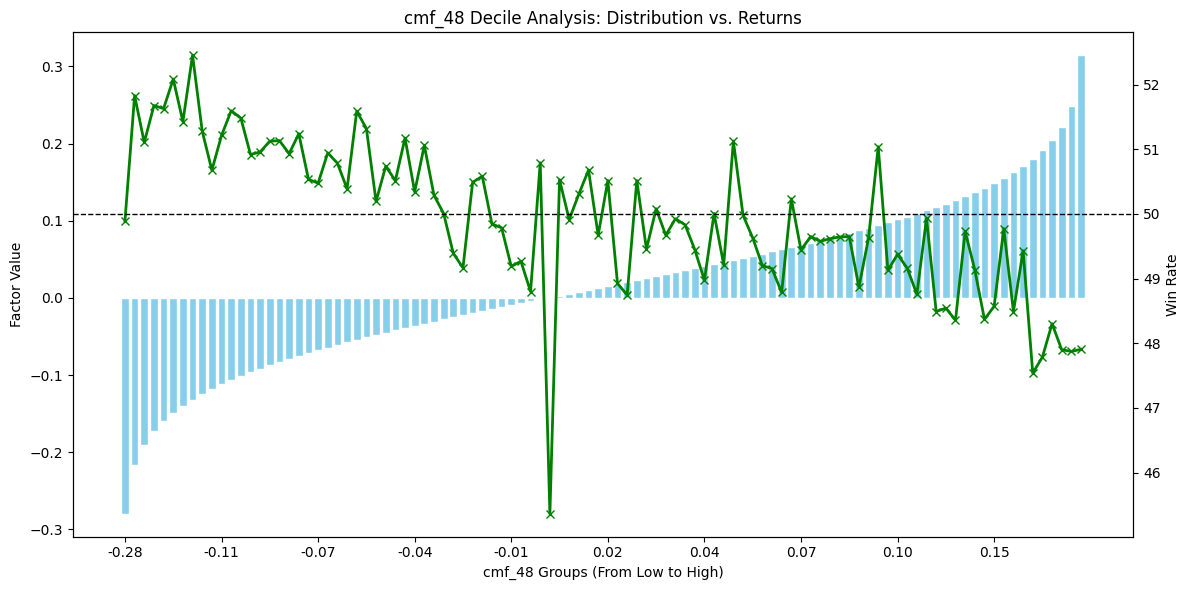

cmf_48 Spearman Rank IC: -0.0171 (Filtered) / -0.0170 (Unfiltered)


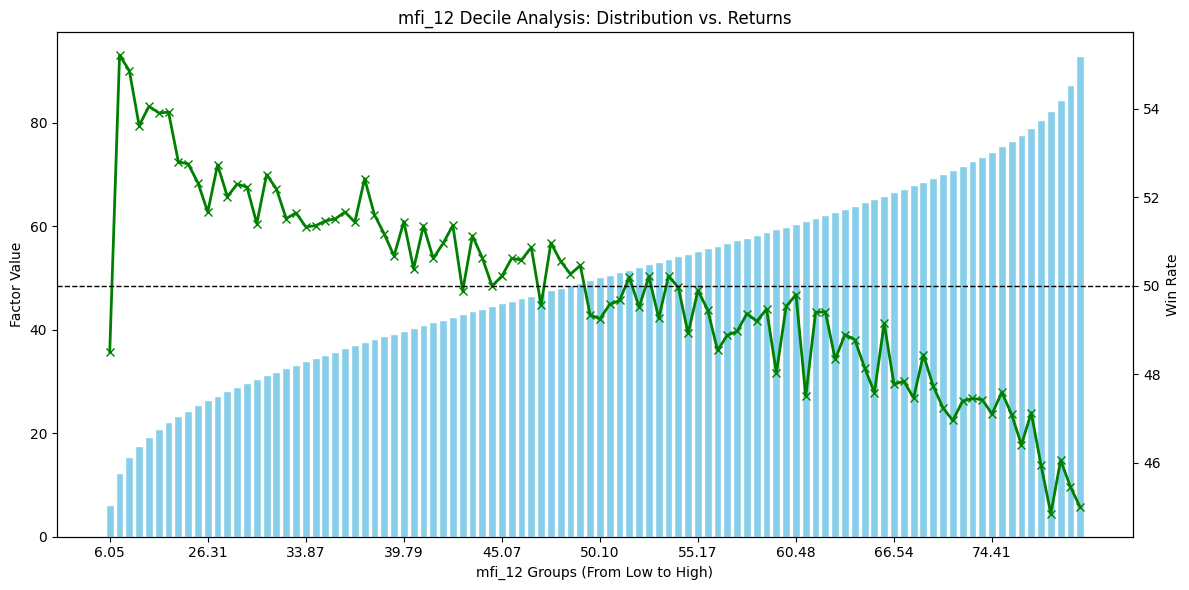

mfi_12 Spearman Rank IC: -0.0379 (Filtered) / -0.0380 (Unfiltered)


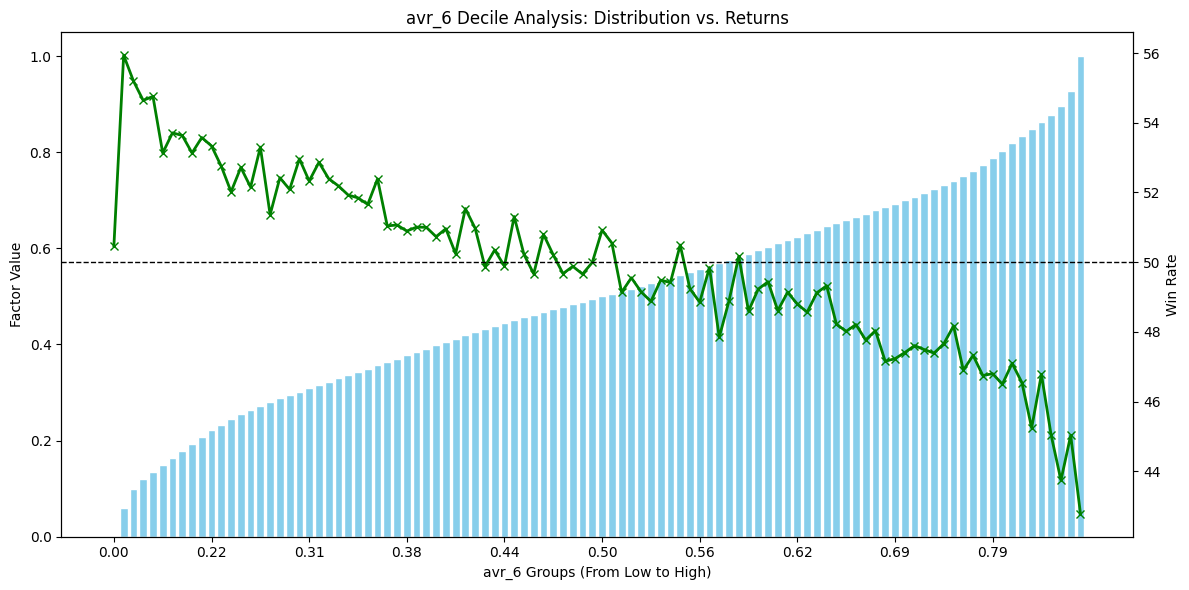

avr_6 Spearman Rank IC: -0.0465 (Filtered) / -0.0482 (Unfiltered)


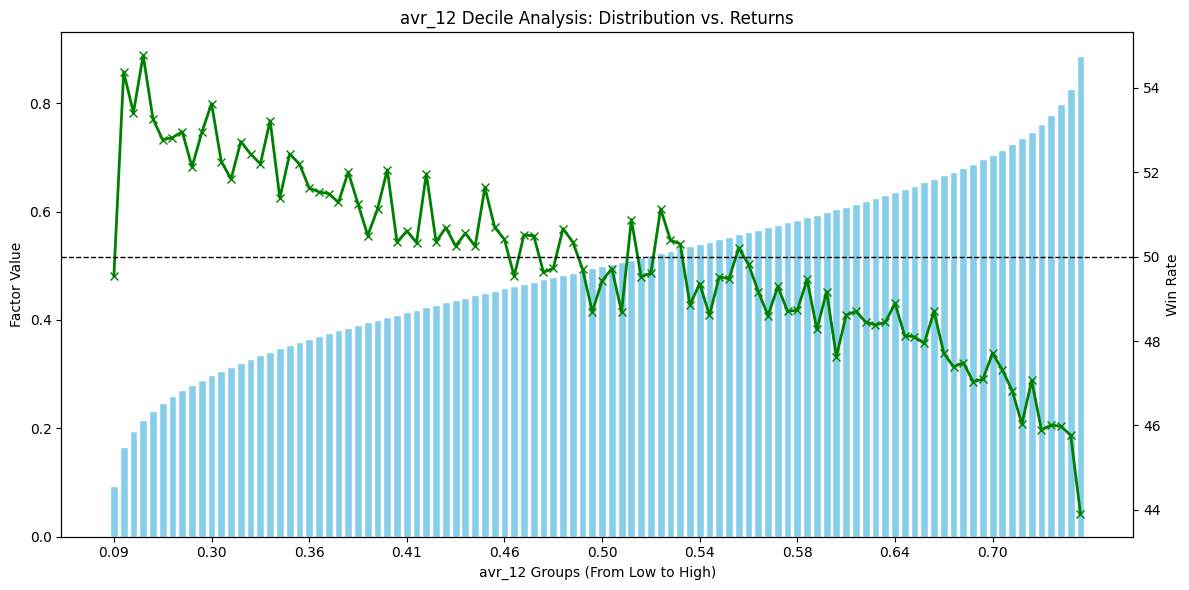

avr_12 Spearman Rank IC: -0.0382 (Filtered) / -0.0382 (Unfiltered)
Cluster 4 with factors: ['dist_l_6', 'dist_l_12']


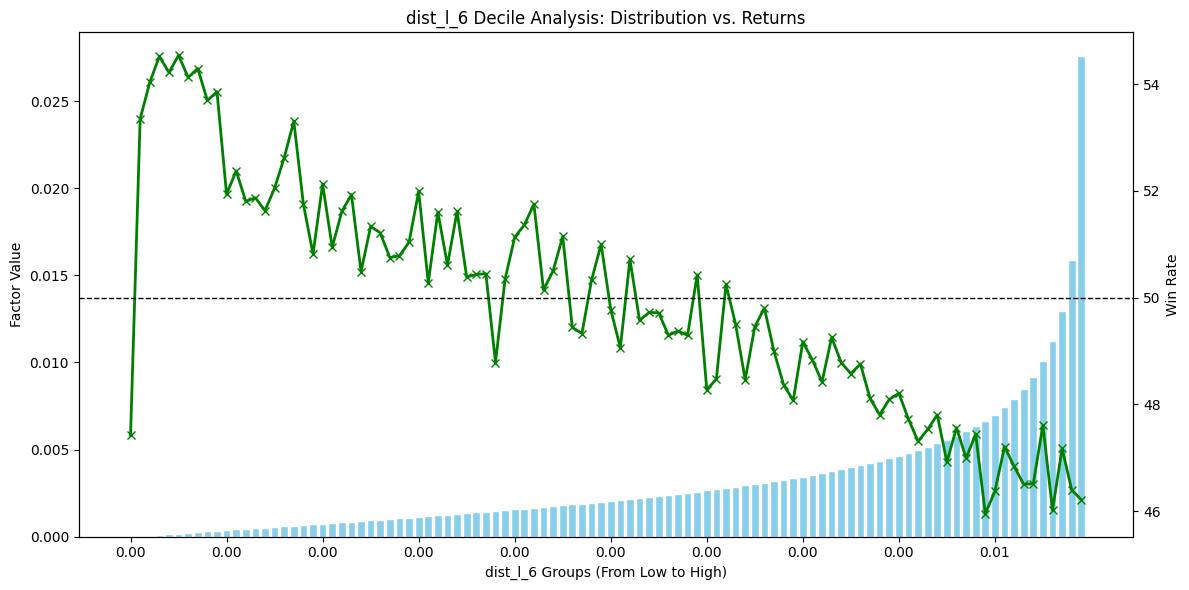

dist_l_6 Spearman Rank IC: -0.0416 (Filtered) / -0.0419 (Unfiltered)


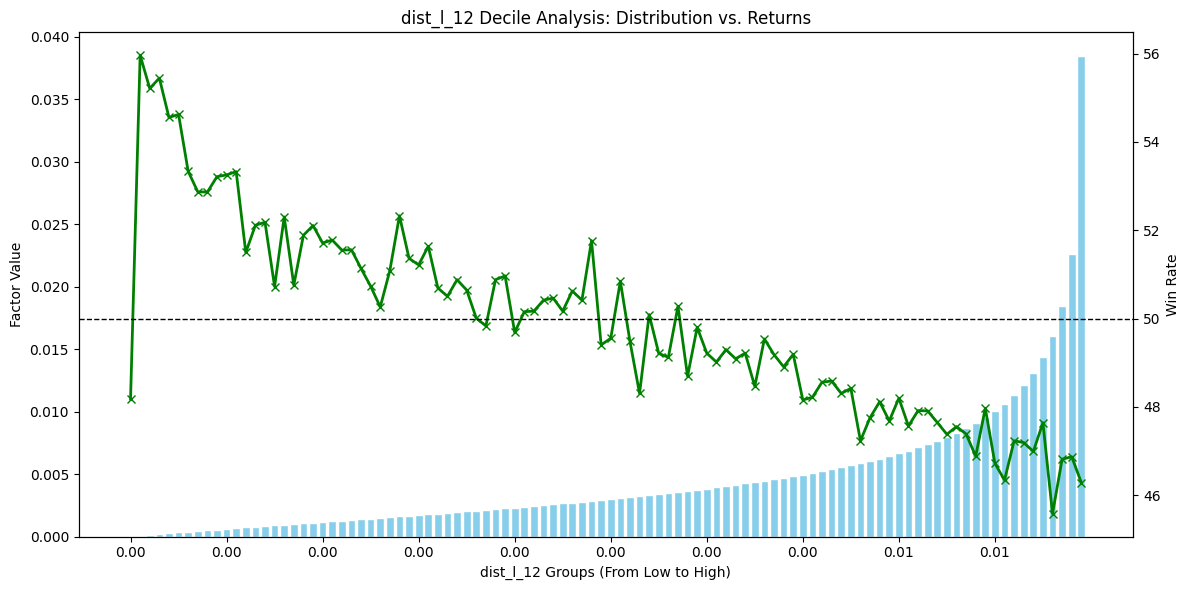

dist_l_12 Spearman Rank IC: -0.0402 (Filtered) / -0.0406 (Unfiltered)
Cluster 5 with factors: ['atr_6', 'atr_12', 'gkvol_6', 'gkvol_12', 'rvol_6', 'rvol_12']


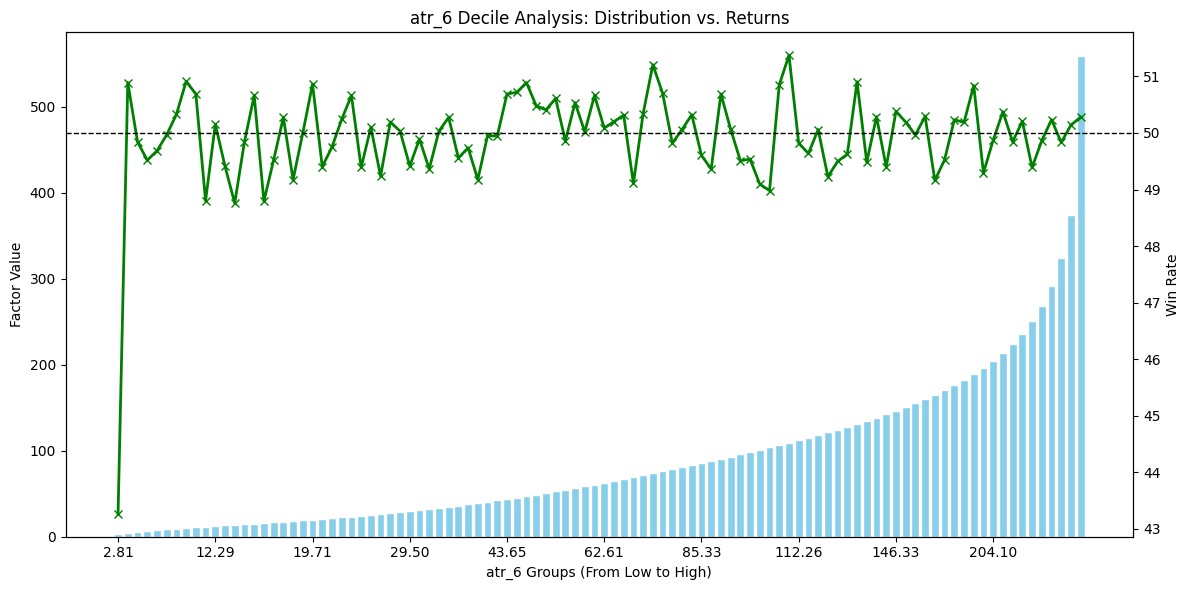

atr_6 Spearman Rank IC: -0.0019 (Filtered) / -0.0019 (Unfiltered)


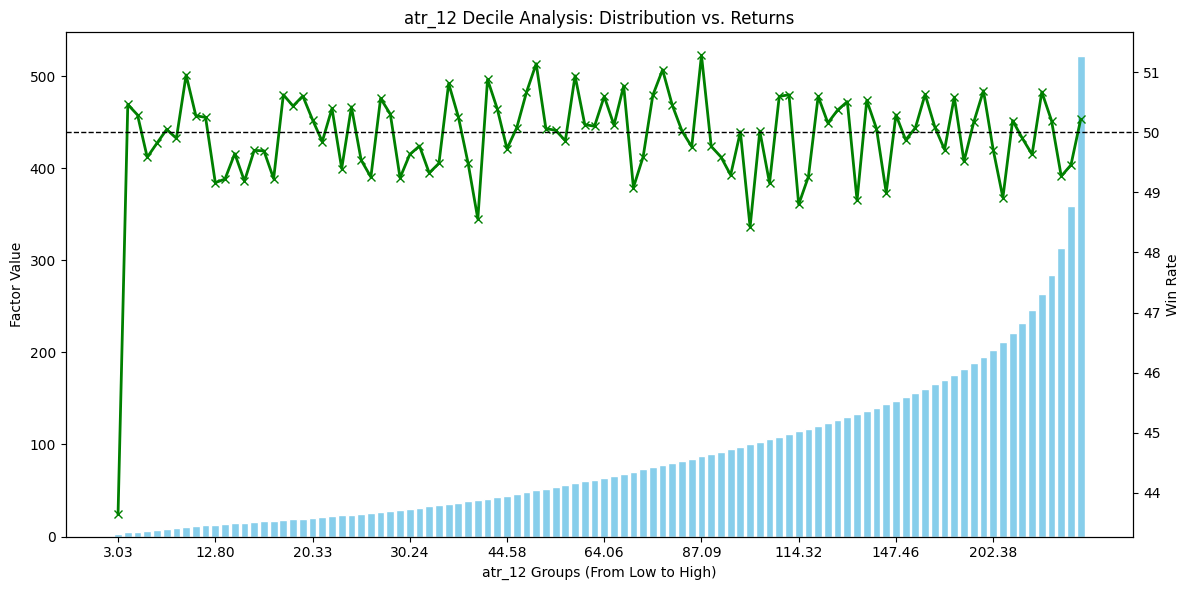

atr_12 Spearman Rank IC: -0.0024 (Filtered) / -0.0024 (Unfiltered)


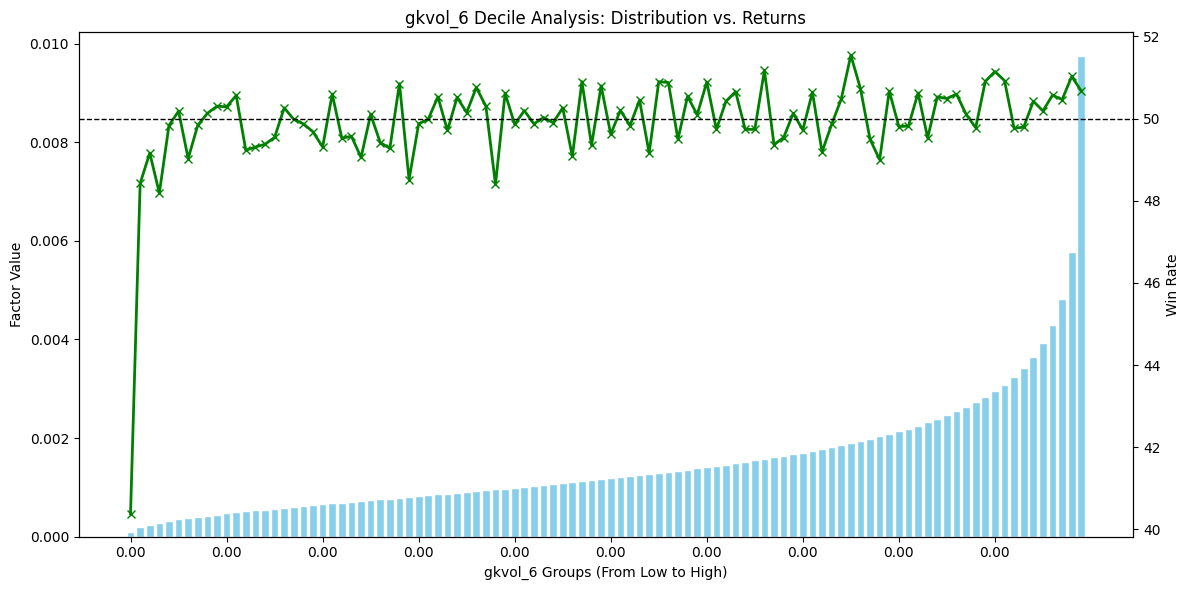

gkvol_6 Spearman Rank IC: 0.0044 (Filtered) / 0.0044 (Unfiltered)


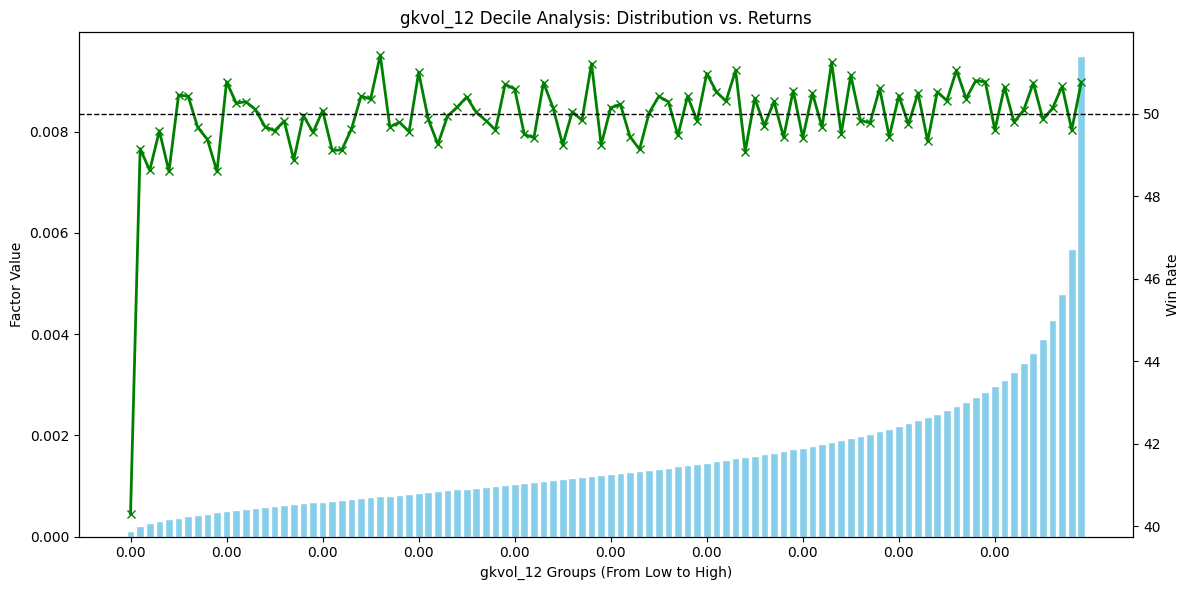

gkvol_12 Spearman Rank IC: 0.0035 (Filtered) / 0.0035 (Unfiltered)


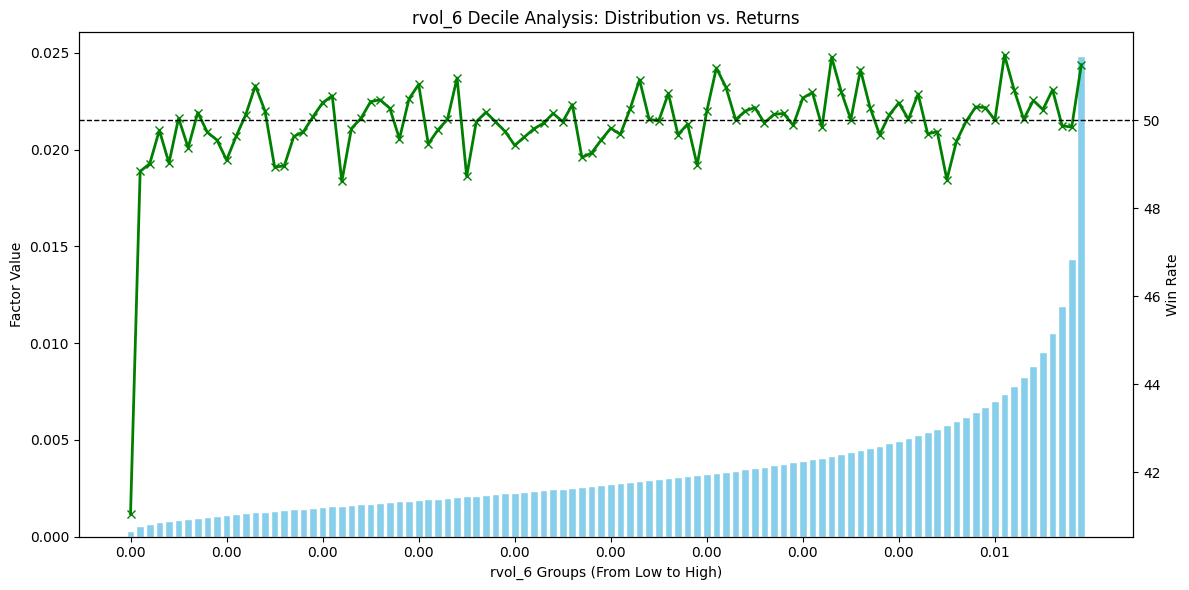

rvol_6 Spearman Rank IC: 0.0037 (Filtered) / 0.0037 (Unfiltered)


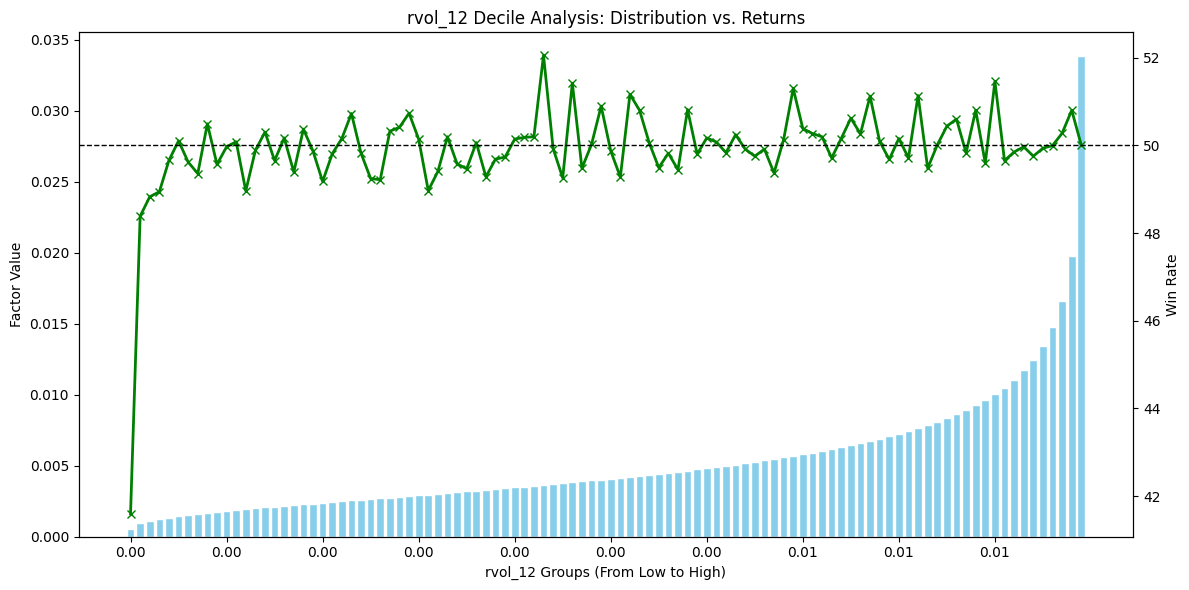

rvol_12 Spearman Rank IC: 0.0032 (Filtered) / 0.0032 (Unfiltered)
Cluster 6 with factors: ['volsu_6', 'volsu_12', 'volsu_48', 'delta_6', 'delta_12', 'delta_48']


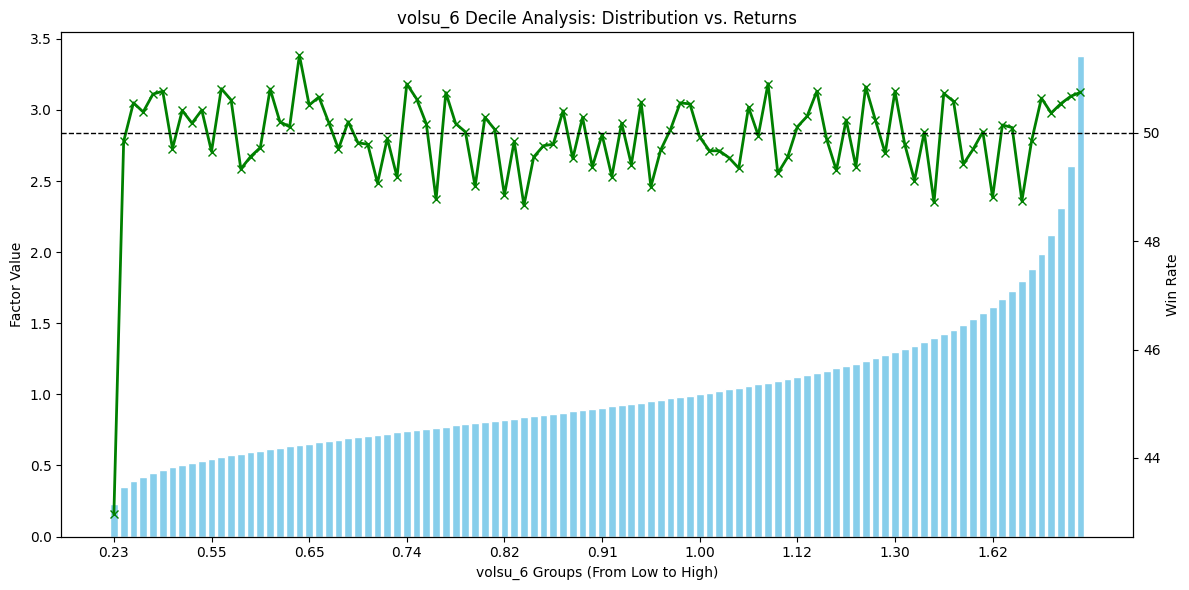

volsu_6 Spearman Rank IC: -0.0003 (Filtered) / -0.0003 (Unfiltered)


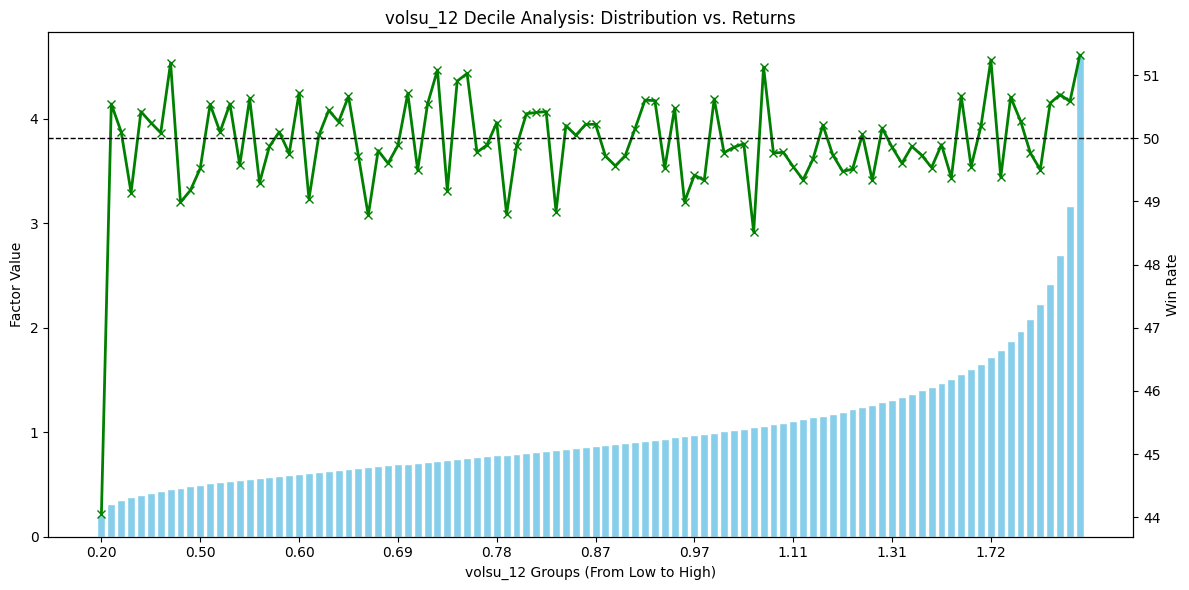

volsu_12 Spearman Rank IC: 0.0005 (Filtered) / 0.0005 (Unfiltered)


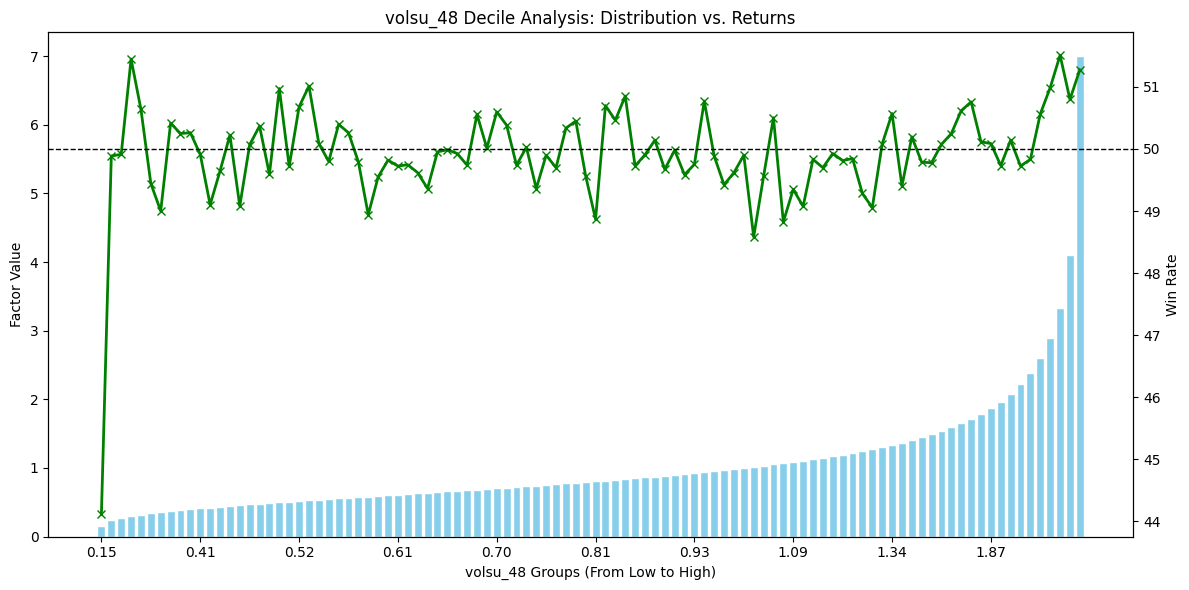

volsu_48 Spearman Rank IC: 0.0010 (Filtered) / 0.0010 (Unfiltered)


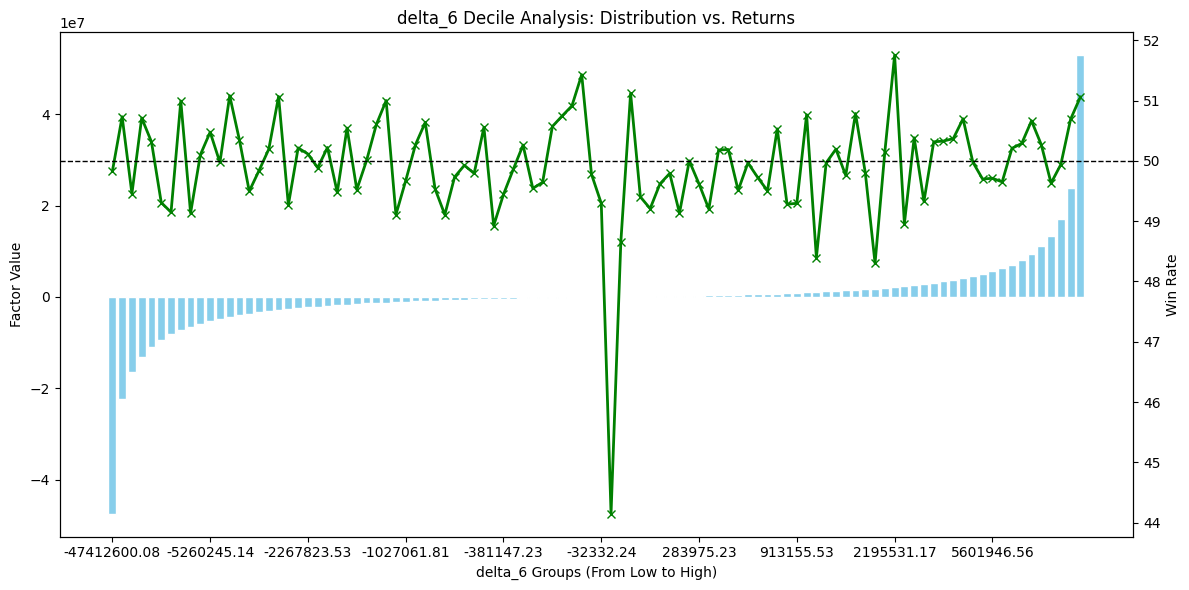

delta_6 Spearman Rank IC: 0.0008 (Filtered) / 0.0008 (Unfiltered)


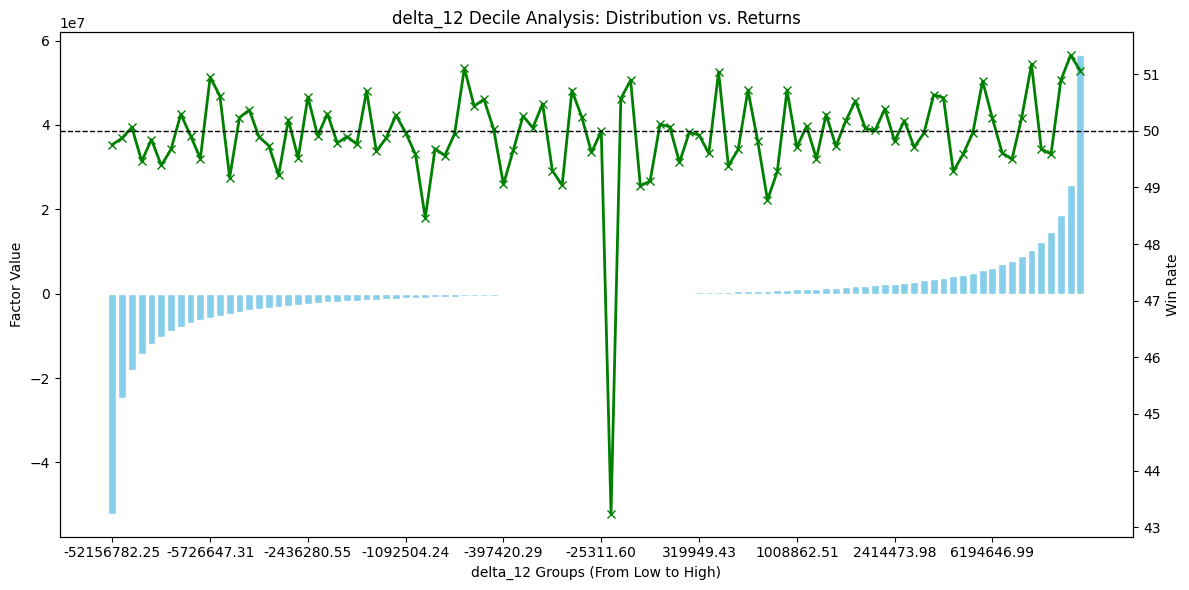

delta_12 Spearman Rank IC: 0.0026 (Filtered) / 0.0026 (Unfiltered)


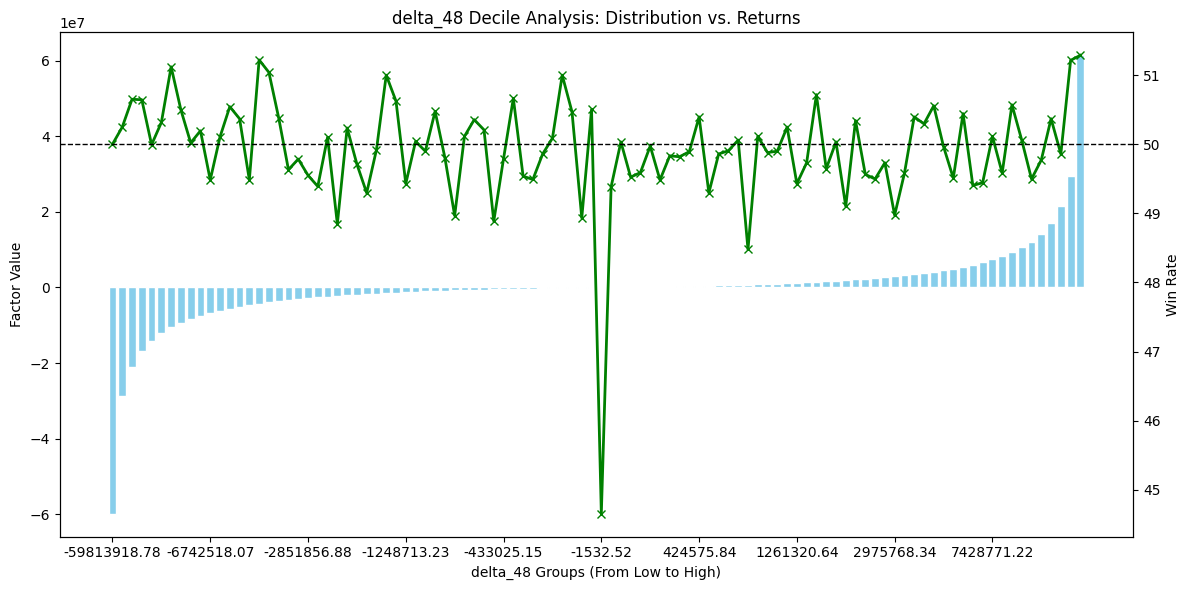

delta_48 Spearman Rank IC: -0.0007 (Filtered) / -0.0007 (Unfiltered)
Cluster 7 with factors: ['roc_12', 'madev_48', 'cci_48', 'dist_h_48', 'dist_l_48', 'drp_48']


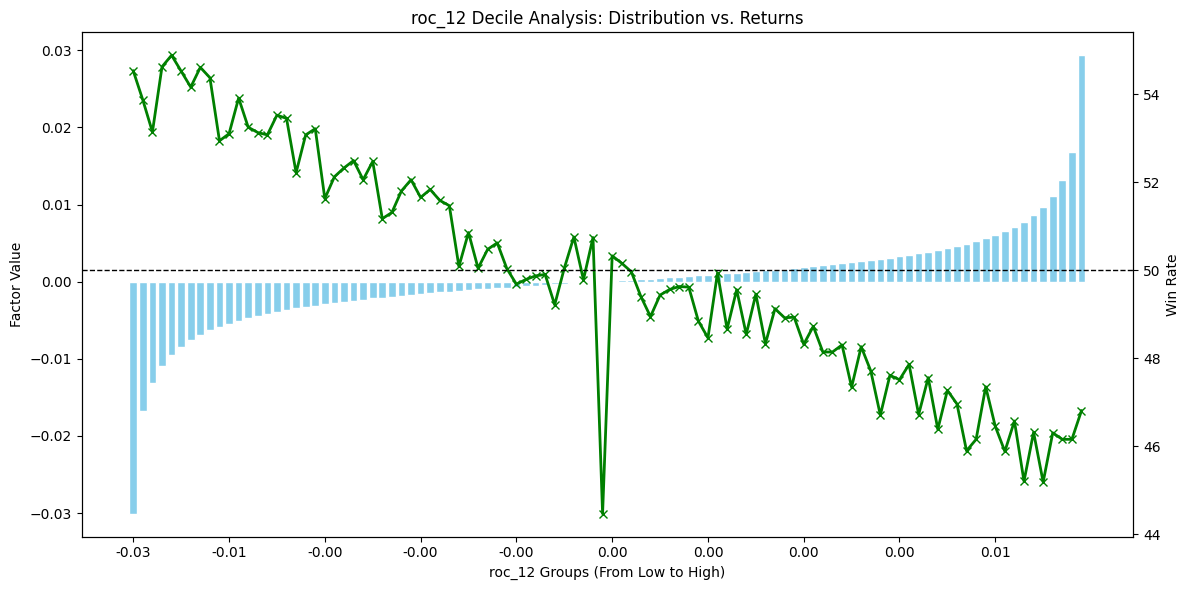

roc_12 Spearman Rank IC: -0.0467 (Filtered) / -0.0467 (Unfiltered)


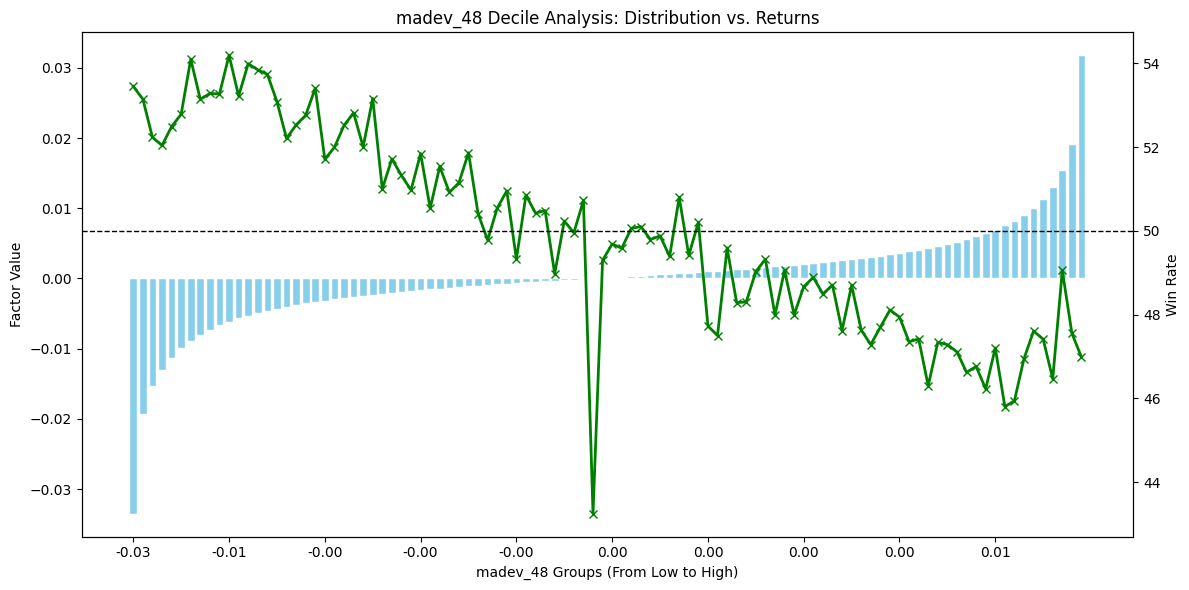

madev_48 Spearman Rank IC: -0.0403 (Filtered) / -0.0403 (Unfiltered)


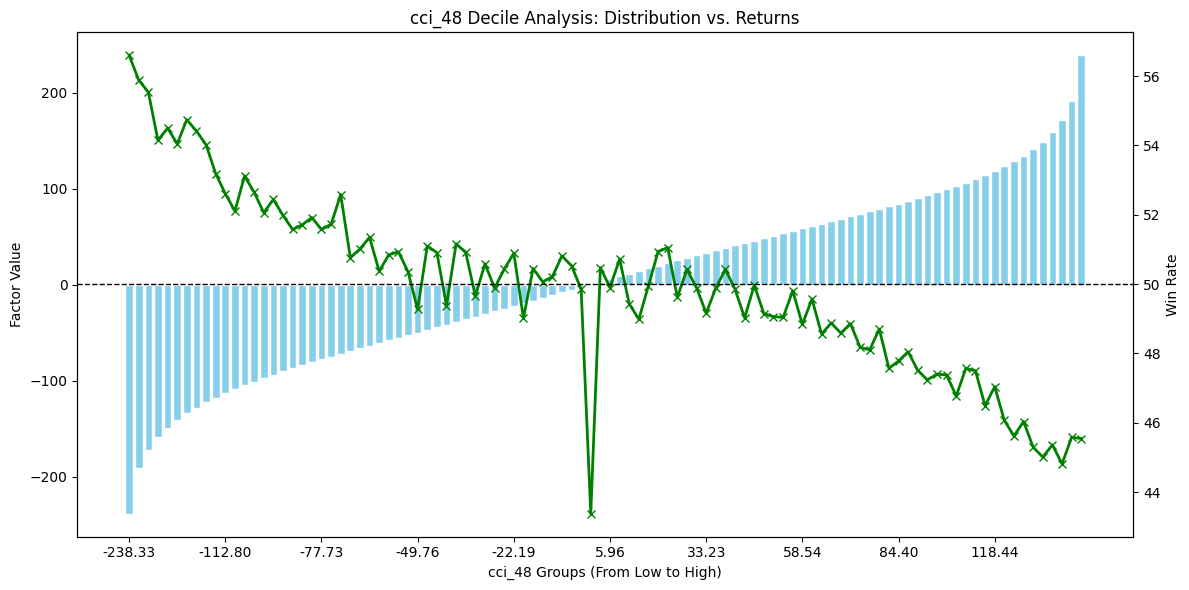

cci_48 Spearman Rank IC: -0.0403 (Filtered) / -0.0403 (Unfiltered)


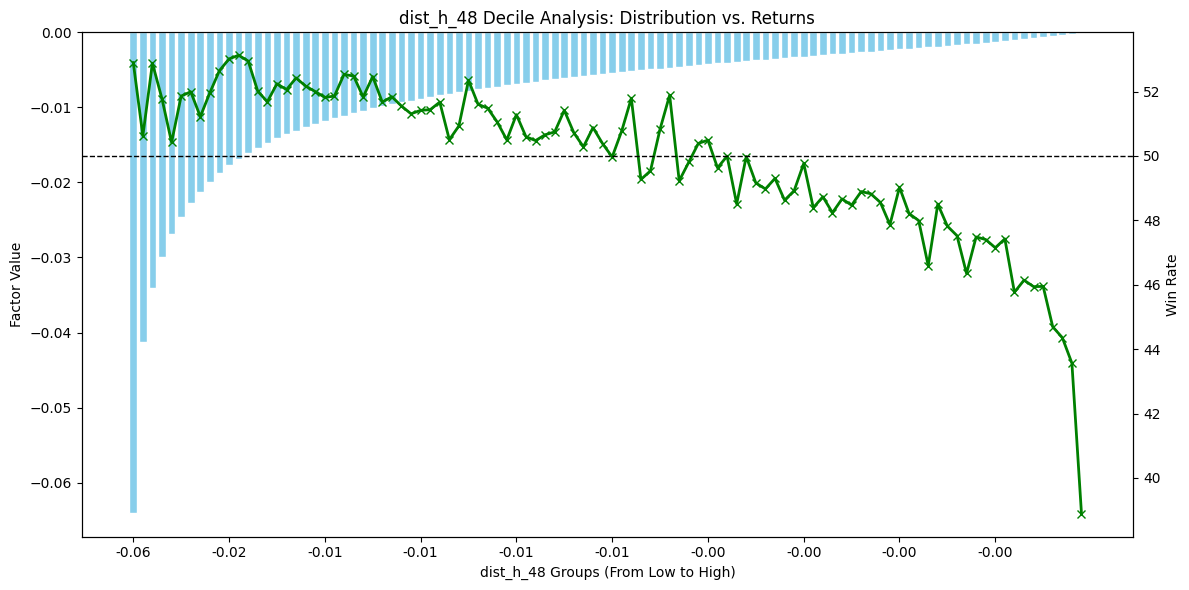

dist_h_48 Spearman Rank IC: -0.0358 (Filtered) / -0.0357 (Unfiltered)


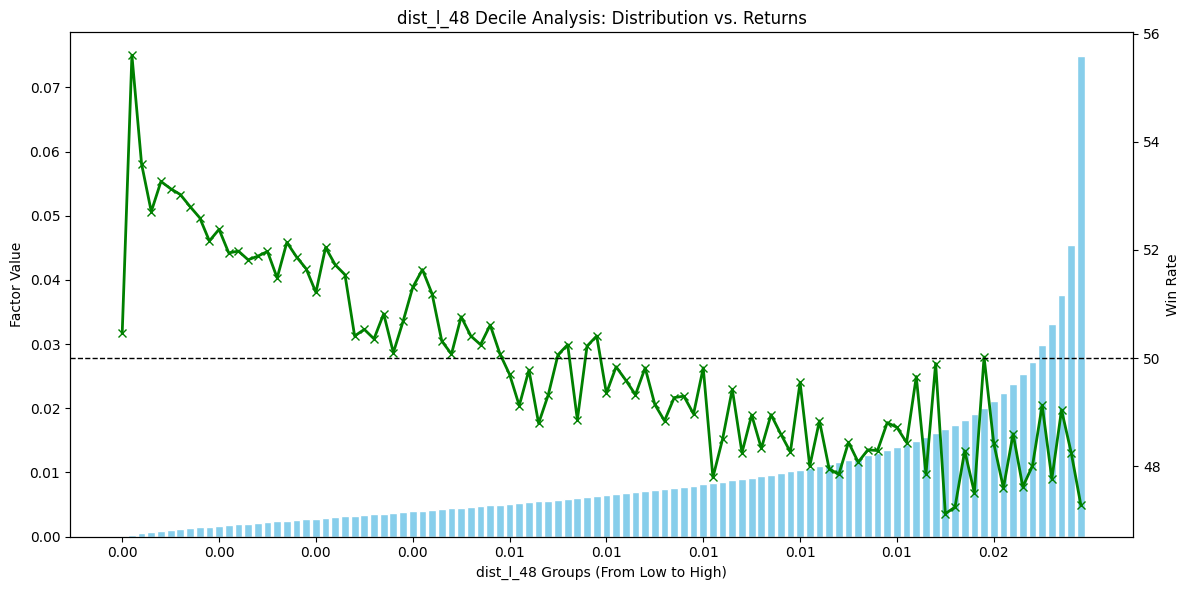

dist_l_48 Spearman Rank IC: -0.0307 (Filtered) / -0.0309 (Unfiltered)


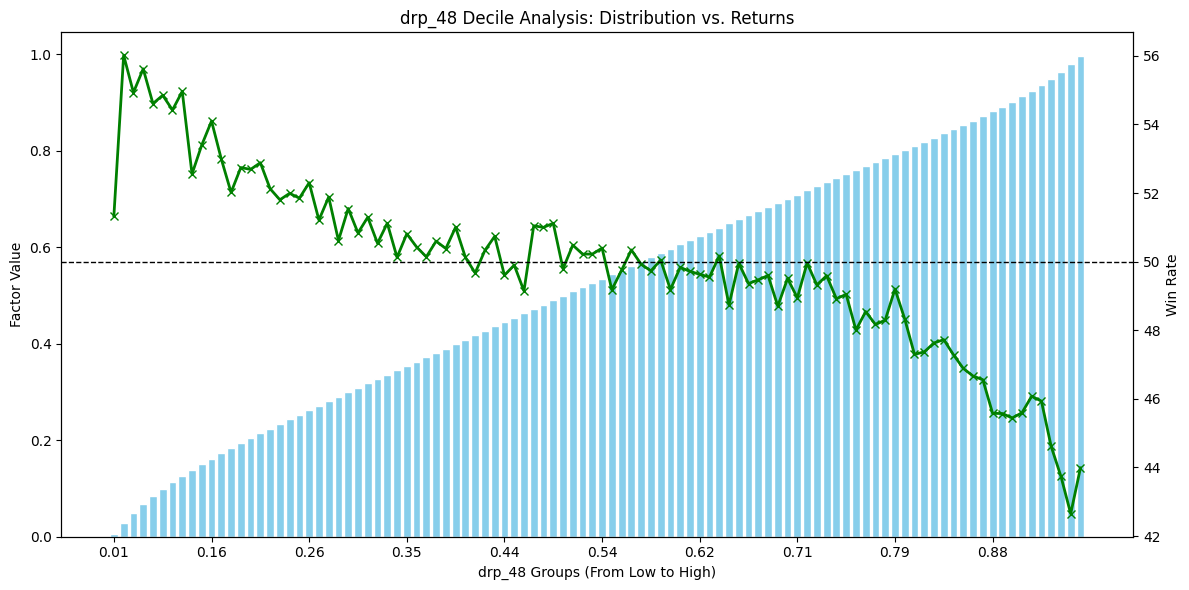

drp_48 Spearman Rank IC: -0.0437 (Filtered) / -0.0439 (Unfiltered)
Cluster 8 with factors: ['atr_48', 'gkvol_48', 'rvol_48']


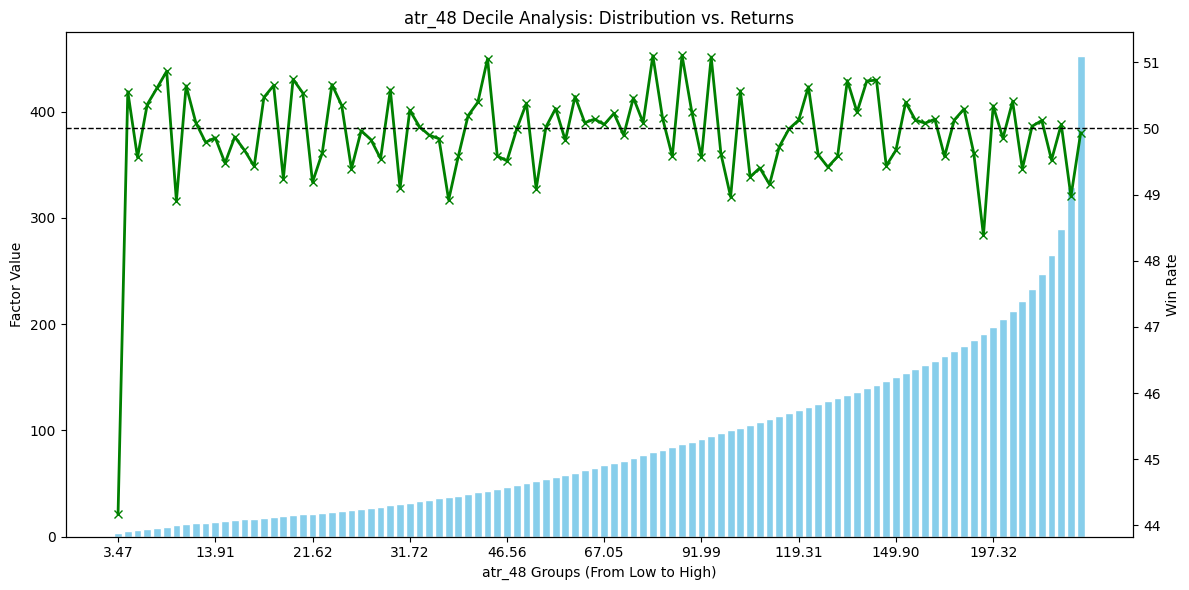

atr_48 Spearman Rank IC: -0.0033 (Filtered) / -0.0033 (Unfiltered)


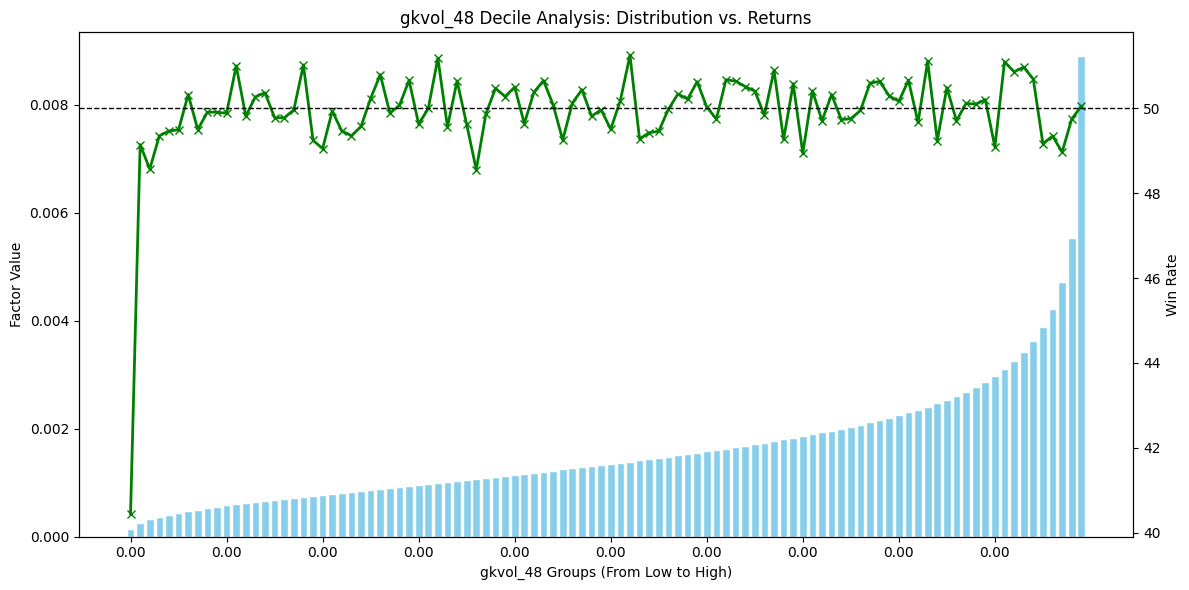

gkvol_48 Spearman Rank IC: 0.0022 (Filtered) / 0.0022 (Unfiltered)


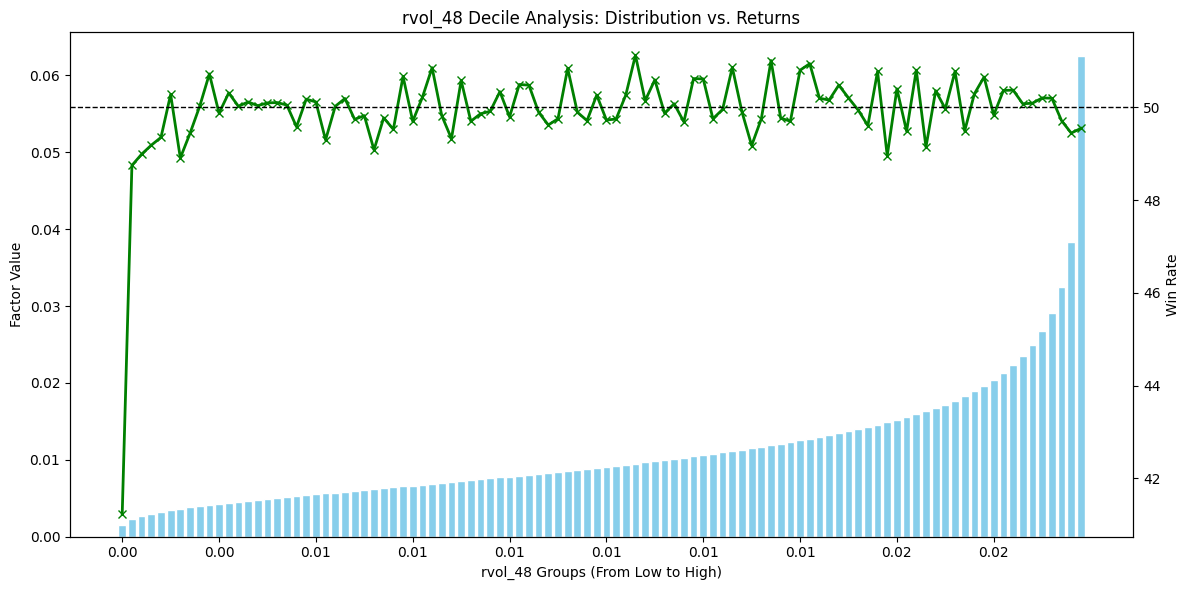

rvol_48 Spearman Rank IC: 0.0022 (Filtered) / 0.0022 (Unfiltered)
Cluster 9 with factors: ['skew_6', 'skew_12', 'skew_48', 'kurt_6', 'kurt_12', 'kurt_48']


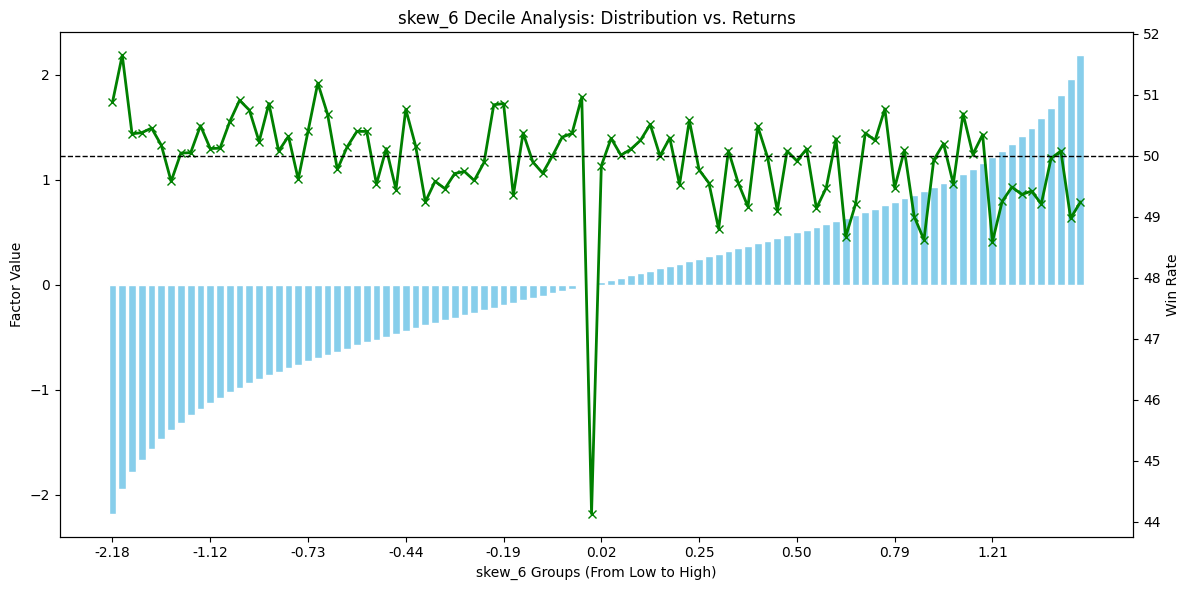

skew_6 Spearman Rank IC: -0.0034 (Filtered) / -0.0034 (Unfiltered)


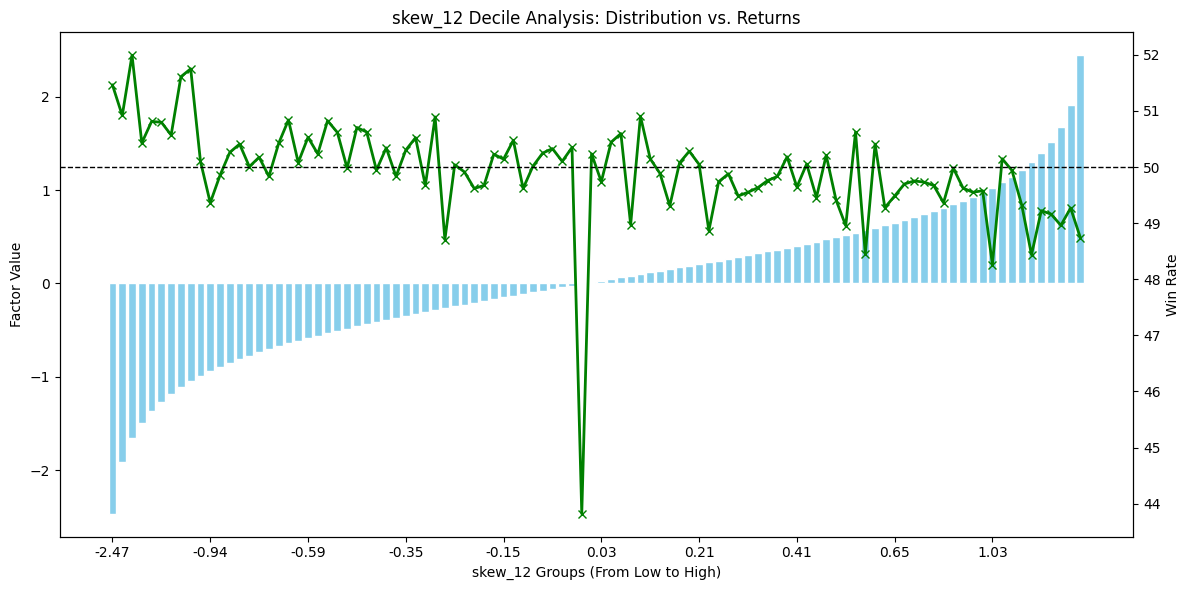

skew_12 Spearman Rank IC: -0.0064 (Filtered) / -0.0064 (Unfiltered)


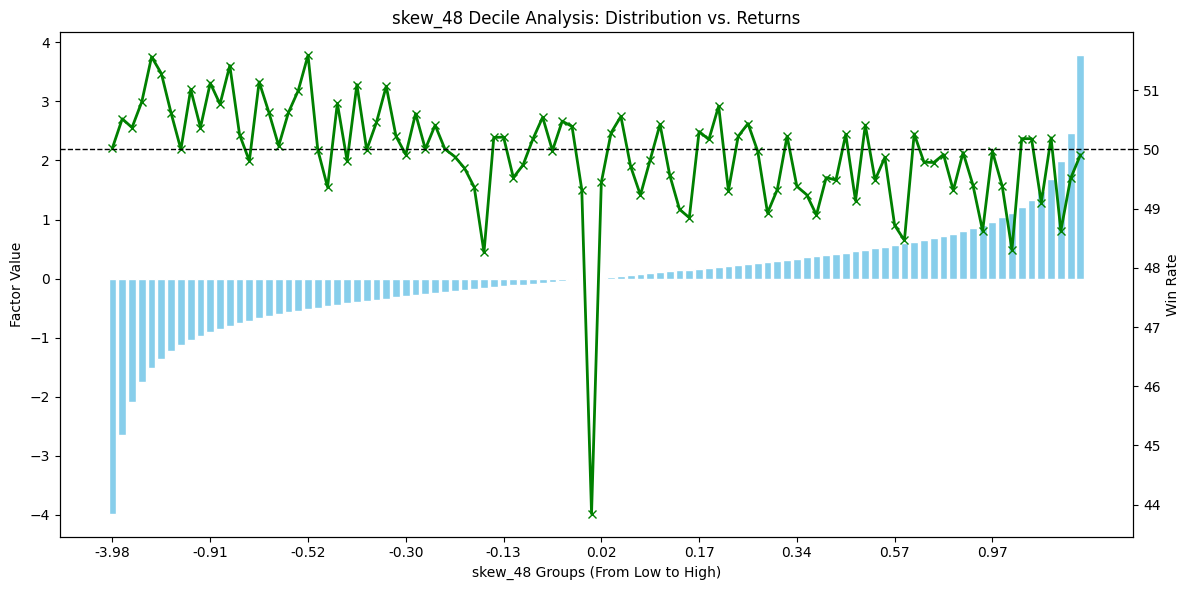

skew_48 Spearman Rank IC: -0.0080 (Filtered) / -0.0080 (Unfiltered)


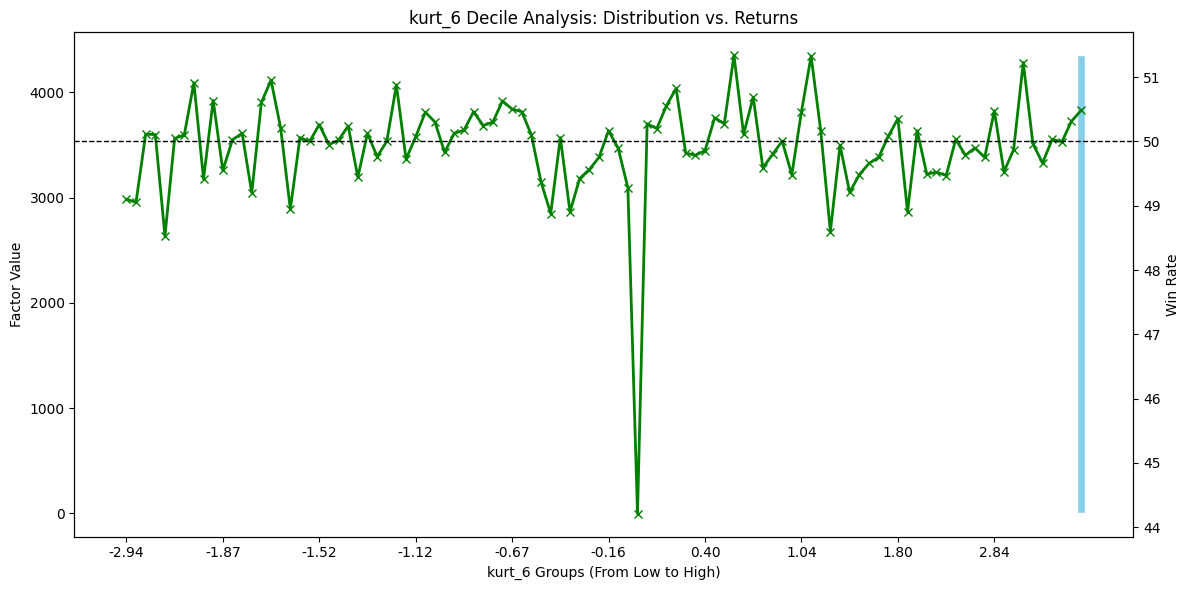

kurt_6 Spearman Rank IC: 0.0005 (Filtered) / 0.0005 (Unfiltered)


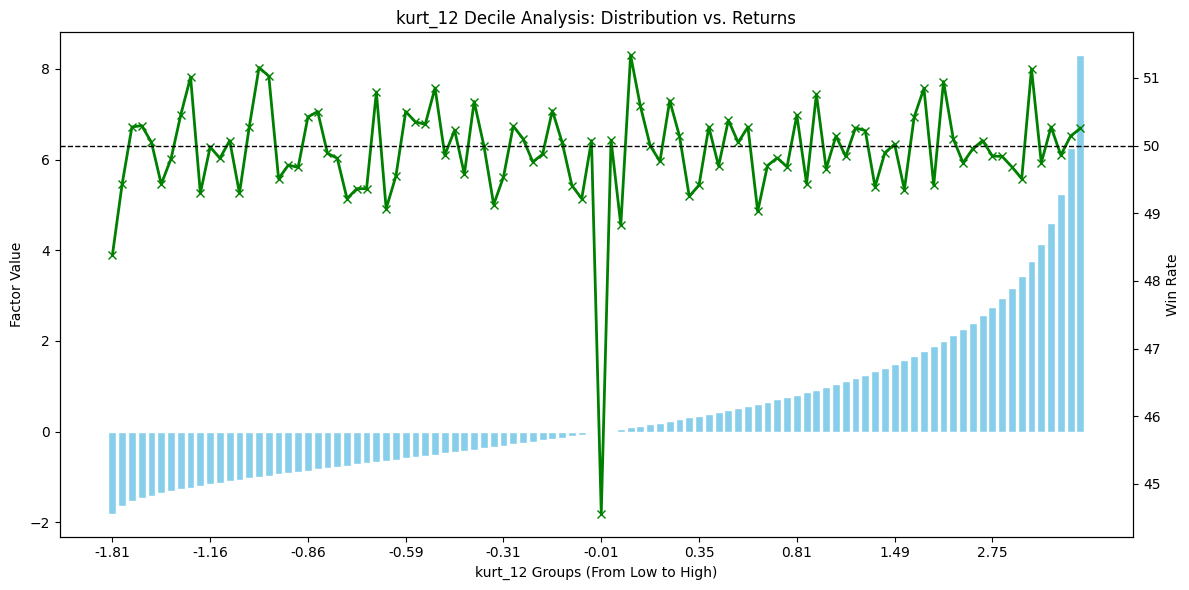

kurt_12 Spearman Rank IC: 0.0018 (Filtered) / 0.0018 (Unfiltered)


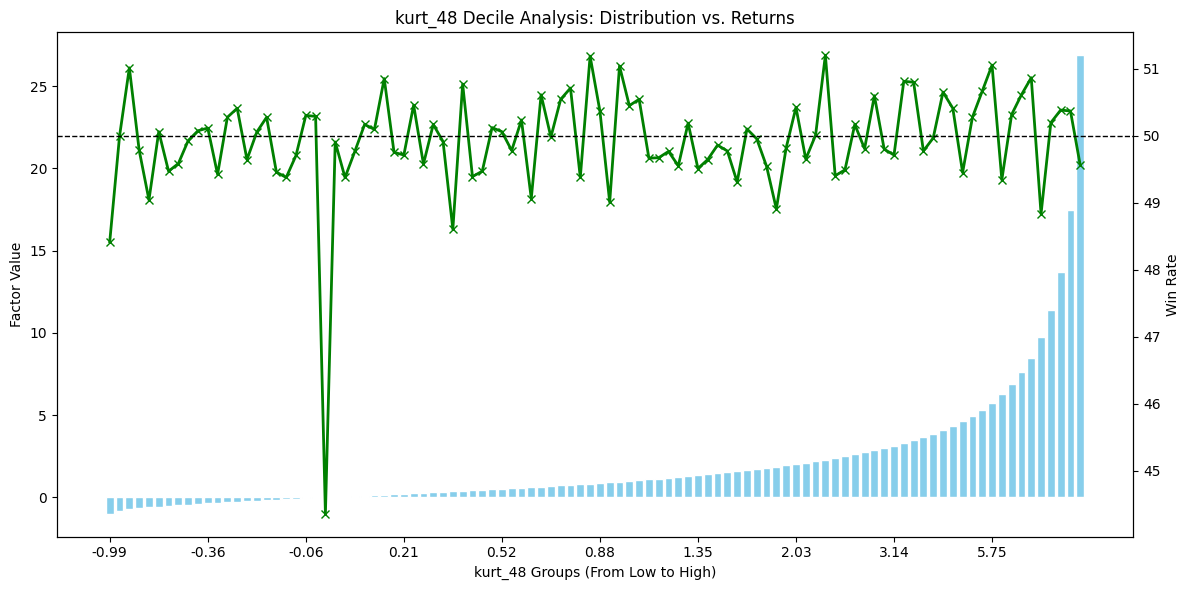

kurt_48 Spearman Rank IC: 0.0021 (Filtered) / 0.0021 (Unfiltered)
Cluster 10 with factors: ['roc_6', 'madev_6', 'madev_12', 'cci_6', 'cci_12', 'dist_h_6', 'dist_h_12', 'mfi_6', 'drp_6', 'drp_12']


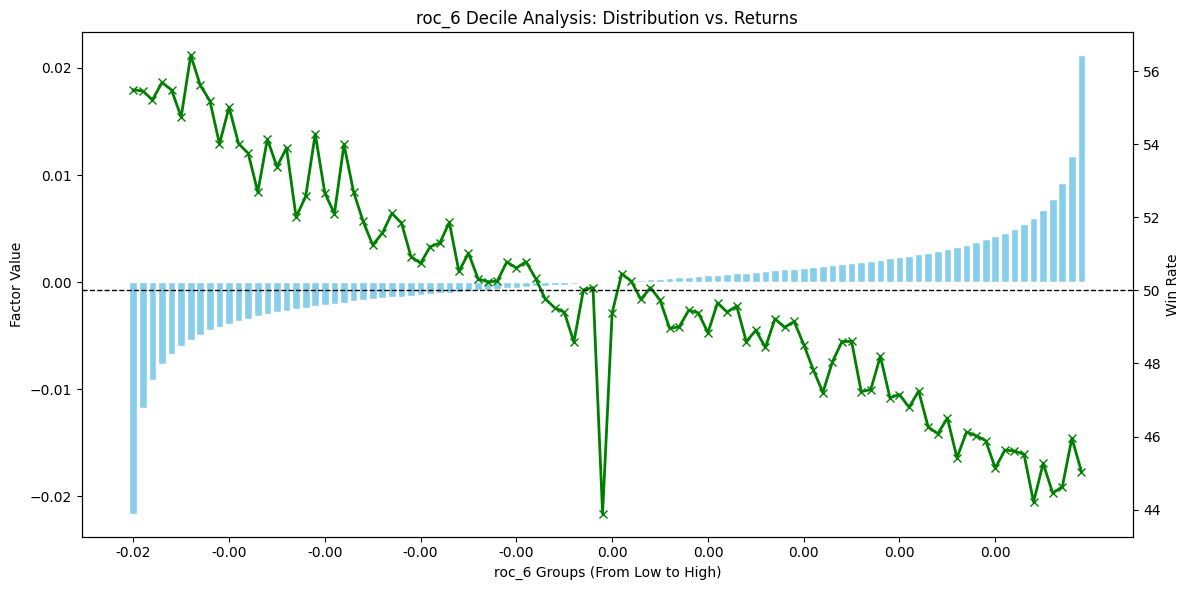

roc_6 Spearman Rank IC: -0.0586 (Filtered) / -0.0585 (Unfiltered)


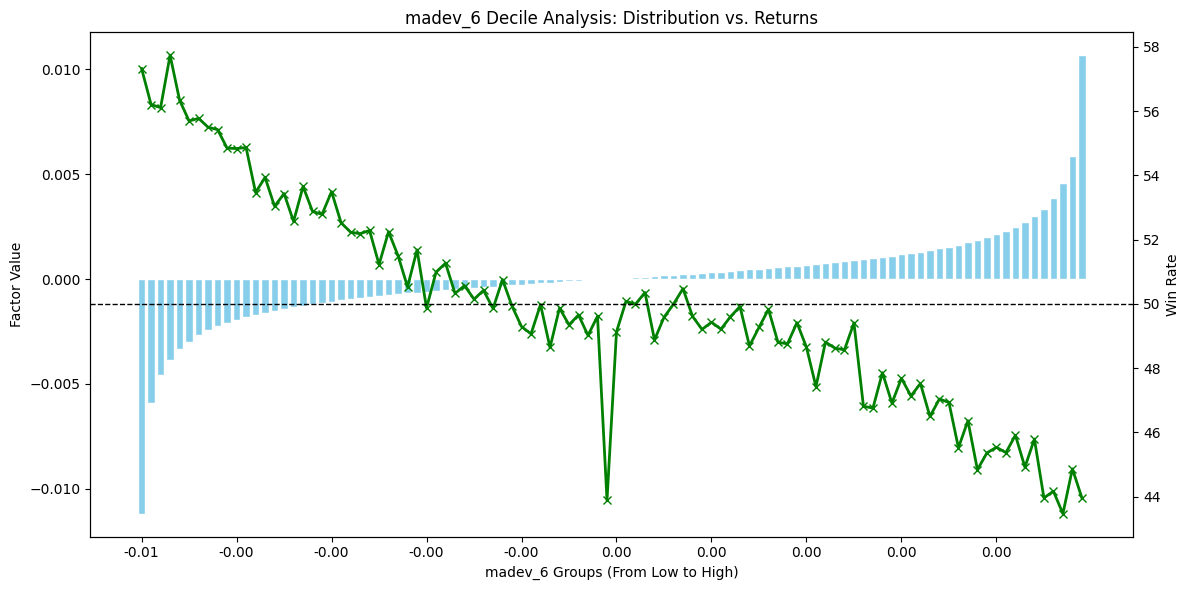

madev_6 Spearman Rank IC: -0.0611 (Filtered) / -0.0611 (Unfiltered)


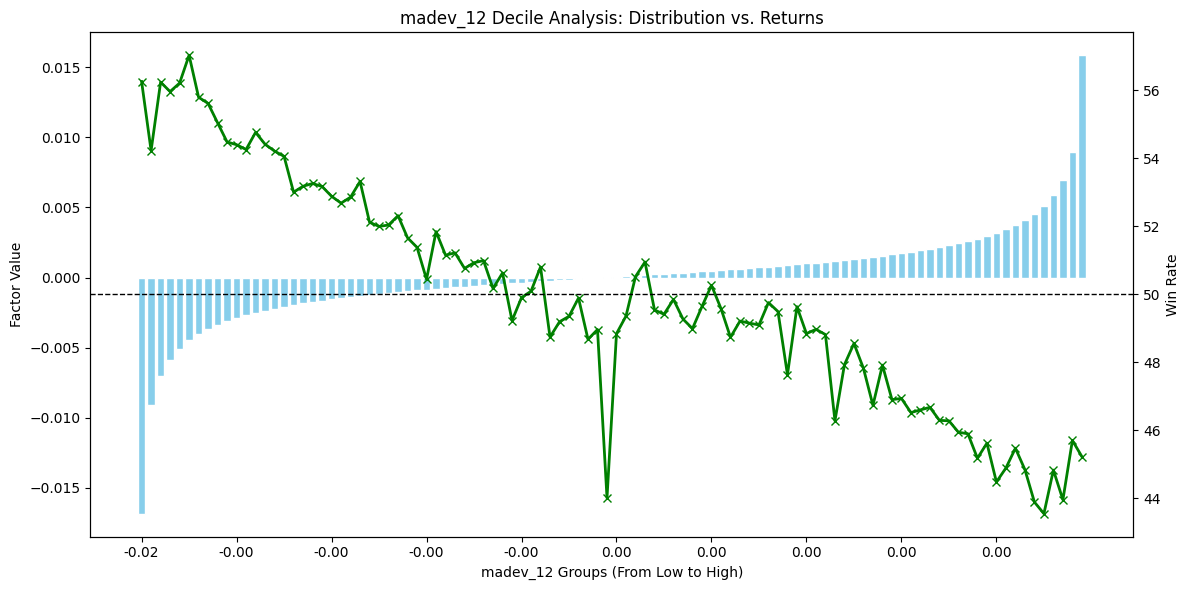

madev_12 Spearman Rank IC: -0.0605 (Filtered) / -0.0605 (Unfiltered)


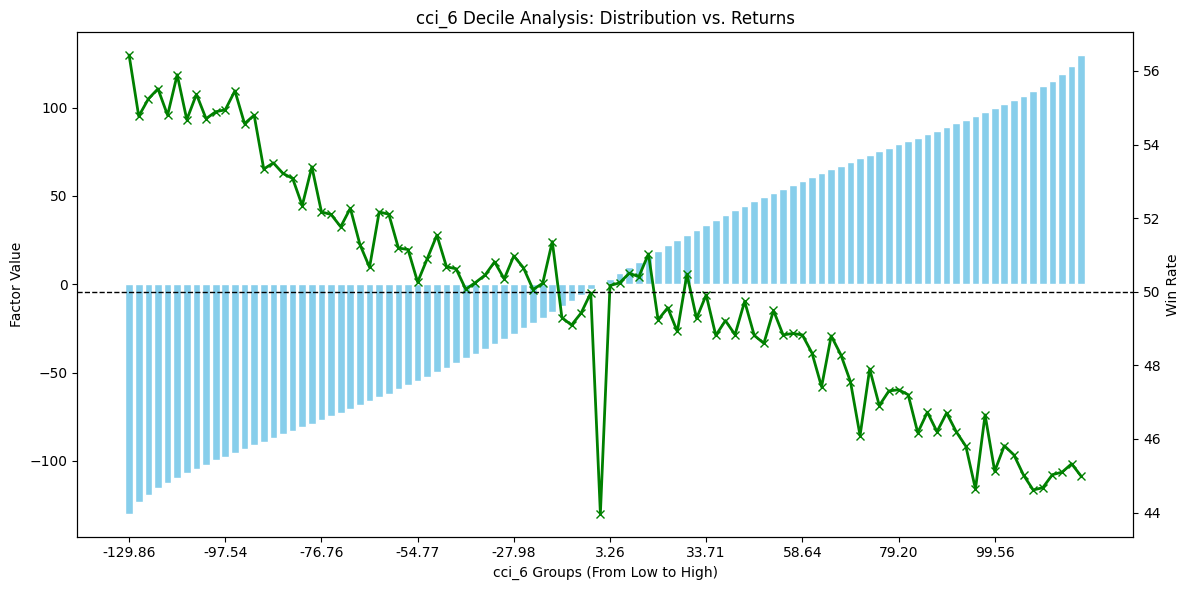

cci_6 Spearman Rank IC: -0.0564 (Filtered) / -0.0564 (Unfiltered)


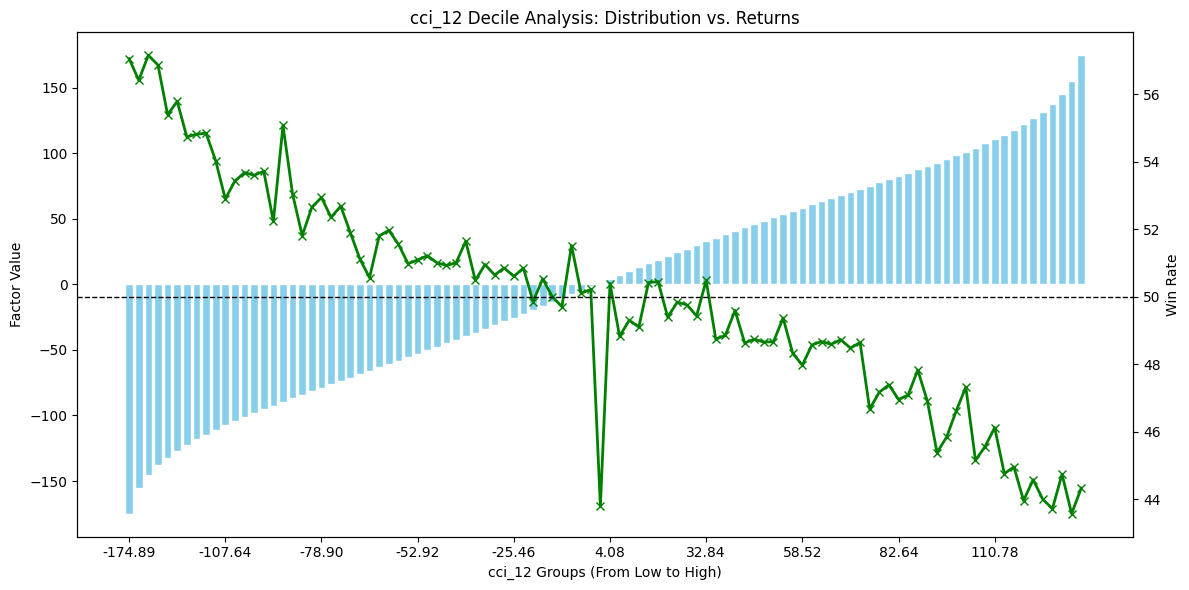

cci_12 Spearman Rank IC: -0.0553 (Filtered) / -0.0552 (Unfiltered)


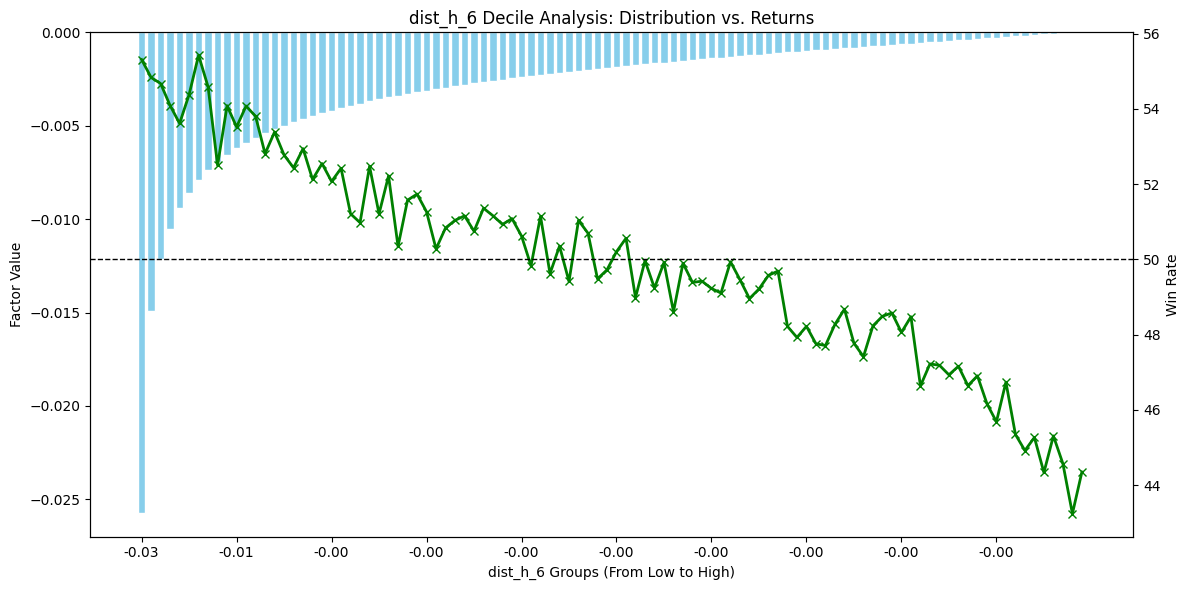

dist_h_6 Spearman Rank IC: -0.0477 (Filtered) / -0.0475 (Unfiltered)


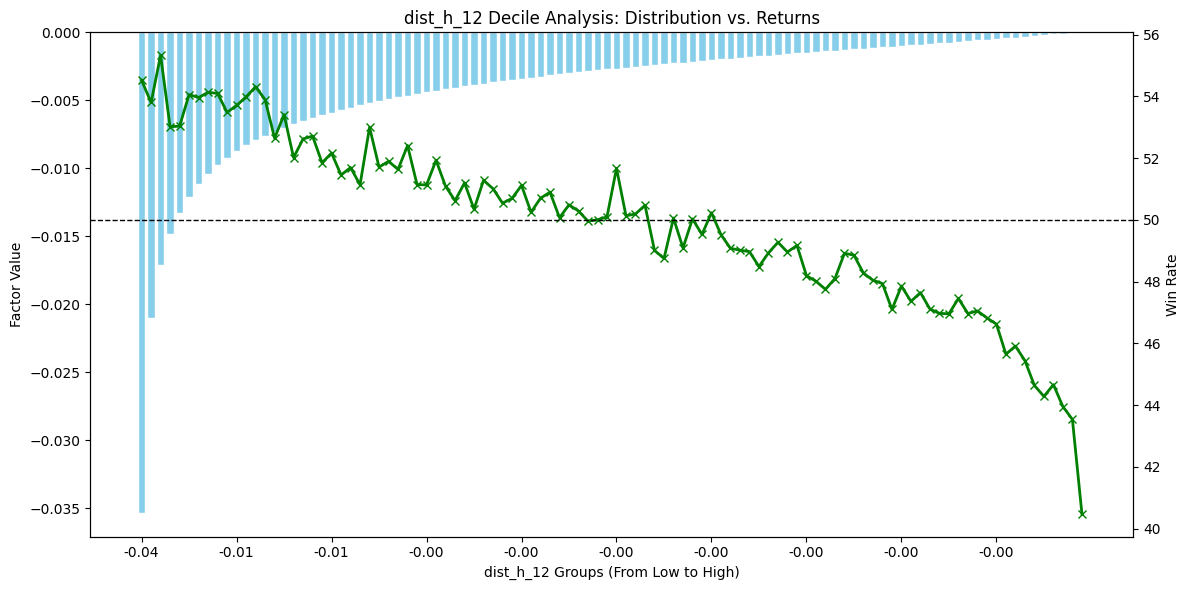

dist_h_12 Spearman Rank IC: -0.0468 (Filtered) / -0.0468 (Unfiltered)


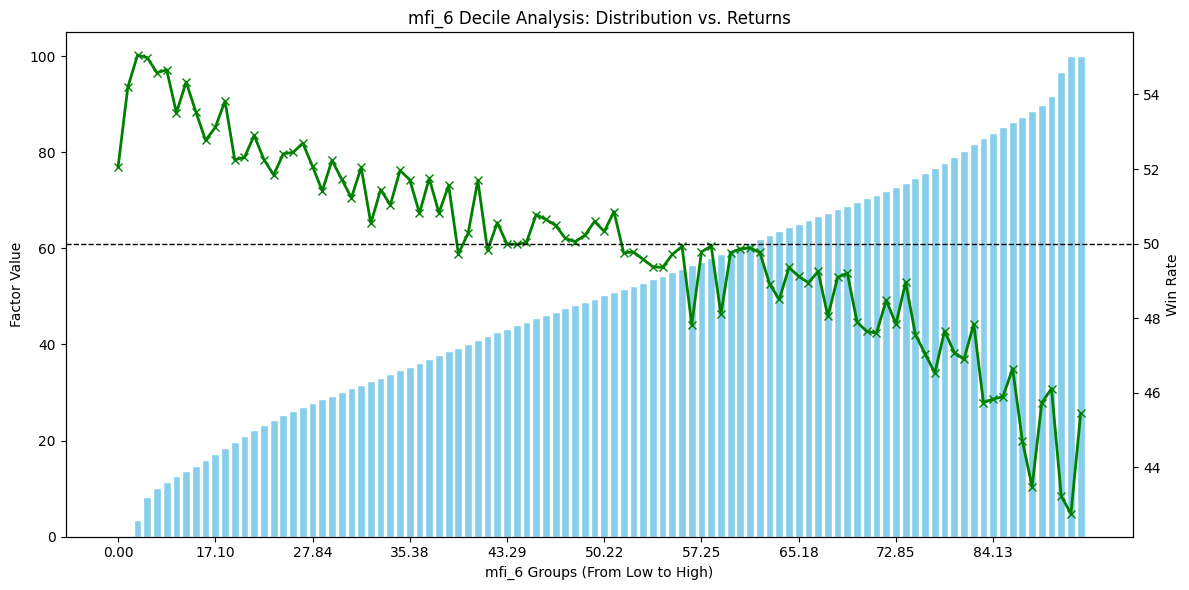

mfi_6 Spearman Rank IC: -0.0453 (Filtered) / -0.0482 (Unfiltered)


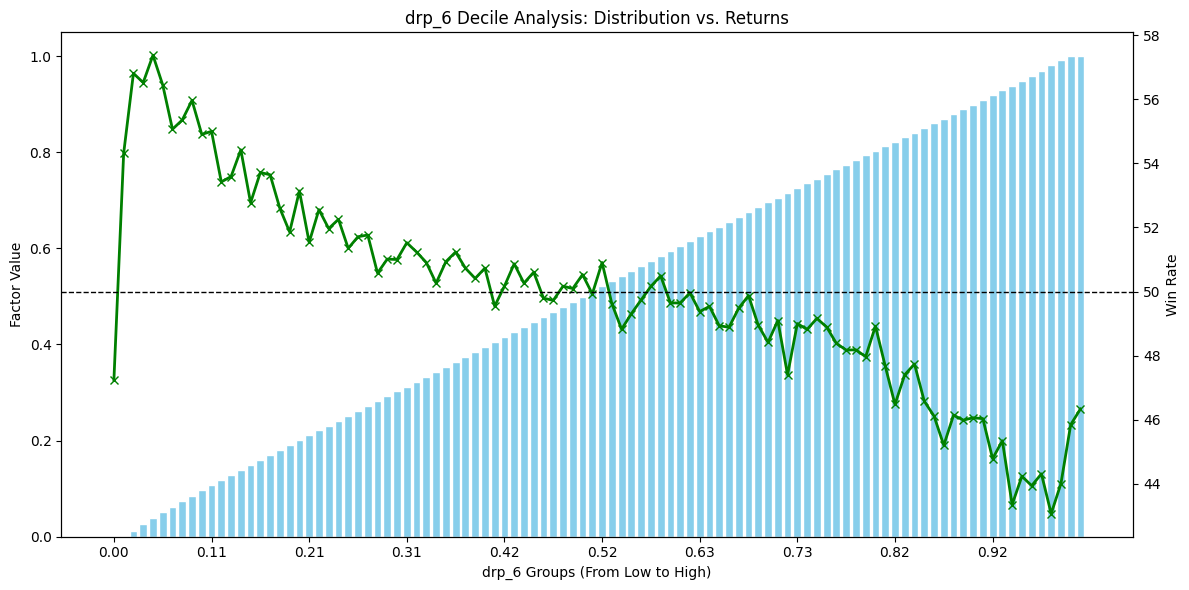

drp_6 Spearman Rank IC: -0.0569 (Filtered) / -0.0572 (Unfiltered)


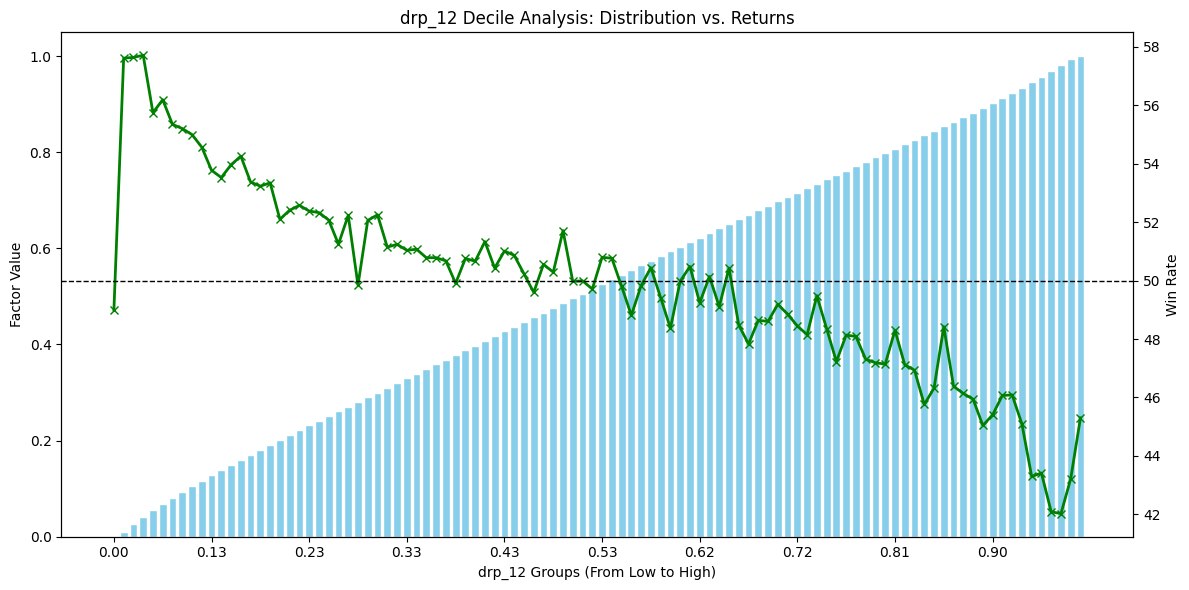

drp_12 Spearman Rank IC: -0.0567 (Filtered) / -0.0570 (Unfiltered)
Cluster 11 with factors: ['pvcorr_6', 'pvcorr_12', 'corr_6', 'corr_12']


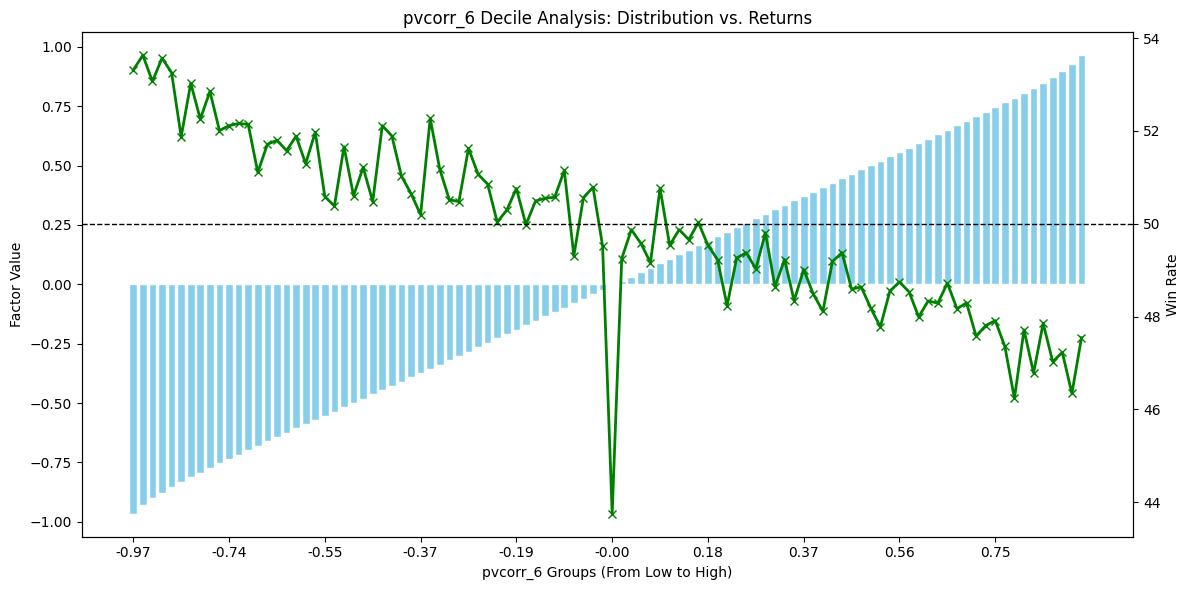

pvcorr_6 Spearman Rank IC: -0.0306 (Filtered) / -0.0306 (Unfiltered)


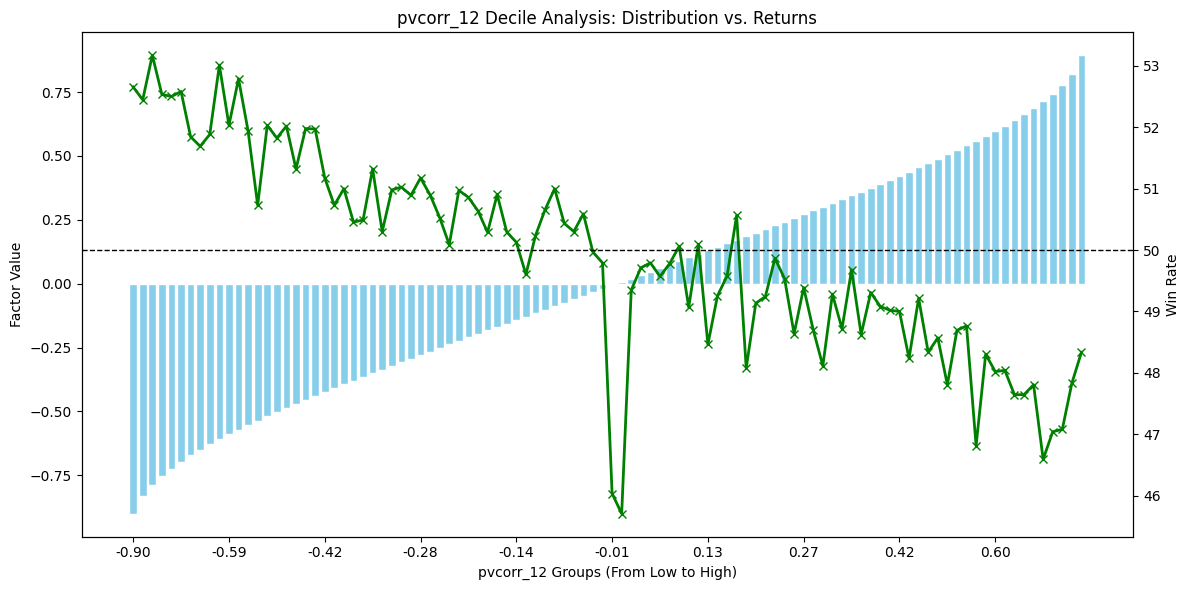

pvcorr_12 Spearman Rank IC: -0.0260 (Filtered) / -0.0260 (Unfiltered)


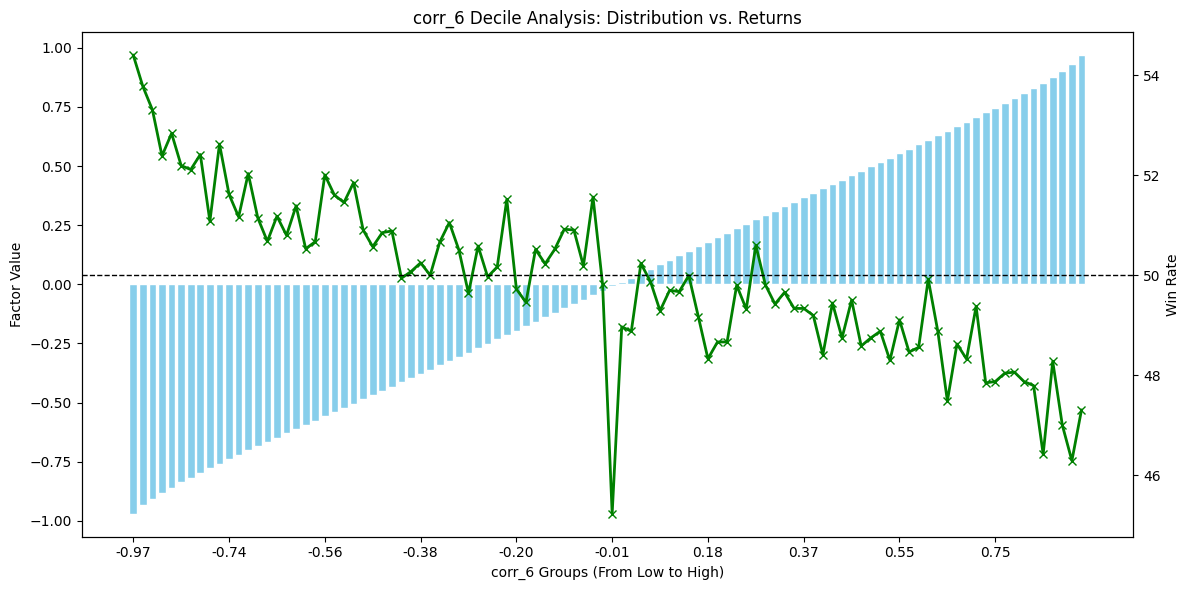

corr_6 Spearman Rank IC: -0.0242 (Filtered) / -0.0242 (Unfiltered)


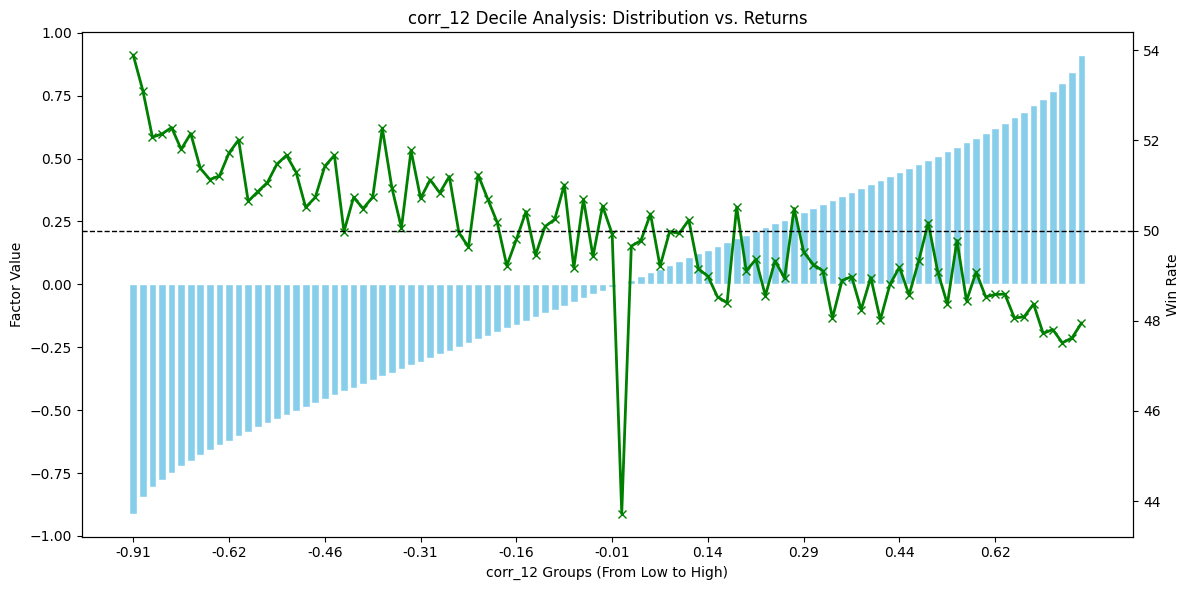

corr_12 Spearman Rank IC: -0.0208 (Filtered) / -0.0208 (Unfiltered)
Cluster 12 with factors: ['f_sandwich_intensity_z']


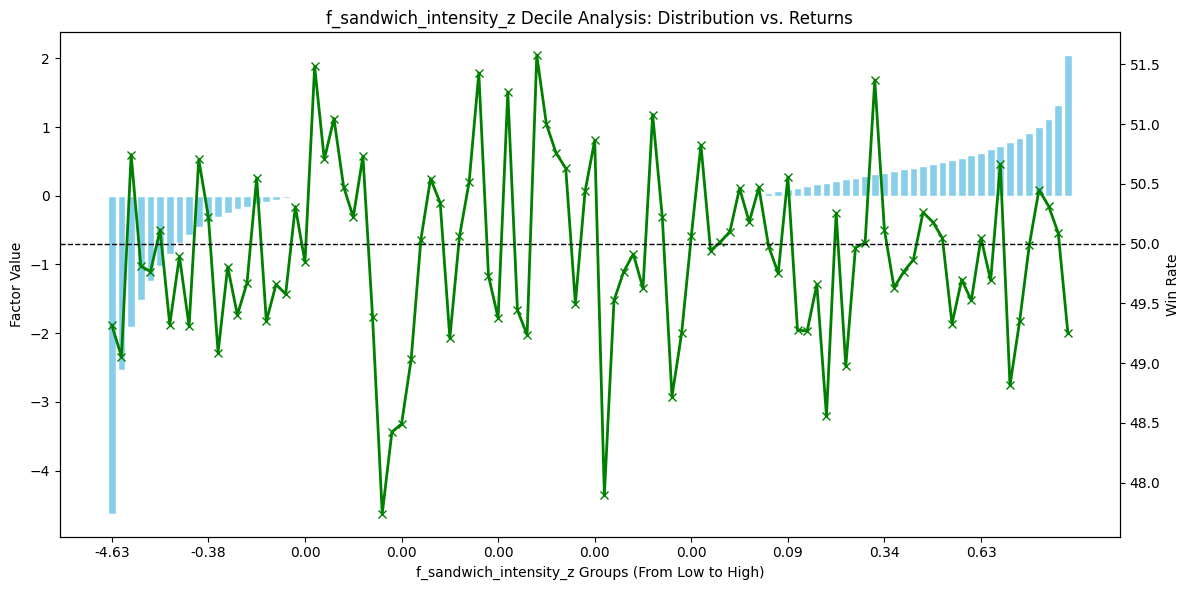

f_sandwich_intensity_z Spearman Rank IC: 0.0023 (Filtered) / 0.0008 (Unfiltered)
Cluster 13 with factors: ['f_mev_vol_share_z']


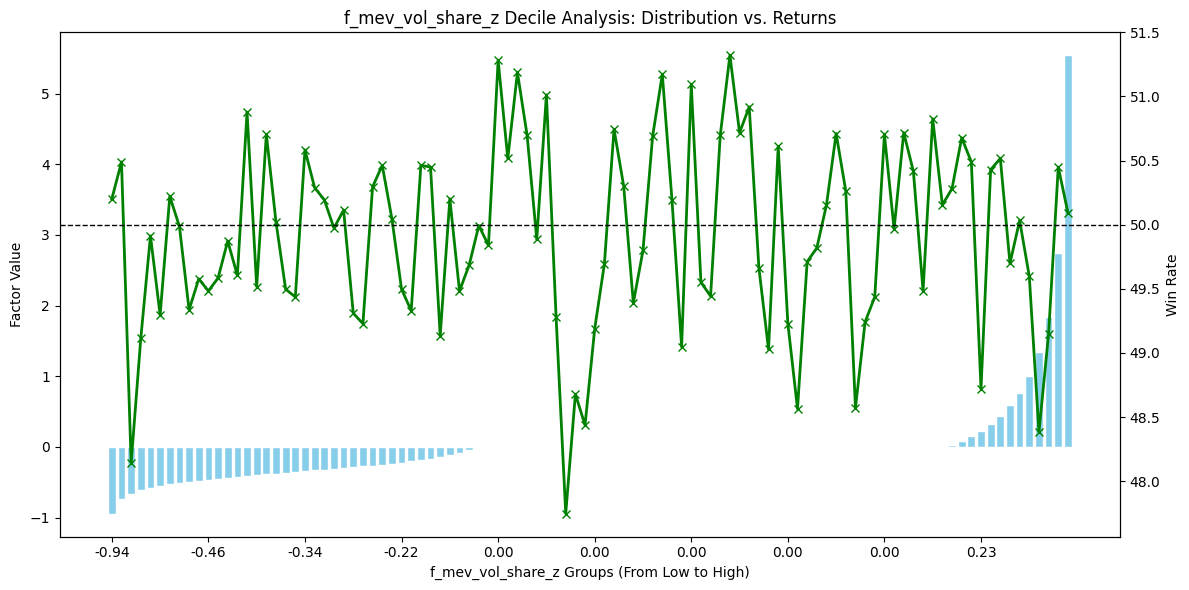

f_mev_vol_share_z Spearman Rank IC: 0.0005 (Filtered) / 0.0012 (Unfiltered)
Cluster 14 with factors: ['f_attack_eff_z']


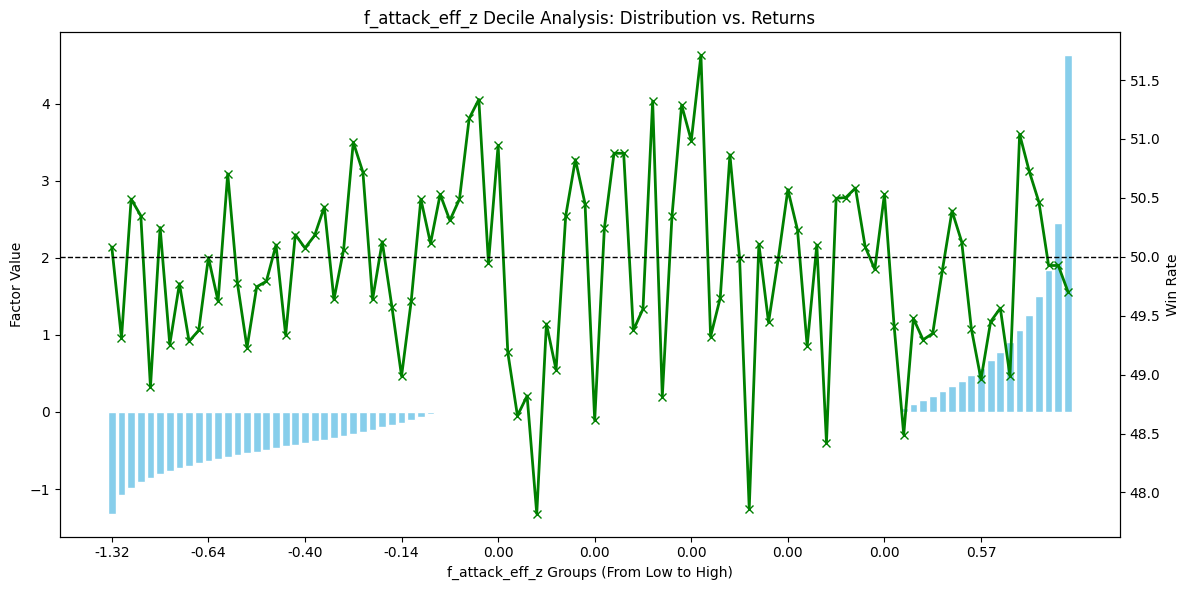

f_attack_eff_z Spearman Rank IC: 0.0005 (Filtered) / 0.0005 (Unfiltered)


In [163]:
import matplotlib.pyplot as plt
import numpy as np

target_returns = market['close'].pct_change().shift(-1)

for i in range(len(result_list)):
    print(f"Cluster {i+1} with factors: {result_list[i][1]}")
    print("==================================================")
    for j in range(len(result_list[i][1])):
        factor_name = result_list[i][1][j] 
        plot_factor_ic_bar(factors[factor_name], target_returns,bins=100,factor_name=factor_name)
        rkic_1 = factors[factor_name][factors[factor_name]!=0].corr(target_returns, method='spearman')
        rkic_0 = factors[factor_name].corr(target_returns, method='spearman')
        print(f"{factor_name} Spearman Rank IC: {rkic_1:.4f} (Filtered) / {rkic_0:.4f} (Unfiltered)")

# 5.icir

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_factor_correlation_matrix(factor_df, method='spearman', figsize=(12, 10), title="Factor Correlation Matrix"):
    """
    计算并绘制因子数据框的相关性热力图。
    
    参数:
    ----------
    factor_df : pd.DataFrame
        行是时间索引，列是因子值的 DataFrame。
    method : str, default 'spearman'
        计算相关系数的方法。
        - 'pearson': 皮尔逊相关，衡量线性相关。
        - 'spearman': 斯皮尔曼等级相关（量化常用），衡量单调关系，对异常值更鲁棒。
    figsize : tuple, default (12, 10)
        画布大小。
    title : str
        图像标题。
    """
    # 1. 计算相关系数矩阵
    # 我们通常需要处理缺失值，'pairwise' 确保使用有交集的数据计算
    corr_matrix = factor_df.corr(method=method, min_periods=10).dropna(how='all', axis=1).dropna(how='all', axis=0)

    # 2. 设置画布
    fig, ax = plt.subplots(figsize=figsize)
    
    # 3. 生成掩码（Mask）以隐藏上半部分（可选，避免重复显示）
    # 在量化中通常不需要全部显示，对角线两侧是对称的
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    # 4. 生成自定义离散配色方案（推荐使用 coolwarm 区分正负）
    cmap = sns.diverging_palette(230, 20, as_cmap=True)

    # 5. 绘制热力图
    sns.heatmap(
        corr_matrix,          # 相关系数矩阵
        annot_kws={"size": 14}, # 设置格子里数字的大小和加粗
        mask=mask,            # 是否使用掩码（只显示下半部分）
        cmap=cmap,            # 配色方案
        vmax=1, vmin=-1, # 设置颜色轴范围在 [-1, 1]
        center=0,             # 颜色中心为 0 (白色)
        annot=False,           # **关键：** 在格子里显示相关系数值
        fmt=".2f",           # 数值保留两位小数
        square=False,          # 格子是否为正方形   
        linewidths=1,        # 格子之间的间隔线宽
        cbar_kws={"shrink": .75}, # 颜色条缩放
        ax=ax
    )
    
    # 6. 设置标题和标签
    plt.title(title, fontsize=16)
    plt.xticks(fontsize=13,rotation=45, ha='right') # 旋转 X 轴标签，避免重叠
    plt.yticks(fontsize=13,rotation=0)
    plt.tight_layout() # 自动调整布局
    
    plt.show()

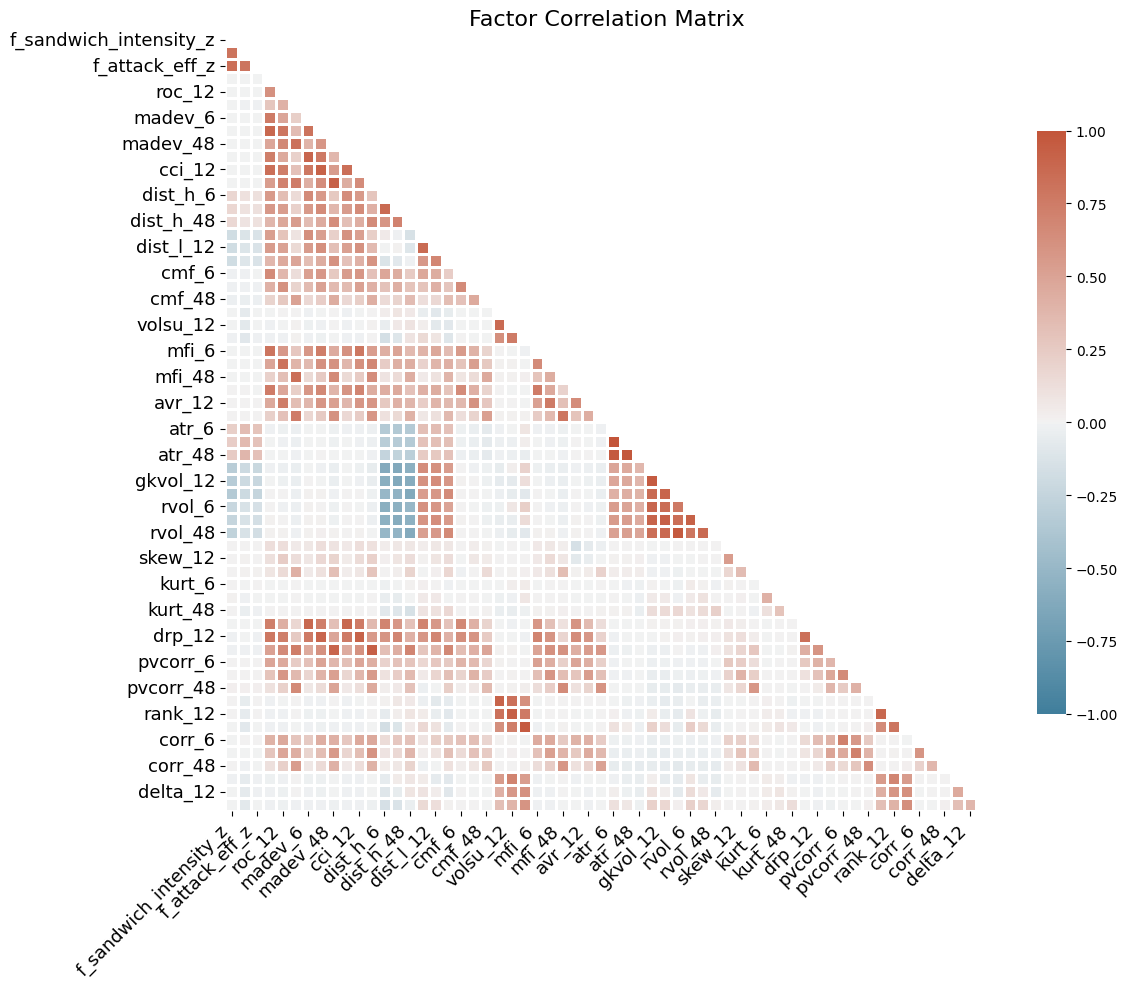

In [7]:
plot_factor_correlation_matrix(factors)

In [ ]:
# 获取描述性统计
